In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('tournament_results.csv')

## Single players

### Fix of non-monotonousness score
10 sims, 5 players, 200 conv length, 5 subjects
- B not_enough 20
- B just_enough, 40
- B more_than_enough 60

In [24]:
df_sub = df[(df.player_name == 'Player2') & (df.player_selection_type == 'single_p2') & (df.num_players == 5) & (df.conversation_length == 200)]
df_sub[df_sub['shared_score_nonmonotonousness'] < 0].groupby(['memory_size_key','memory_size', 'num_subjects'])[['shared_score_nonmonotonousness']].describe()

shared_score_nonmonotonousness  \
                                                                   count   
memory_size_key  memory_size num_subjects                                  
just_enough      40          5                                      50.0   
                             10                                     35.0   
                             20                                     30.0   
                             50                                      5.0   
more_than_enough 60          5                                      50.0   
                             10                                     45.0   
                             20                                     35.0   
                             50                                     15.0   
not_enough       20          5                                      50.0   
                             10                                     20.0   
                             20                                     25.0   

                                                                            \
                                               mean       std   min    25%   
memory_size_key  memory_size num_subjects                                    
just_enough      40          5            -7.600000  2.641892 -12.0  -9.00   
                             10           -3.000000  1.714986  -6.0  -5.00   
                             20           -1.333333  0.758098  -3.0  -1.00   
                             50           -1.000000  0.000000  -1.0  -1.00   
more_than_enough 60          5            -8.400000  3.757985 -16.0 -11.00   
                             10           -3.777778  2.065836  -8.0  -4.00   
                             20           -2.000000  0.939336  -4.0  -2.00   
                             50           -1.000000  0.000000  -1.0  -1.00   
not_enough       20          5            -1.700000  1.015191  -4.0  -2.00   
                             10           -2.000000  0.725476  -3.0  -2.25   
                             20           -1.200000  0.408248  -2.0  -1.00   

                                                           
                                           50%   75%  max  
memory_size_key  memory_size num_subjects                  
just_enough      40          5            -7.0 -5.00 -4.0  
                             10           -2.0 -2.00 -1.0  
                             20           -1.0 -1.00 -1.0  
                             50           -1.0 -1.00 -1.0  
more_than_enough 60          5            -7.5 -6.00 -4.0  
                             10           -4.0 -2.00 -1.0  
                             20           -2.0 -1.00 -1.0  
                             50           -1.0 -1.00 -1.0  
not_enough       20          5            -1.0 -1.00 -1.0  
                             10           -2.0 -1.75 -1.0  
                             20           -1.0 -1.00 -1.0

In [25]:
df_sub = df[(df.player_selection_type == 'single_p2') & (df.num_players == 5) & (df.conversation_length == 200) & (df.num_subjects == 5)]
df_sub_not_enough = df_sub[df_sub['memory_size_key'] == 'not_enough']
df_sub_just_enough = df_sub[df_sub['memory_size_key'] == 'just_enough']
df_sub_more_than_enough = df_sub[df_sub['memory_size_key'] == 'more_than_enough']
print(len(df_sub_not_enough), len(df_sub_just_enough), len(df_sub_more_than_enough))
df_sub_not_enough[['player_score_total']]

50 50 50


,player_score_total
131312,0.86295
131313,0.85045
131314,0.87295
131315,0.85795
131316,0.85095
179976,0.91925
179977,0.89925
179978,0.90225
179979,0.89825
179980,0.89425


In [95]:
df_new_not_enough = pd.read_csv('results_mem_not_enough.csv')
df_new_just_enough = pd.read_csv('results_mem_just_enough.csv')
df_new_more_than_enough = pd.read_csv('results_mem_more_than_enough.csv')

print(len(df_new_not_enough), len(df_new_just_enough), len(df_new_more_than_enough))

50 50 50


In [96]:
df_new_not_enough.columns

Index(['sim_num', 'player', 'player_total', 'player_individual',
       'total_shared', ' total_importance', ' total_coherence',
       ' total_freshness', ' total_nonmonotonousness'],
      dtype='object')

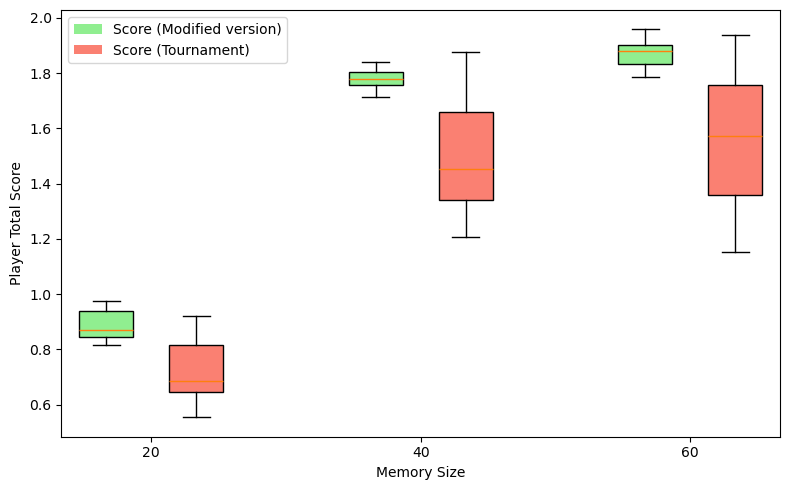

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

df_sub = df[
    (df.player_name == 'Player2') &
    (df.player_selection_type == 'single_p2') &
    (df.num_players == 5) &
    (df.conversation_length == 200)
]

# Define memory values of interest
memory_vals = [20, 40, 60]

box_data = []
positions = []

for i, mem in enumerate(memory_vals):
    # External data depending on memory size
    if mem == 20:
        vals = df_new_not_enough["player_total"].dropna().values
    elif mem == 40:
        vals = df_new_just_enough["player_total"].dropna().values
    elif mem == 60:
        vals = df_new_more_than_enough["player_total"].dropna().values
    else:
        vals = None
    
    if vals is not None and len(vals) > 0:
        box_data.append(vals.flatten())   # Player Total
        positions.append(i*3 + 1)

    # Player Score Total from subset
    vals2 = df_sub[df_sub["memory_size"] == mem]["player_score_total"].dropna().values
    if len(vals2) > 0:
        box_data.append(vals2.flatten())
        positions.append(i*3 + 2)

# Make plot
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True)

# Apply alternating colors (blue for Player Total, green for Player Score Total)
colors = ['lightgreen', 'salmon']
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % 2])

# Set x-axis ticks only for valid memory sizes
xtick_positions = []
xtick_labels = []
for i, mem in enumerate(memory_vals):
    if (i*3 + 1 in positions) or (i*3 + 2 in positions):
        xtick_positions.append(i*3 + 1.5)   # midpoint
        xtick_labels.append(mem)

ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

ax.set_xlabel("Memory Size")
ax.set_ylabel("Player Total Score")

# Add legend with matching colors
ax.legend(
    [mpatches.Patch(facecolor='lightgreen'), mpatches.Patch(facecolor='salmon')],
    ["Score (Modified version)", "Score (Tournament)"],
    loc="upper left"
)

plt.tight_layout()
plt.show()


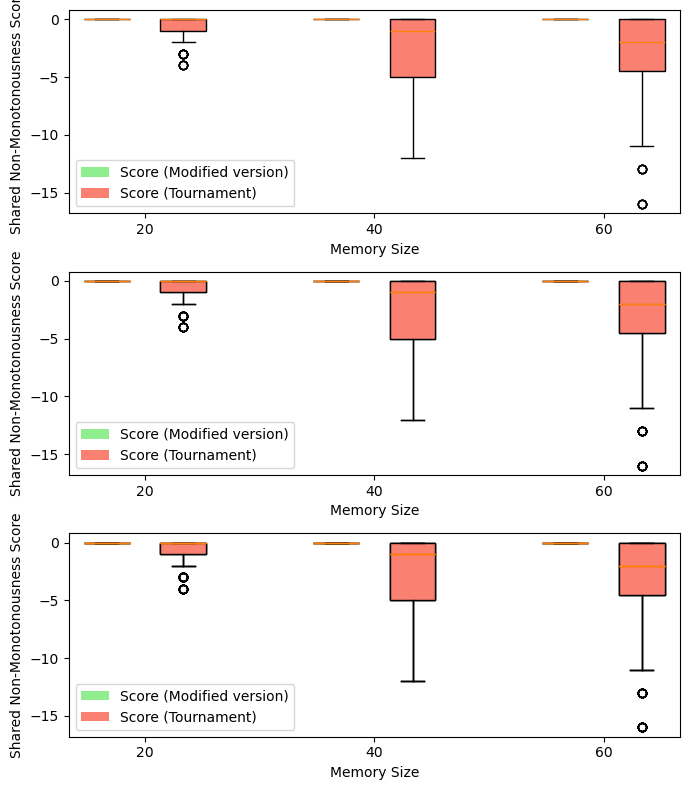

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

df_sub = df[
    (df.player_name == 'Player2') &
    (df.player_selection_type == 'single_p2') &
    (df.num_players == 5) &
    (df.conversation_length == 200)
]

fig, ax = plt.subplots(3, figsize=(7, 8))


# Define memory values of interest
memory_vals = [20, 40, 60]

box_data = []
positions = []

for ax in ax.flatten():
    for i, mem in enumerate(memory_vals):
        # External data depending on memory size
        if mem == 20:
            vals = df_new_not_enough[' total_nonmonotonousness'].dropna().values
        elif mem == 40:
            vals = df_new_just_enough[' total_nonmonotonousness'].dropna().values
        elif mem == 60:
            vals = df_new_more_than_enough[' total_nonmonotonousness'].dropna().values
        else:
            vals = None
        
        if vals is not None and len(vals) > 0:
            box_data.append(vals.flatten())   # Player Total
            positions.append(i*3 + 1)

        # Player Score Total from subset
        vals2 = df_sub[df_sub["memory_size"] == mem]["shared_score_nonmonotonousness"].dropna().values
        if len(vals2) > 0:
            box_data.append(vals2.flatten())
            positions.append(i*3 + 2)

    # Make plot

    bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True)

    # Apply alternating colors (blue for Player Total, green for Player Score Total)
    colors = ['lightgreen', 'salmon']
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % 2])

    # Set x-axis ticks only for valid memory sizes
    xtick_positions = []
    xtick_labels = []
    for i, mem in enumerate(memory_vals):
        if (i*3 + 1 in positions) or (i*3 + 2 in positions):
            xtick_positions.append(i*3 + 1.5)   # midpoint
            xtick_labels.append(mem)

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels)

    ax.set_xlabel("Memory Size")
    ax.set_ylabel("Shared Non-Monotonousness Score")

    # Add legend with matching colors
    ax.legend(
        [mpatches.Patch(facecolor='lightgreen'), mpatches.Patch(facecolor='salmon')],
        ["Score (Modified version)", "Score (Tournament)"],
        loc="lower left"
    )

plt.tight_layout()
plt.show()


player_total player_score_total
 total_coherence shared_score_coherence
 total_nonmonotonousness shared_score_nonmonotonousness


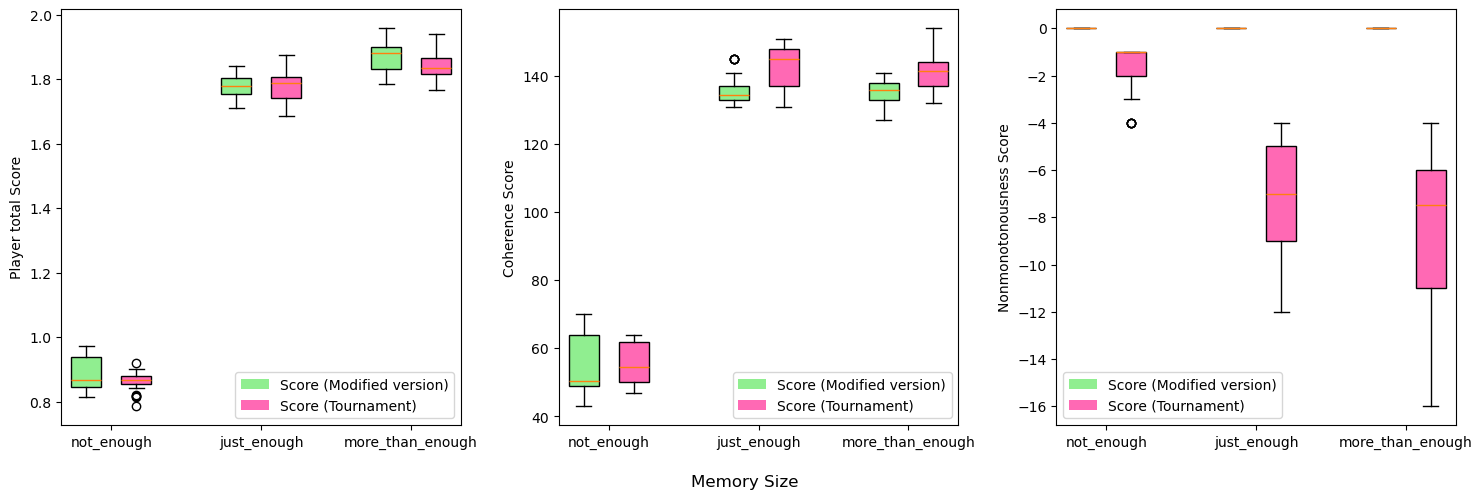

In [100]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

df_sub = df[
    (df.player_selection_type == 'single_p2') &
    (df.num_players == 5) &
    (df.conversation_length == 200) &
    (df.num_subjects == 5)
]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
scores = ['Player Total', 'coherence', 'nonmonotonousness']

# Define memory values of interest
memory_vals = {'not_enough': 20, 'just_enough': 40, 'more_than_enough': 60}


for a, ax in enumerate(ax.flatten()):
    box_data = []
    positions = []
    current_score = scores[a]
    name_modified = f" total_{current_score}" if current_score != 'Player Total' else "player_total"
    #name_modified = f" total_{current_score}" if current_score != 'Shared Total' else "total_shared"
    #name_tournament = f"shared_score_{current_score}" if current_score != 'Shared Total' else "shared_score_total"
    name_tournament = f"shared_score_{current_score}" if current_score != 'Player Total' else "player_score_total"
    print(name_modified, name_tournament)
    for i, (key, mem) in enumerate(memory_vals.items()):
        # External data depending on memory size
        if mem == 20:
            vals = df_new_not_enough[name_modified].dropna().values
        elif mem == 40:
            vals = df_new_just_enough[name_modified].dropna().values
        elif mem == 60:
            vals = df_new_more_than_enough[name_modified].dropna().values
        else:
            vals = None
        
        if vals is not None and len(vals) > 0:
            box_data.append(vals.flatten())   # Player Total
            positions.append(i*3 + 1)

        # Player Score Total from subset
        vals2 = df_sub[df_sub["memory_size"] == mem][name_tournament].dropna().values
        if len(vals2) > 0:
            box_data.append(vals2.flatten())
            positions.append(i*3 + 2)

    # Make plot

    bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True)

    # Apply alternating colors (blue for Player Total, green for Player Score Total)
    colors = ['lightgreen', 'hotpink']
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % 2])

    # Set x-axis ticks only for valid memory sizes
    xtick_positions = []
    xtick_labels = []
    for i, (key, mem) in enumerate(memory_vals.items()):
        if (i*3 + 1 in positions) or (i*3 + 2 in positions):
            xtick_positions.append(i*3 + 1.5)   # midpoint
            xtick_labels.append(key)

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels)

    
    ax.set_ylabel(f"{current_score.capitalize()} Score")

    # Add legend with matching colors
    ax.legend(
        [mpatches.Patch(facecolor='lightgreen'), mpatches.Patch(facecolor='hotpink')],
        ["Score (Modified version)", "Score (Tournament)"],
        loc="best"
    )
fig.supxlabel("Memory Size")
plt.tight_layout()
plt.savefig('fixed_results_nonmono.pdf')
plt.show()

/var/folders/jr/4zk1m8894n17tkhp3g_bjh5m0000gn/T/ipykernel_43223/1637737059.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


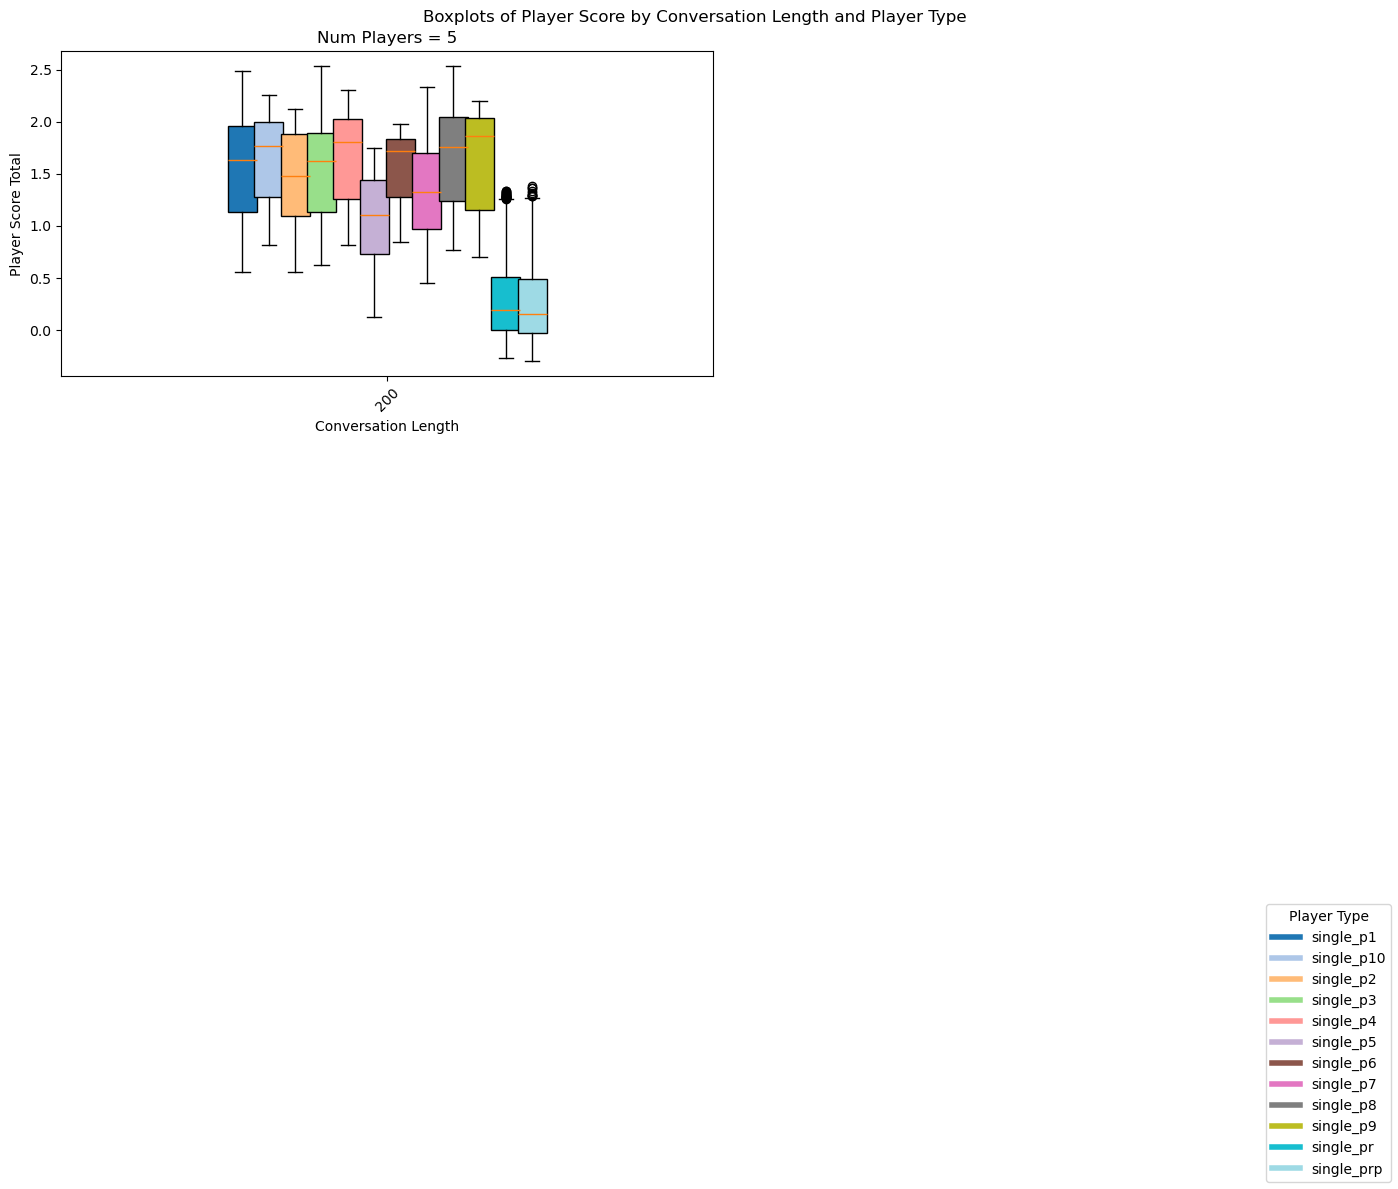

In [40]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
df_sub = df[
    (df["player_selection_type"].str.startswith("single_p")) &
    (df.num_players == 5) &
    (df.conversation_length == 200)]

num_players_vals = sorted(df_sub["num_players"].unique())
player_types = sorted(df_sub["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = df_sub[df_sub["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "player_score_total"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Player Score Total")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


### Converation Length

In [ ]:
df[df.player_selection_type == 'single_p2'].groupby(['num_players', 'conversation_length'])[['player_score_total', 'shared_score_nonmonotonousness']].describe()

player_score_total                      \
                                             count      mean       std   
num_players conversation_length                                          
2           10                               320.0  1.061600  0.447991   
            50                               320.0  1.375791  0.483177   
            100                              320.0  1.465166  0.480333   
            200                              320.0  1.514833  0.468253   
5           10                               800.0  1.024355  0.403770   
            50                               800.0  1.330667  0.446688   
            100                              800.0  1.391070  0.471093   
            200                              800.0  1.440284  0.483628   
10          10                              1600.0  1.056366  0.394347   
            50                              1600.0  1.218603  0.469401   
            100                             1600.0  1.349321  0.434368   
            200                             1600.0  1.396098  0.467014   
20          10                              3200.0  1.109262  0.369174   
            50                              3200.0  1.094437  0.433347   
            100                             3200.0  1.239558  0.468186   
            200                             3200.0  1.363202  0.438431   
34          10                              5440.0  1.139342  0.329428   
            50                              5440.0  1.130274  0.308480   
            100                             5440.0  1.067347  0.477114   
            200                             5440.0  1.232173  0.505654   

                                                                         \
                                      min       25%       50%       75%   
num_players conversation_length                                           
2           10                   0.380000  0.651500  0.936750  1.472250   
            50                   0.458200  0.940100  1.462600  1.810050   
            100                  0.585500  1.038100  1.548775  1.898375   
            200                  0.626050  1.167950  1.587362  1.934225   
5           10                   0.339000  0.706750  0.920500  1.315500   
            50                   0.509400  0.899600  1.370700  1.743150   
            100                  0.522300  0.978475  1.418225  1.819825   
            200                  0.553625  1.092913  1.482400  1.877425   
10          10                   0.294500  0.745000  0.968000  1.294500   
            50                   0.359800  0.778600  1.241700  1.626775   
            100                  0.538800  1.001025  1.373100  1.757150   
            200                  0.557325  1.054525  1.437963  1.831425   
20          10                   0.399000  0.800125  1.051000  1.377000   
            50                   0.348500  0.661900  1.113400  1.419375   
            100                  0.442400  0.896513  1.276400  1.639925   
            200                  0.583150  0.986187  1.385738  1.774313   
34          10                   0.354000  0.860500  1.139000  1.395000   
            50                   0.632600  0.895800  1.042200  1.326300   
            100                  0.319000  0.697312  1.017650  1.423600   
            200                  0.393750  0.907163  1.266425  1.679125   

                                         shared_score_nonmonotonousness  \
                                     max                          count   
num_players conversation_length                                           
2           10                   1.97200                          320.0   
            50                   2.17020                          320.0   
            100                  2.14640                          320.0   
            200                  2.16345                          320.0   
5           10                   2.34200                          800.0   
   

In [ ]:
df[df.player_selection_type == 'single_p2'].groupby(['num_players', 'conversation_length'])[['player_score_total']].describe()

player_score_total                      \
                                             count      mean       std   
num_players conversation_length                                          
2           10                               320.0  1.061600  0.447991   
            50                               320.0  1.375791  0.483177   
            100                              320.0  1.465166  0.480333   
            200                              320.0  1.514833  0.468253   
5           10                               800.0  1.024355  0.403770   
            50                               800.0  1.330667  0.446688   
            100                              800.0  1.391070  0.471093   
            200                              800.0  1.440284  0.483628   
10          10                              1600.0  1.056366  0.394347   
            50                              1600.0  1.218603  0.469401   
            100                             1600.0  1.349321  0.434368   
            200                             1600.0  1.396098  0.467014   
20          10                              3200.0  1.109262  0.369174   
            50                              3200.0  1.094437  0.433347   
            100                             3200.0  1.239558  0.468186   
            200                             3200.0  1.363202  0.438431   
34          10                              5440.0  1.139342  0.329428   
            50                              5440.0  1.130274  0.308480   
            100                             5440.0  1.067347  0.477114   
            200                             5440.0  1.232173  0.505654   

                                                                         \
                                      min       25%       50%       75%   
num_players conversation_length                                           
2           10                   0.380000  0.651500  0.936750  1.472250   
            50                   0.458200  0.940100  1.462600  1.810050   
            100                  0.585500  1.038100  1.548775  1.898375   
            200                  0.626050  1.167950  1.587362  1.934225   
5           10                   0.339000  0.706750  0.920500  1.315500   
            50                   0.509400  0.899600  1.370700  1.743150   
            100                  0.522300  0.978475  1.418225  1.819825   
            200                  0.553625  1.092913  1.482400  1.877425   
10          10                   0.294500  0.745000  0.968000  1.294500   
            50                   0.359800  0.778600  1.241700  1.626775   
            100                  0.538800  1.001025  1.373100  1.757150   
            200                  0.557325  1.054525  1.437963  1.831425   
20          10                   0.399000  0.800125  1.051000  1.377000   
            50                   0.348500  0.661900  1.113400  1.419375   
            100                  0.442400  0.896513  1.276400  1.639925   
            200                  0.583150  0.986187  1.385738  1.774313   
34          10                   0.354000  0.860500  1.139000  1.395000   
            50                   0.632600  0.895800  1.042200  1.326300   
            100                  0.319000  0.697312  1.017650  1.423600   
            200                  0.393750  0.907163  1.266425  1.679125   

                                          
                                     max  
num_players conversation_length           
2           10                   1.97200  
            50                   2.17020  
            100                  2.14640  
            200                  2.16345  
5           10                   2.34200  
            50                   2.07180  
            100                  2.13090  
            200                  2.12180  
10          10                   2.40200  
            50                   2.07520  
            100                  2.08260  
 

In [ ]:
df[df.player_selection_type == 'single_p2'].groupby(['num_players', 'conversation_length', 'memory_size_key'])[['player_score_total']].describe()

player_score_total  \
                                                                  count   
num_players conversation_length memory_size_key                           
2           10                  just_enough                        80.0   
                                more_than_enough                   80.0   
                                not_enough                         80.0   
                                way_more_than_enough               80.0   
            50                  just_enough                        80.0   
...                                                                 ...   
34          100                 way_more_than_enough             1360.0   
            200                 just_enough                      1360.0   
                                more_than_enough                 1360.0   
                                not_enough                       1360.0   
                                way_more_than_enough             1360.0   

                                                                          \
                                                          mean       std   
num_players conversation_length memory_size_key                            
2           10                  just_enough           0.984188  0.329963   
                                more_than_enough      1.124444  0.374772   
                                not_enough            0.579762  0.116924   
                                way_more_than_enough  1.558006  0.229548   
            50                  just_enough           1.389645  0.266033   
...                                                        ...       ...   
34          100                 way_more_than_enough  1.736336  0.137551   
            200                 just_enough           1.267915  0.130306   
                                more_than_enough      1.331335  0.181011   
                                not_enough            0.477851  0.042265   
                                way_more_than_enough  1.851591  0.085297   

                                                                         \
                                                          min       25%   
num_players conversation_length memory_size_key                           
2           10                  just_enough           0.49900  0.718750   
                                more_than_enough      0.60800  0.791000   
                                not_enough            0.38000  0.503875   
                                way_more_than_enough  0.82700  1.442250   
            50                  just_enough           0.93260  1.144525   
...                                                       ...       ...   
34          100                 way_more_than_enough  1.31430  1.638250   
            200                 just_enough           1.01315  1.172950   
                                more_than_enough      1.01745  1.198556   
                                not_enough            0.39375  0.444537   
                                way_more_than_enough  1.63010  1.785737   

                                                                          \
                                                           50%       75%   
num_players conversation_length memory_size_key                            
2           10                  just_enough           0.919750  1.296000   
                                more_than_enough      0.984250  1.430000   
                                not_enough            0.570500  0.620500   
                                way_more_than_enough  1.578500  1.722000   
            50                  just_enough           1.419150  1.628850   
...                                                        ...       ...   
34          100                 way_more_than_enough  1.755350  1.844350   
            200                 just_enough           1.256288  1.375988   
                                more_than_enough  

/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/2452723194.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


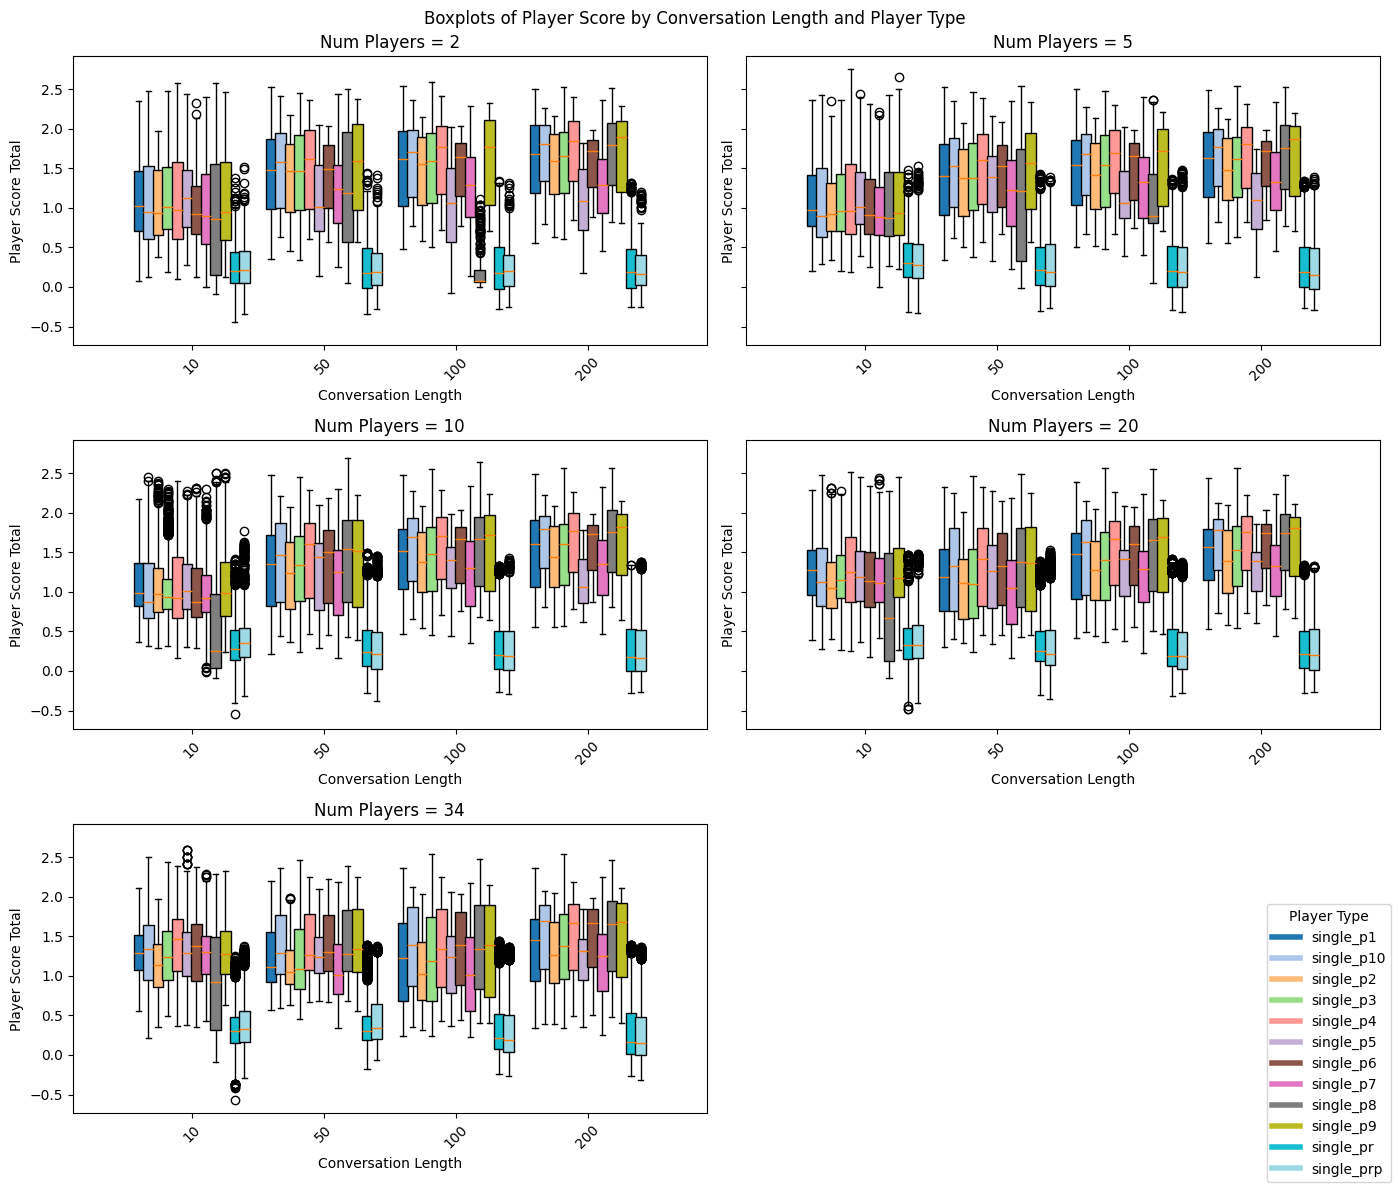

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = subset[subset["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "player_score_total"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Player Score Total")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/1824090965.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


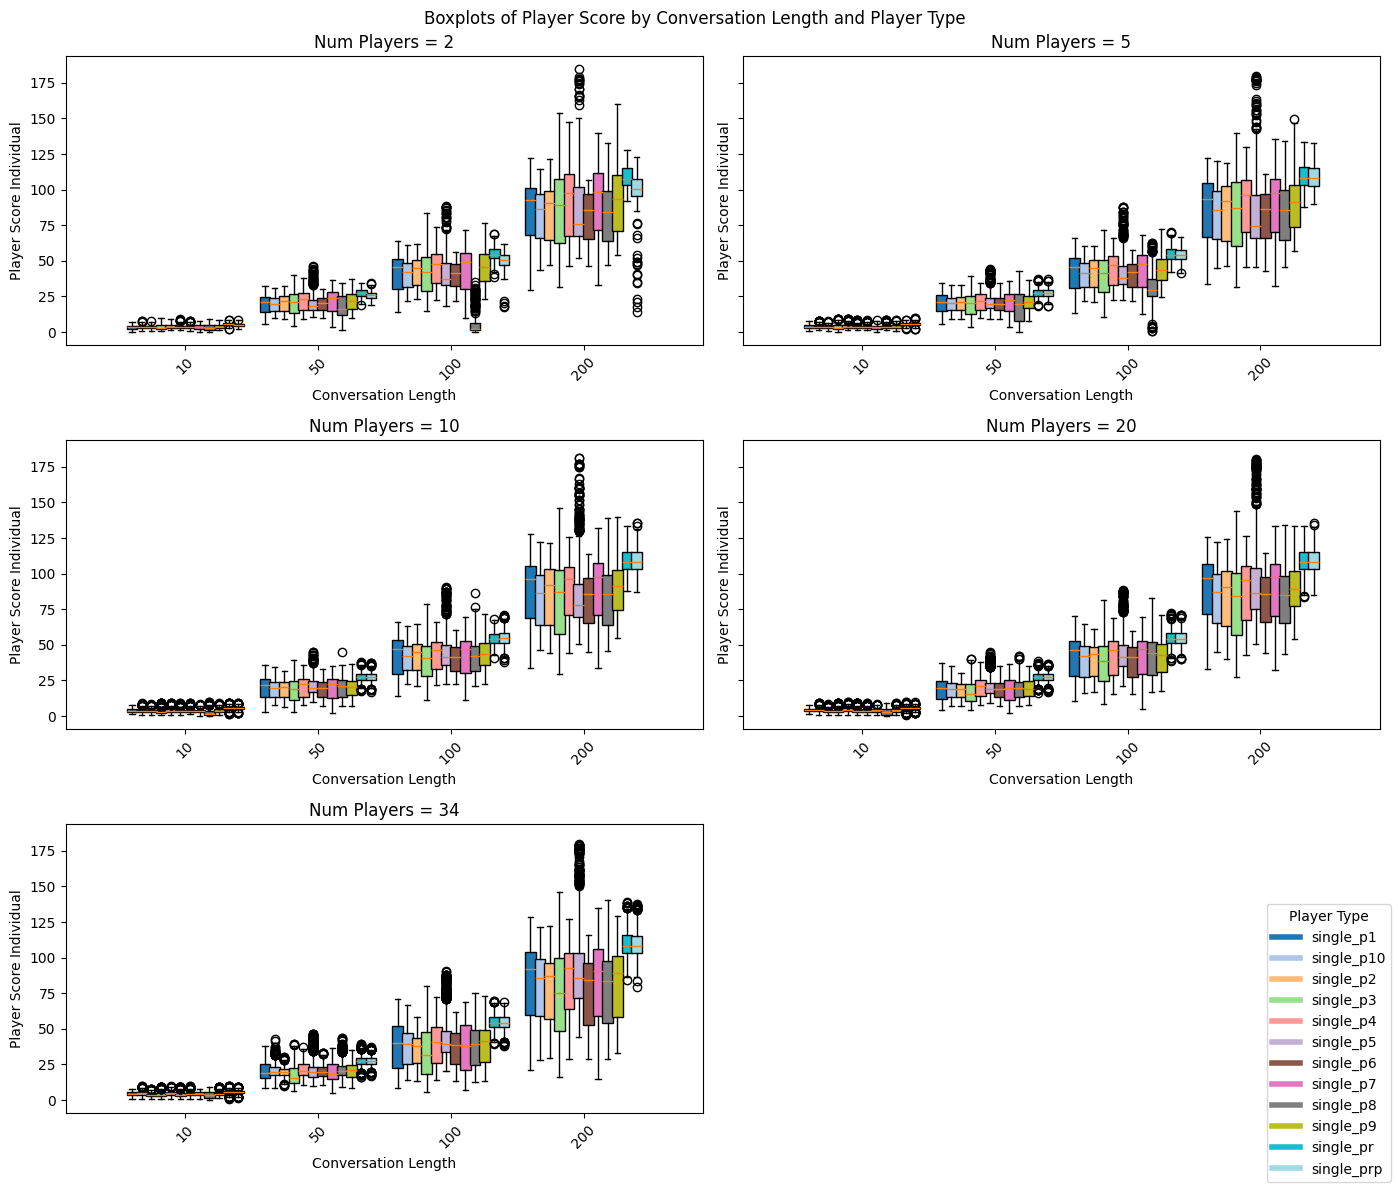

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = subset[subset["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "player_score_individual"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Player Score Individual")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/984385901.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


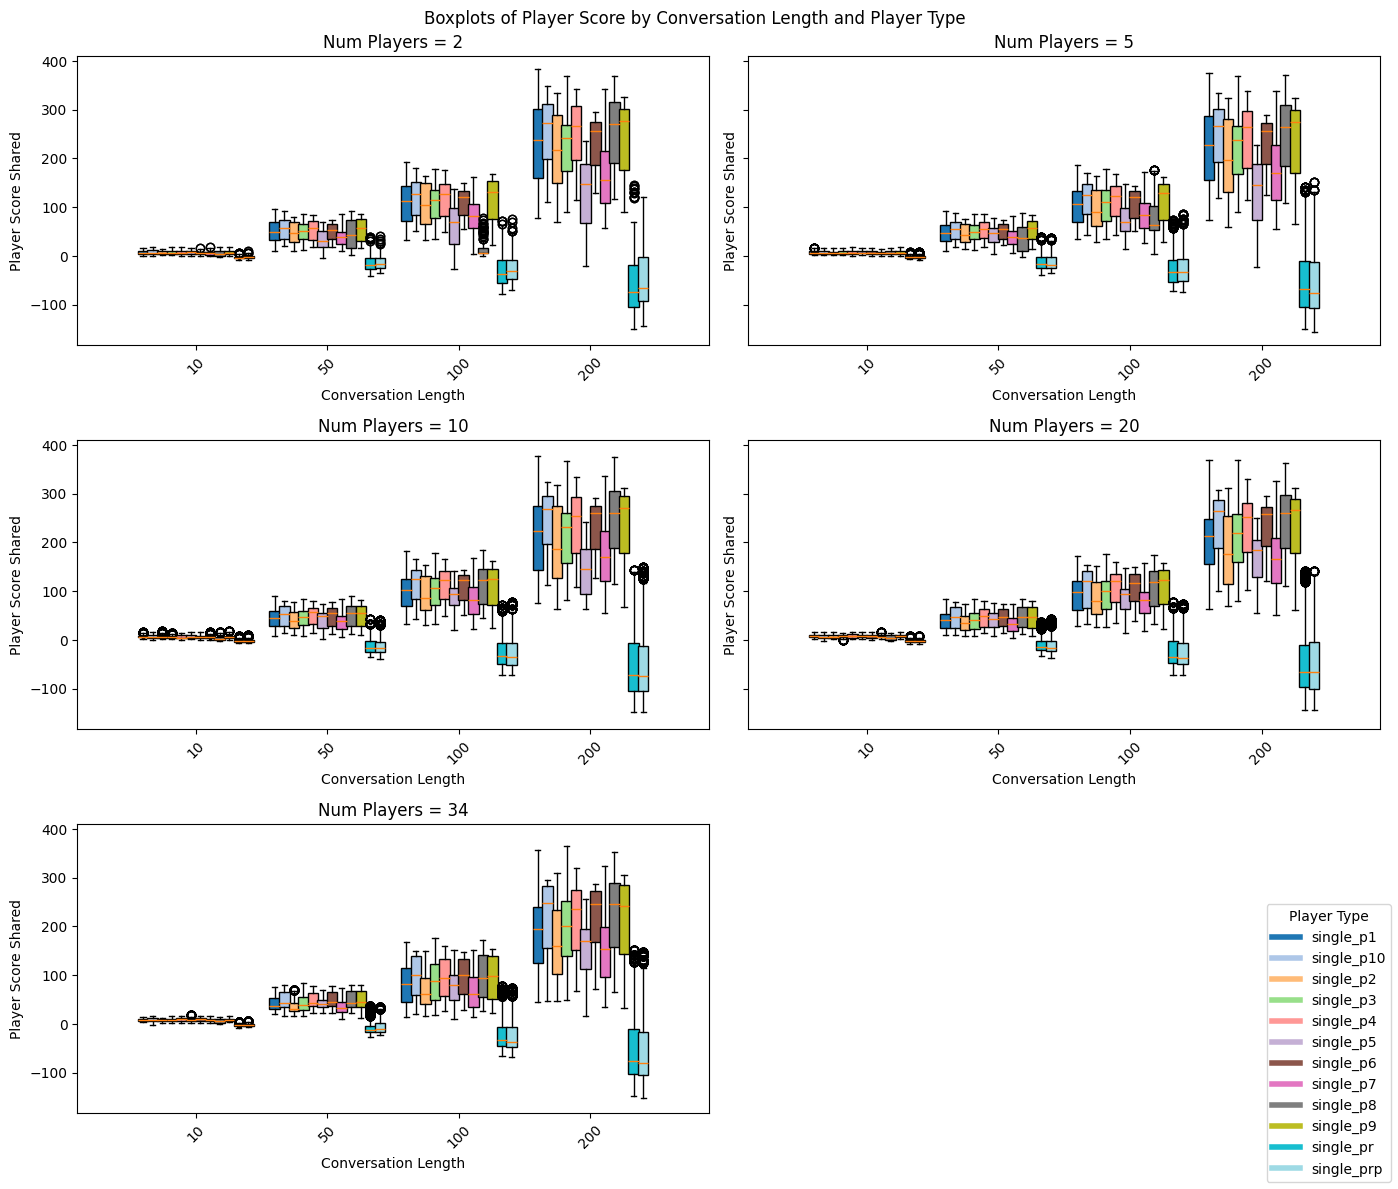

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = subset[subset["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "player_score_shared"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Player Score Shared")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/2247982910.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


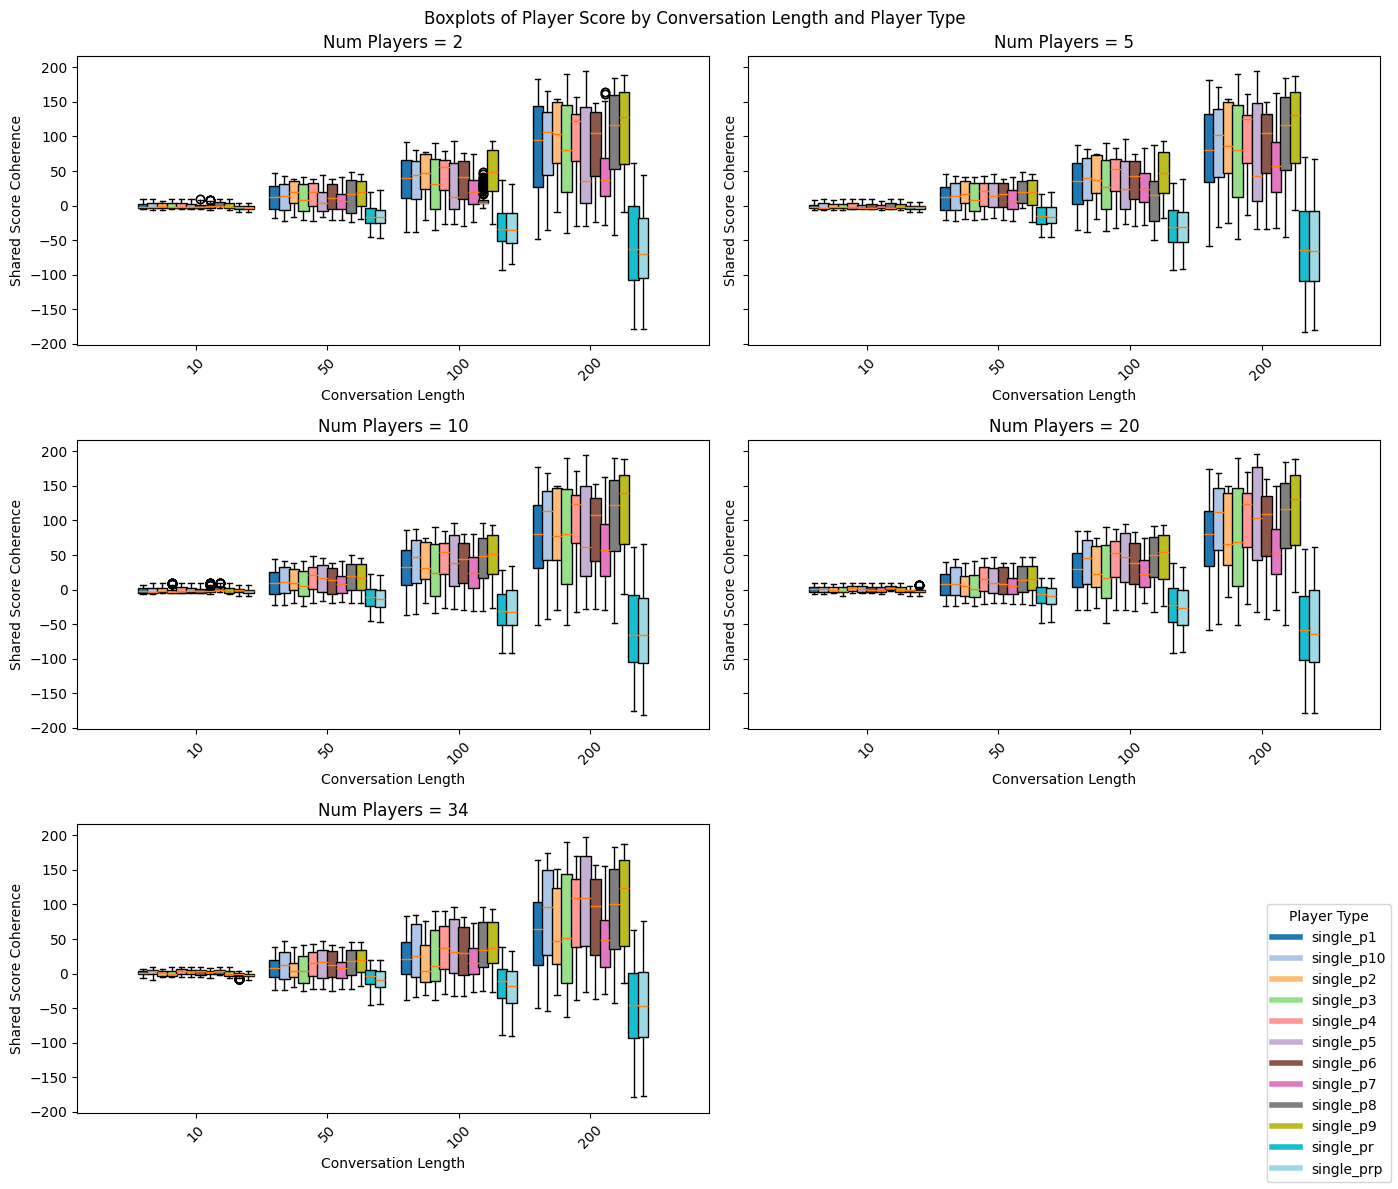

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = subset[subset["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "shared_score_coherence"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Shared Score Coherence")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/4119426623.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


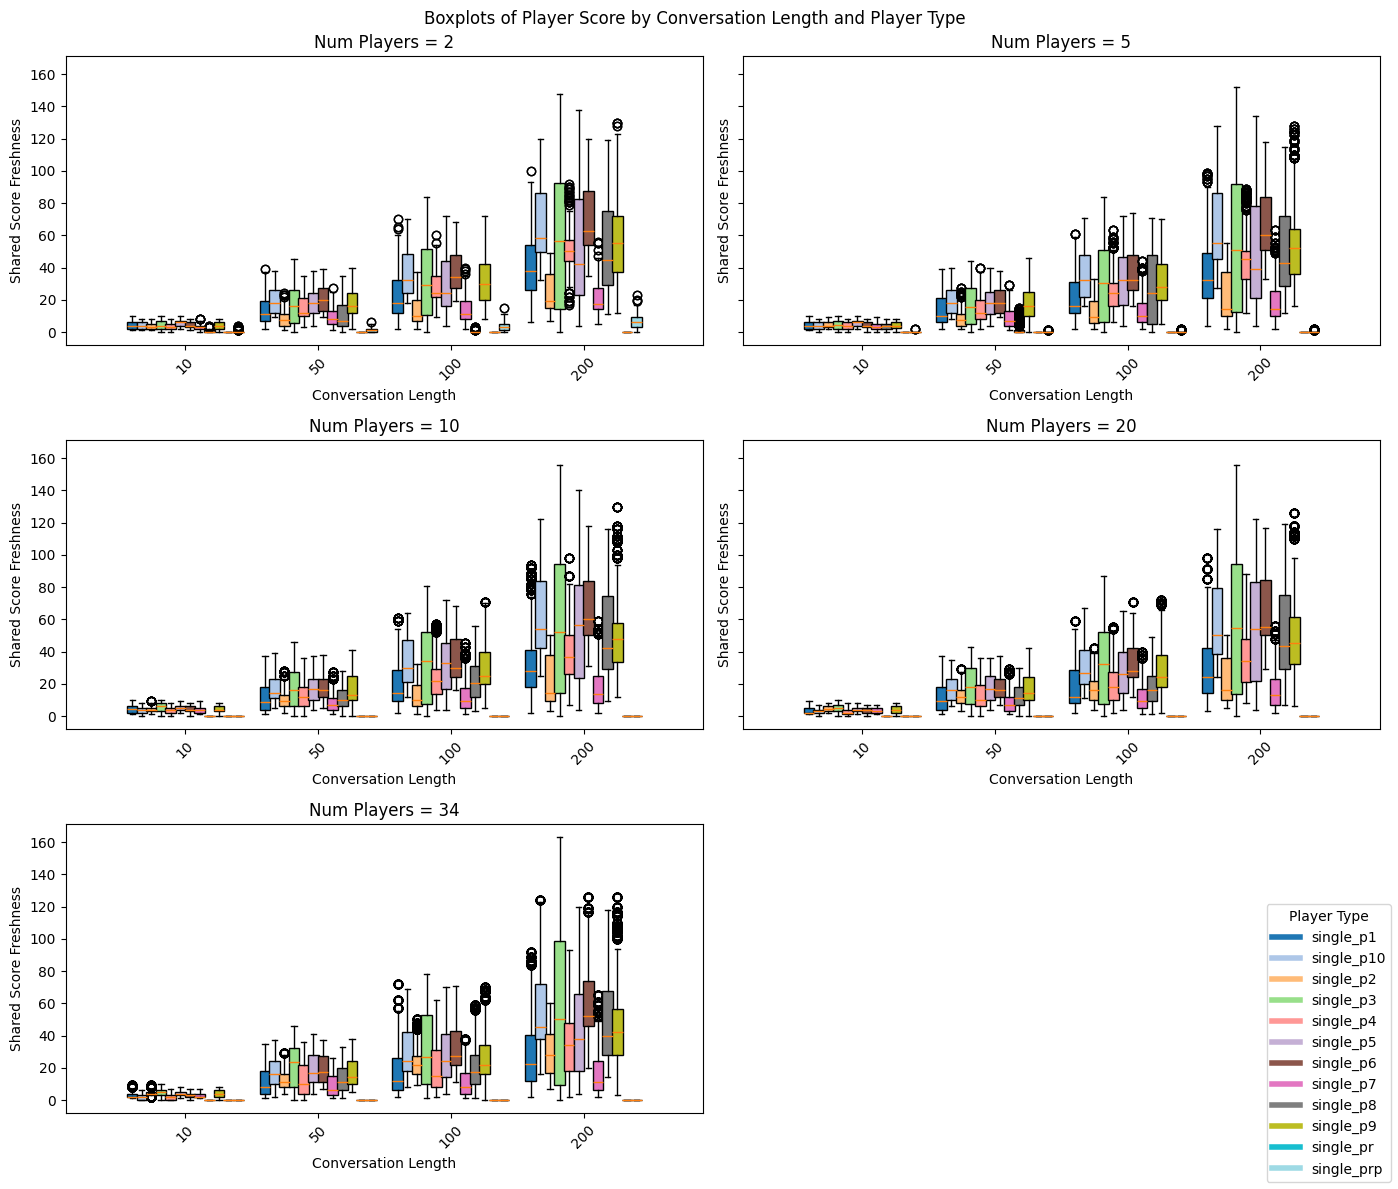

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = subset[subset["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "shared_score_freshness"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Shared Score Freshness")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/2483188594.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


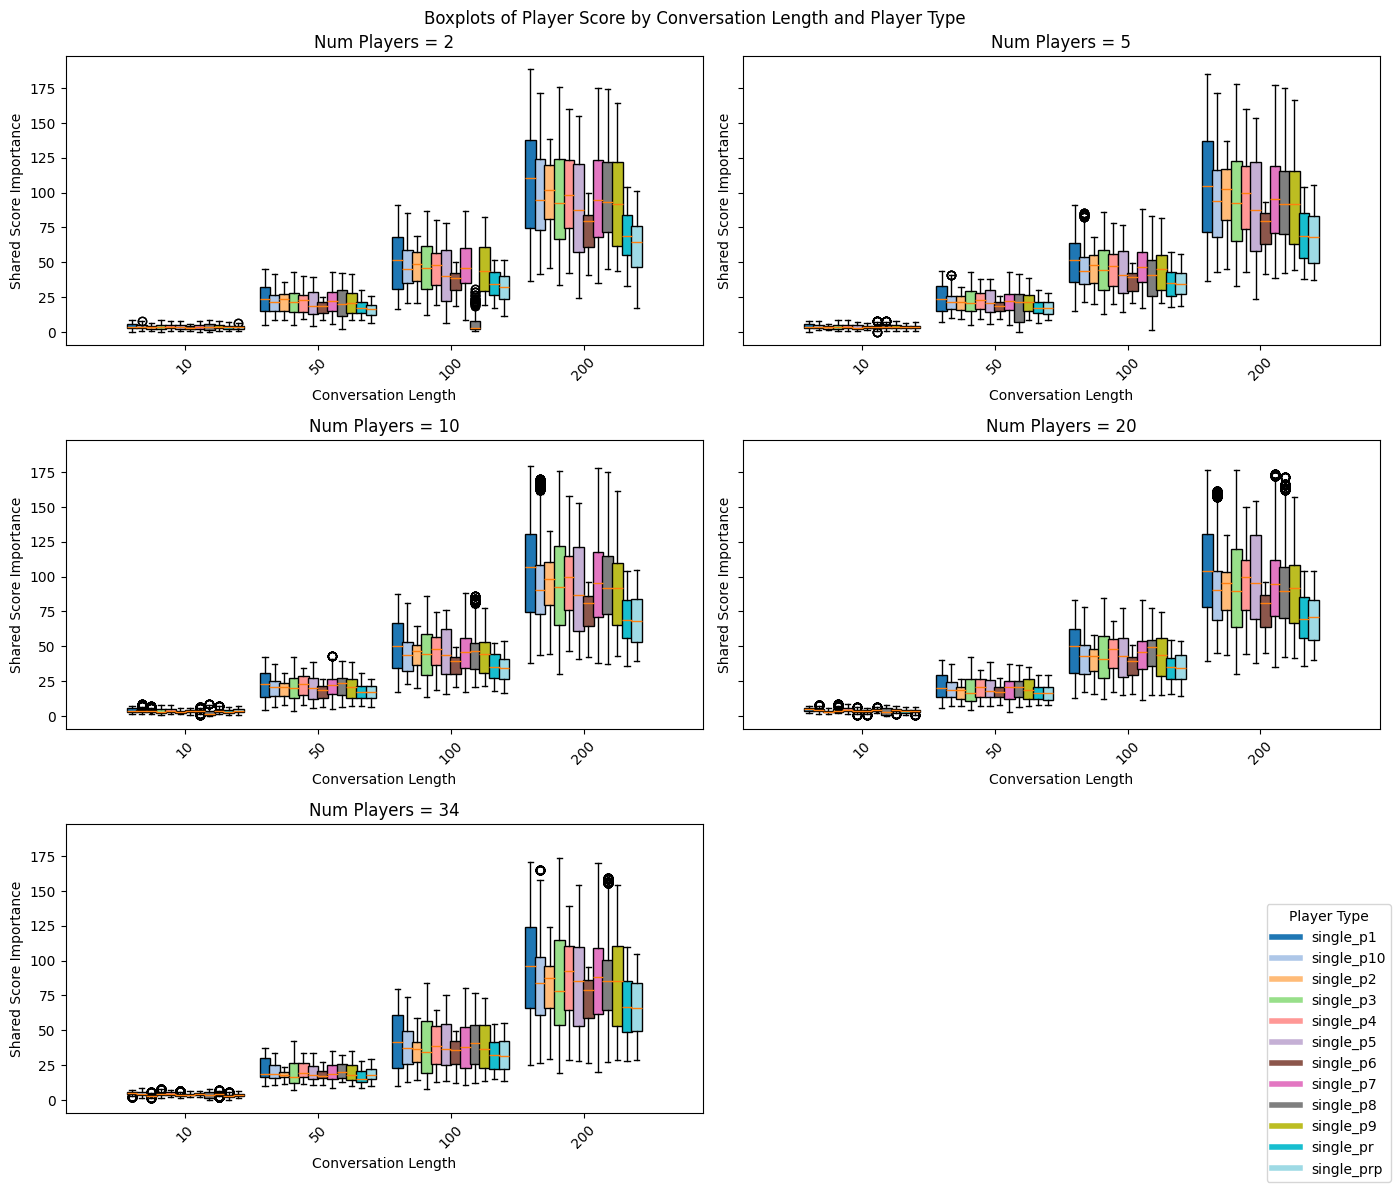

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = subset[subset["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "shared_score_importance"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Shared Score Importance")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/1401408859.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


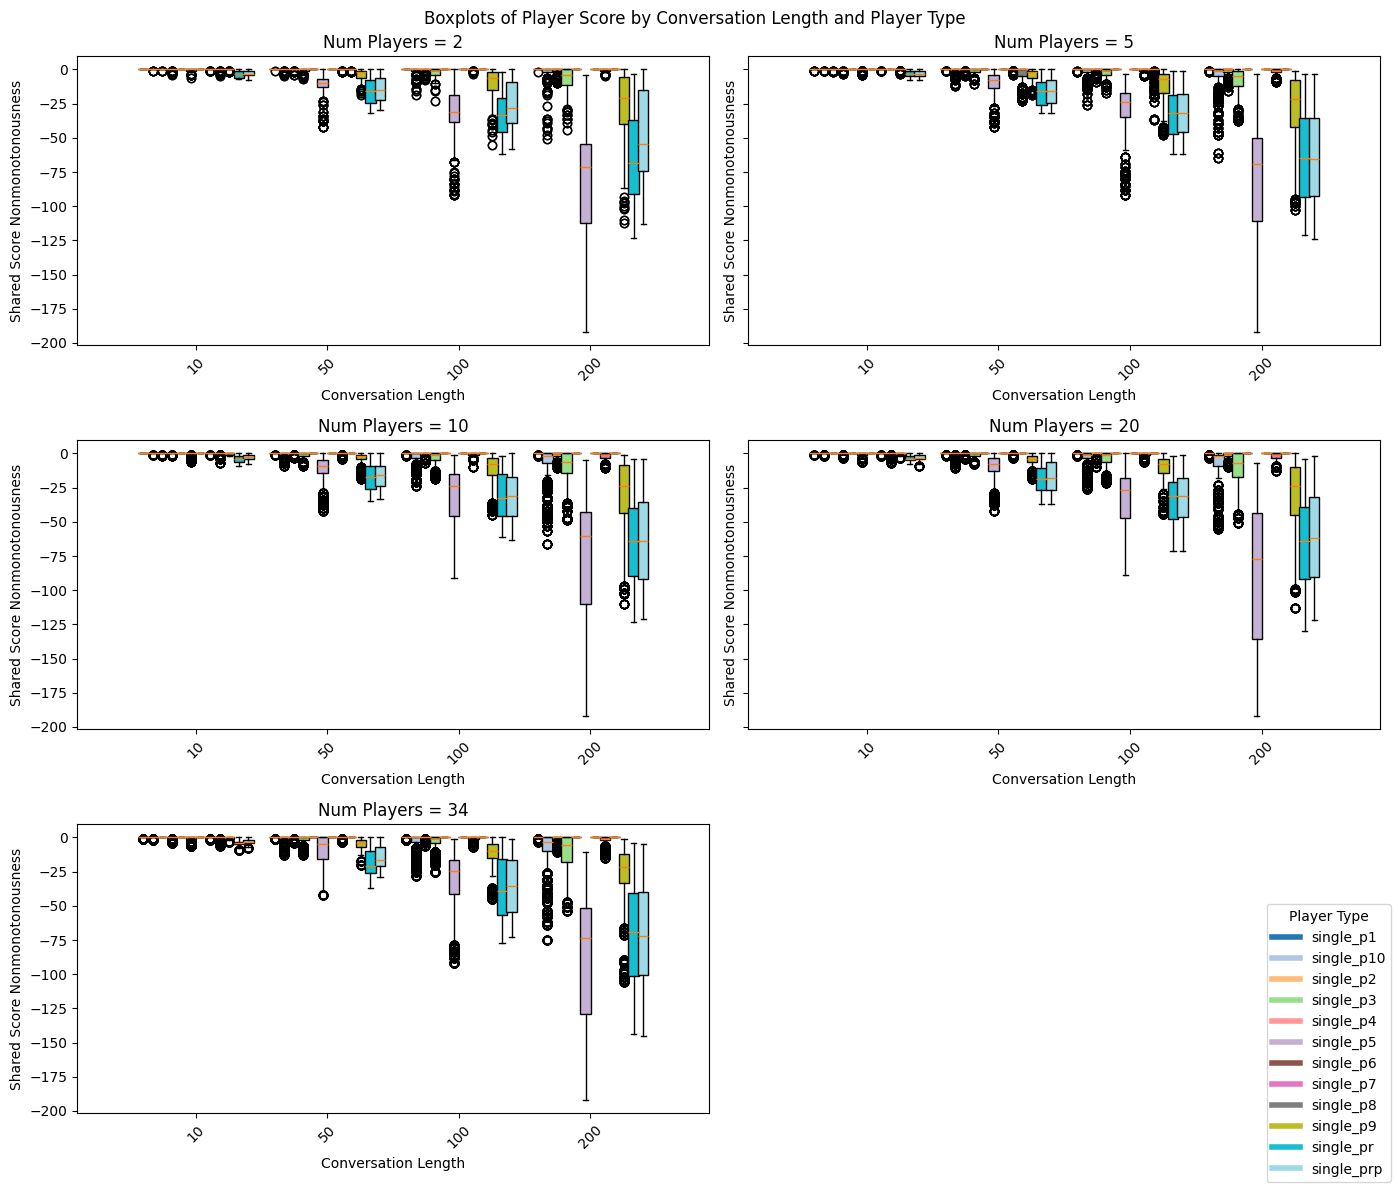

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: 3 rows × 2 cols
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, num in enumerate(num_players_vals):
    ax = axes[i]
    data = subset[subset["num_players"] == num]

    conv_lens = sorted(data["conversation_length"].unique())
    n_conv = len(conv_lens)
    n_players = len(player_types)

    # width of each box group and offsets
    box_width = 0.08
    offsets = np.linspace(-0.4, 0.4, n_players)

    for j, ptype in enumerate(player_types):
        box_data = []
        for conv_len in conv_lens:
            vals = data.loc[
                (data["conversation_length"] == conv_len) &
                (data["player_selection_type"] == ptype),
                "shared_score_nonmonotonousness"
            ]
            box_data.append(vals.values)

        # Positions shifted by player index
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True
        )

        # Color boxes
        for patch in bp["boxes"]:
            patch.set_facecolor(color_map[ptype])

    ax.set_title(f"Num Players = {num}")
    ax.set_xticks(range(len(conv_lens)))
    # ax.set_ylim(-10, 2)
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Shared Score Nonmonotonousness")

# Remove extra subplot slots
for j in range(len(num_players_vals), len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_handles = [plt.Line2D([0], [0], color=color_map[ptype], lw=4) for ptype in player_types]
fig.legend(legend_handles, player_types, title="Player Type", loc="lower right")

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


### Conversation Length and Memory Size

/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/3253389634.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


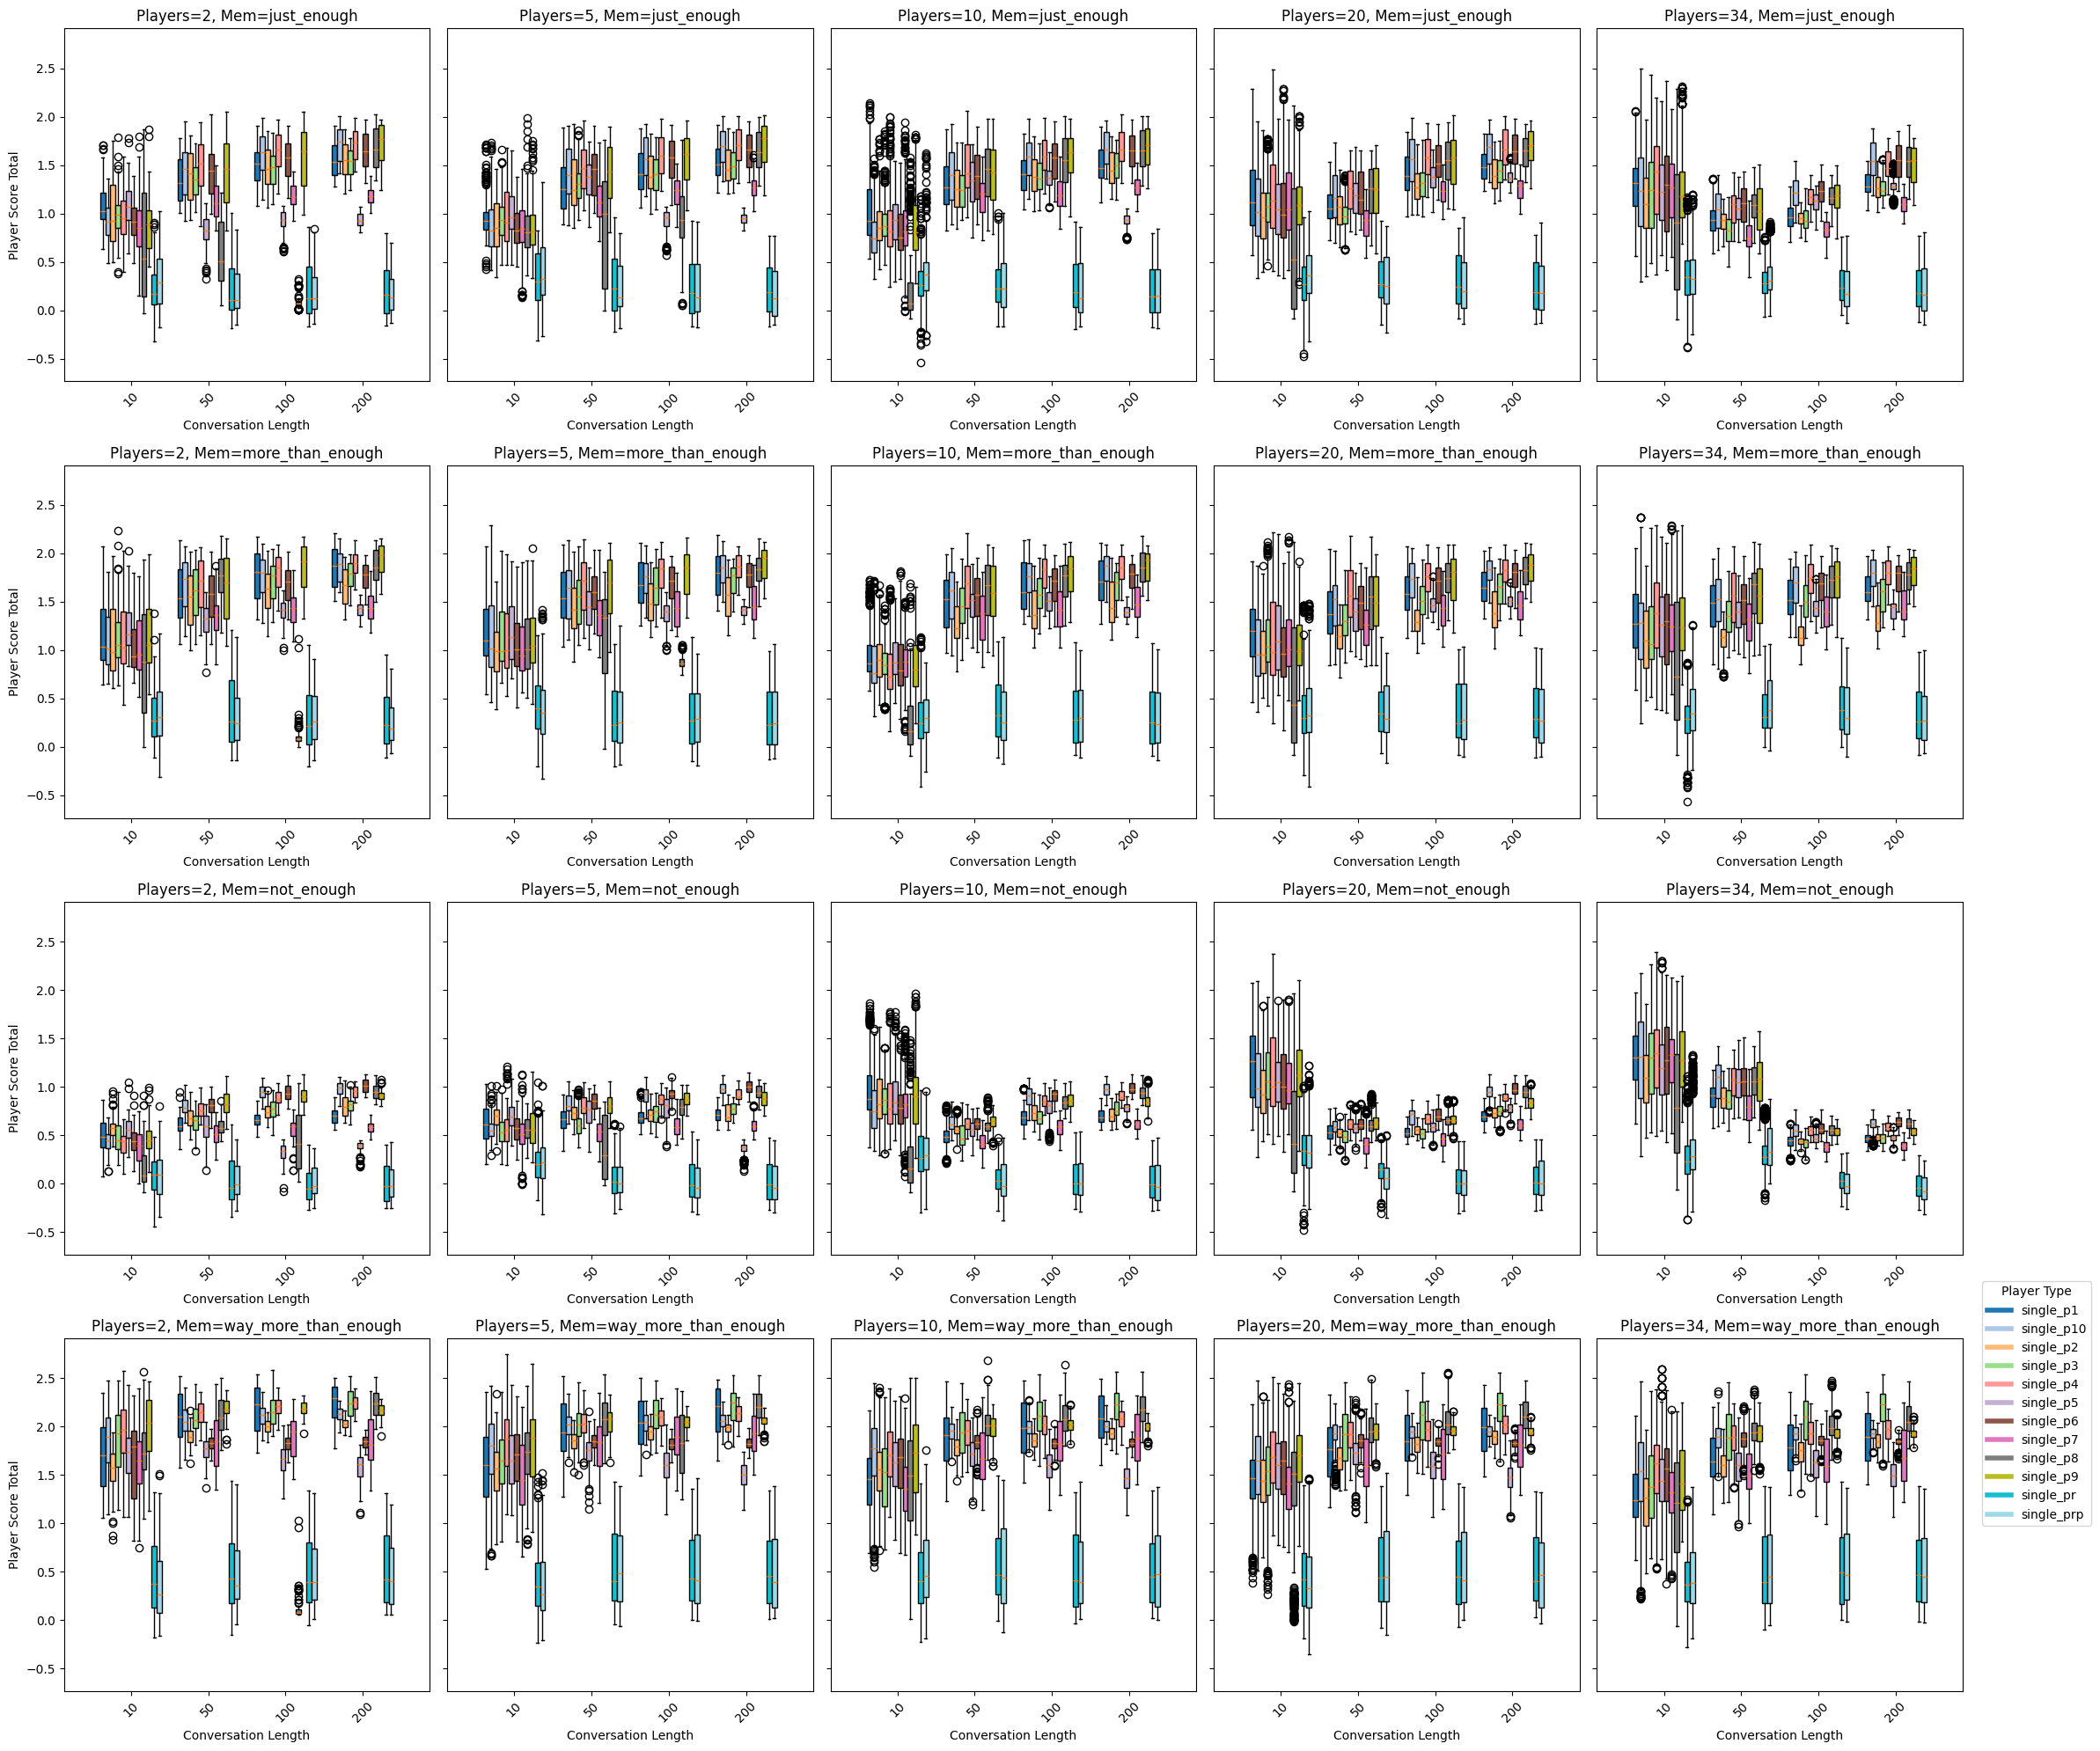

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
memory_vals = sorted(subset["memory_size_key"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign unique colors to each player
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: rows = memory_size_key, cols = num_players
fig, axes = plt.subplots(
    len(memory_vals), len(num_players_vals),
    figsize=(5 * len(num_players_vals), 5 * len(memory_vals)),
    sharey=True
)

# Make axes 2D array even if single row/col
if len(memory_vals) == 1:
    axes = np.array([axes])
if len(num_players_vals) == 1:
    axes = axes[:, np.newaxis]

for r, mem in enumerate(memory_vals):
    for c, num in enumerate(num_players_vals):
        ax = axes[r, c]
        data = subset[
            (subset["memory_size_key"] == mem) &
            (subset["num_players"] == num)
        ]
        conv_lens = sorted(data["conversation_length"].unique())
        n_conv = len(conv_lens)
        n_players = len(player_types)

        # spacing
        group_width = 0.8
        box_width = group_width / n_players
        offsets = np.linspace(
            -group_width/2 + box_width/2,
            group_width/2 - box_width/2,
            n_players
        )

        for j, ptype in enumerate(player_types):
            box_data = []
            for conv_len in conv_lens:
                vals = data.loc[
                    (data["conversation_length"] == conv_len) &
                    (data["player_selection_type"] == ptype),
                    "player_score_total"
                ]
                box_data.append(vals.dropna().values)

            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_title(f"Players={num}, Mem={mem}")
        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        if c == 0:
            ax.set_ylabel("Player Score Total")

# Legend for players (outside the plot, right-hand side)
legend_handles = [
    plt.Line2D([0], [0], color=color_map[p], lw=4) for p in player_types
]
fig.legend(
    legend_handles,
    player_types,
    title="Player Type",
    loc="center left",
    bbox_to_anchor=(0.9, 0.2)   # position outside to the right
)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for the legend
plt.show()

### Conversation Length and Subjects

/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/2697453706.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


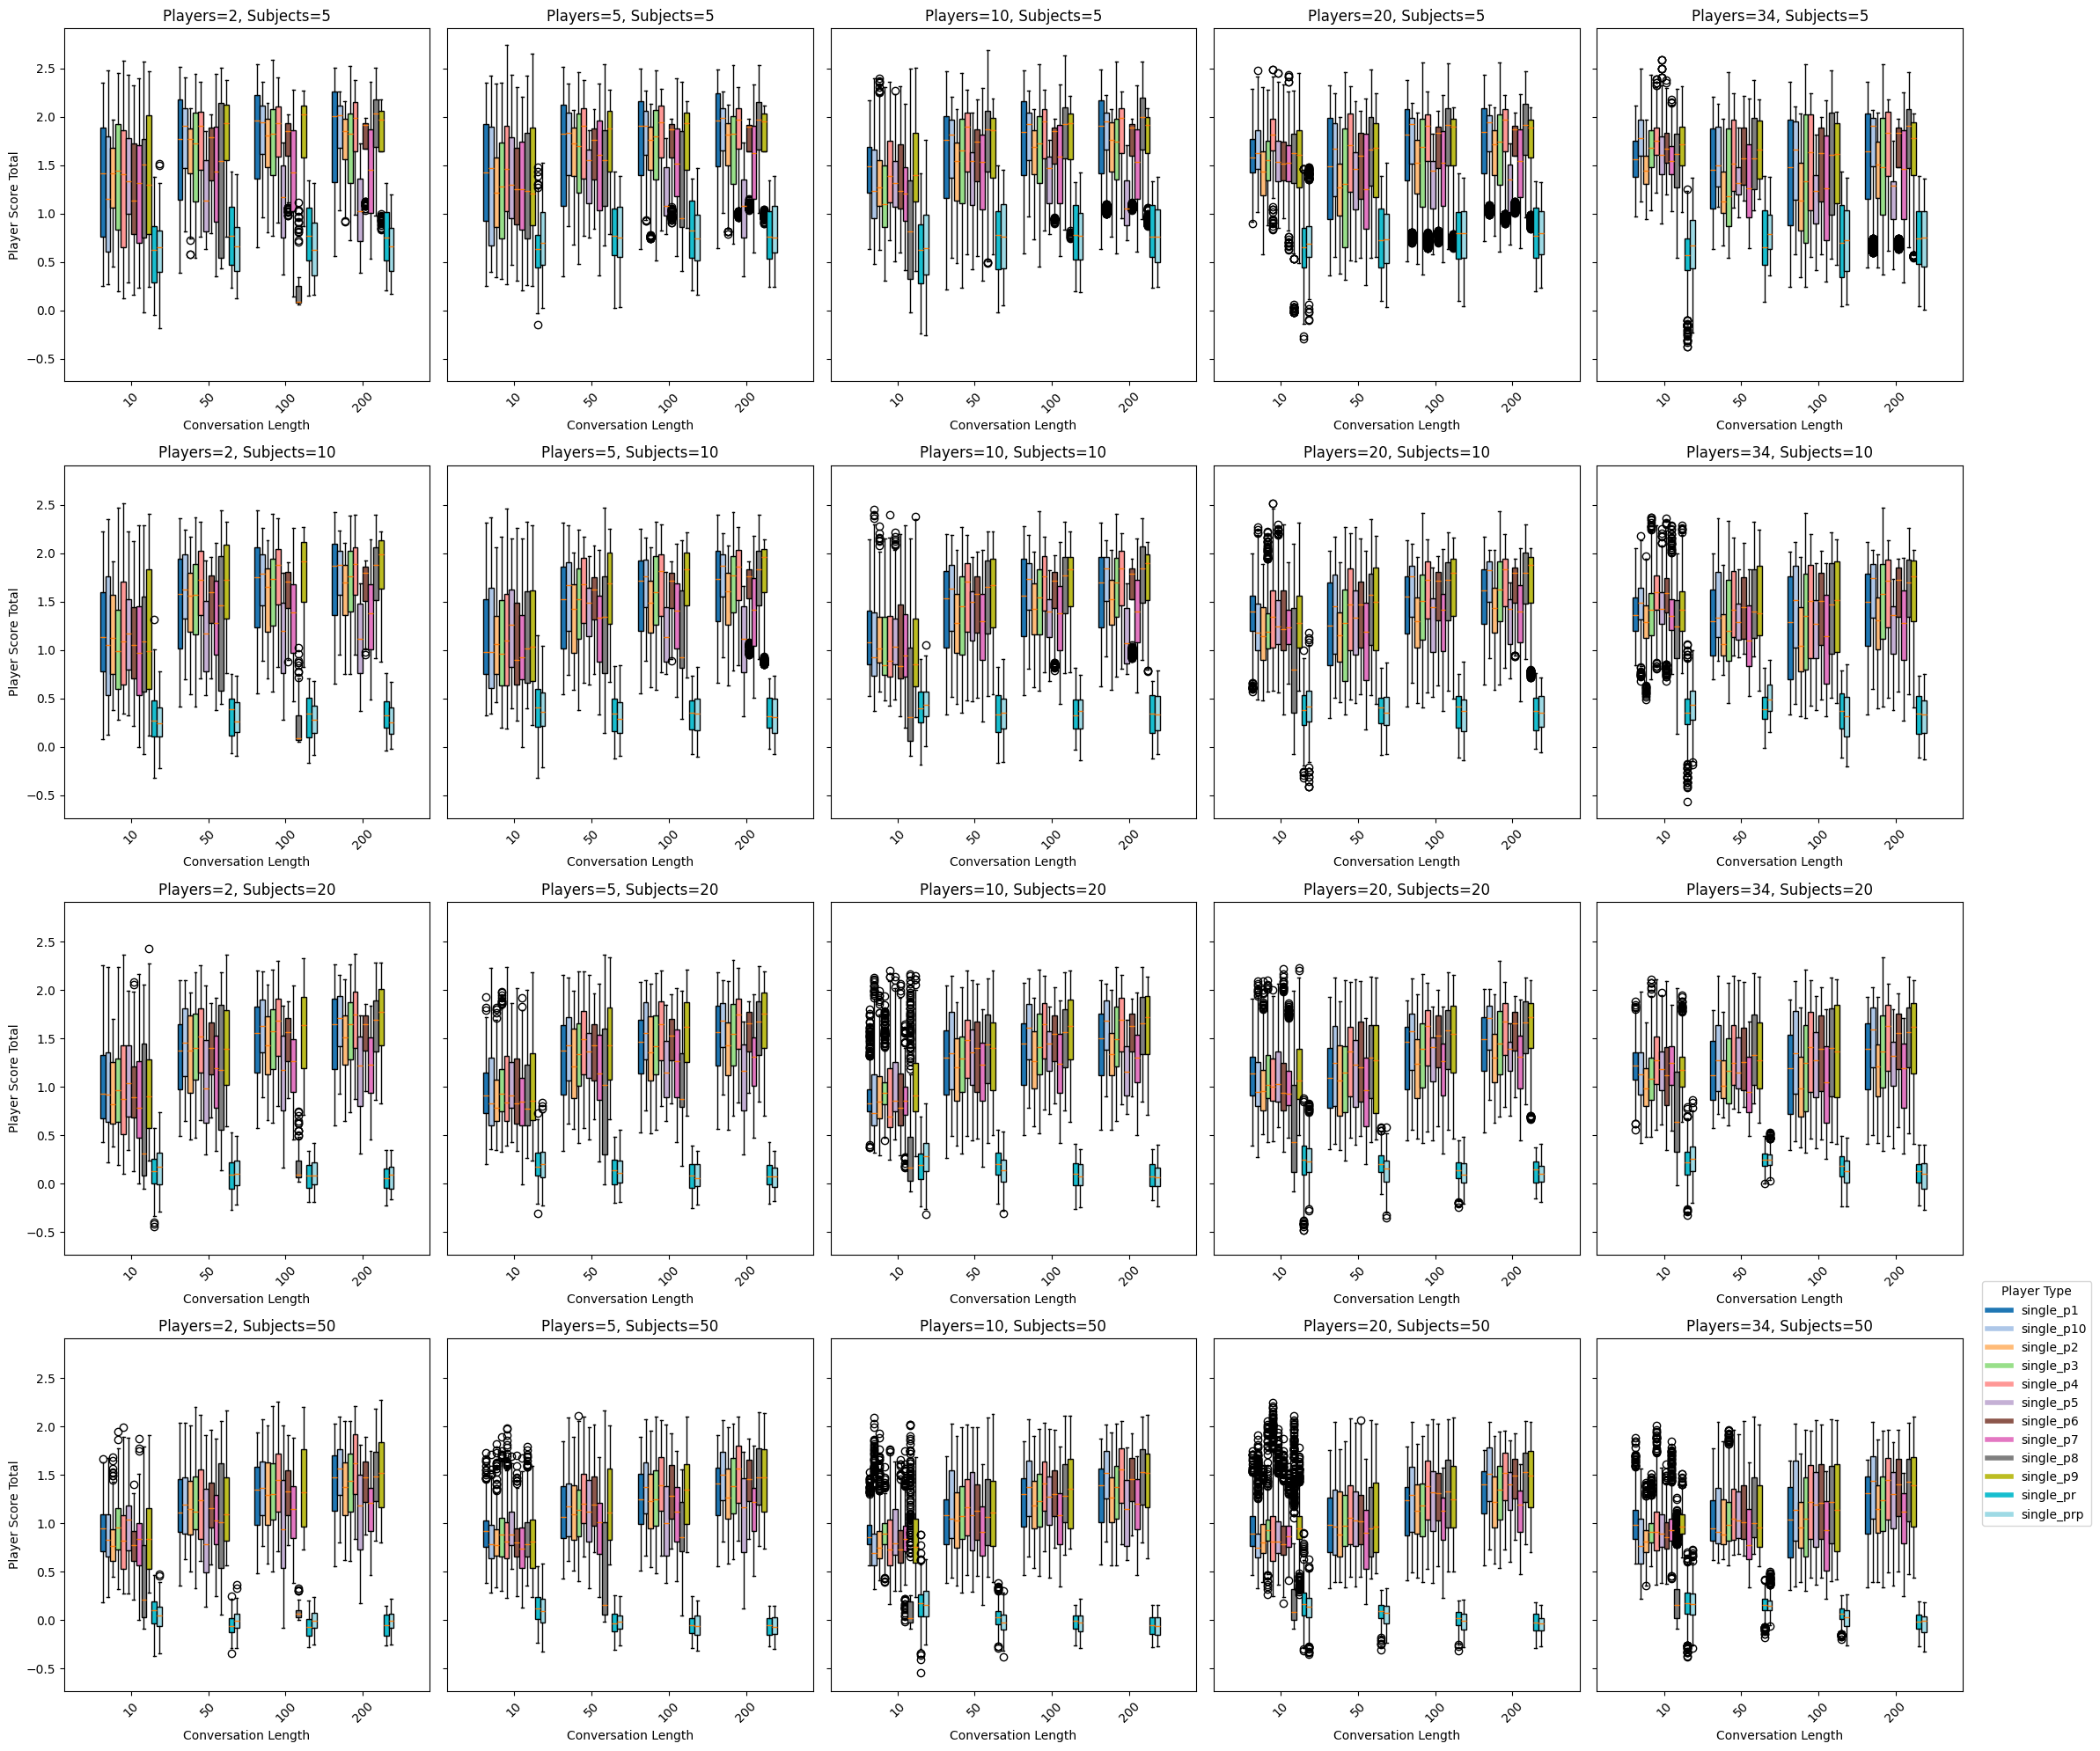

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
memory_vals = sorted(subset["num_subjects"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign unique colors to each player
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: rows = memory_size_key, cols = num_players
fig, axes = plt.subplots(
    len(memory_vals), len(num_players_vals),
    figsize=(5 * len(num_players_vals), 5 * len(memory_vals)),
    sharey=True
)

# Make axes 2D array even if single row/col
if len(memory_vals) == 1:
    axes = np.array([axes])
if len(num_players_vals) == 1:
    axes = axes[:, np.newaxis]

for r, mem in enumerate(memory_vals):
    for c, num in enumerate(num_players_vals):
        ax = axes[r, c]
        data = subset[
            (subset["num_subjects"] == mem) &
            (subset["num_players"] == num)
        ]
        conv_lens = sorted(data["conversation_length"].unique())
        n_conv = len(conv_lens)
        n_players = len(player_types)

        # spacing
        group_width = 0.8
        box_width = group_width / n_players
        offsets = np.linspace(
            -group_width/2 + box_width/2,
            group_width/2 - box_width/2,
            n_players
        )

        for j, ptype in enumerate(player_types):
            box_data = []
            for conv_len in conv_lens:
                vals = data.loc[
                    (data["conversation_length"] == conv_len) &
                    (data["player_selection_type"] == ptype),
                    "player_score_total"
                ]
                box_data.append(vals.dropna().values)

            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_title(f"Players={num}, Subjects={mem}")
        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        if c == 0:
            ax.set_ylabel("Player Score Total")

# Legend for players (outside the plot, right-hand side)
legend_handles = [
    plt.Line2D([0], [0], color=color_map[p], lw=4) for p in player_types
]
fig.legend(
    legend_handles,
    player_types,
    title="Player Type",
    loc="center left",
    bbox_to_anchor=(0.9, 0.2)   # position outside to the right
)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for the legend
plt.show()

/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/496203367.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


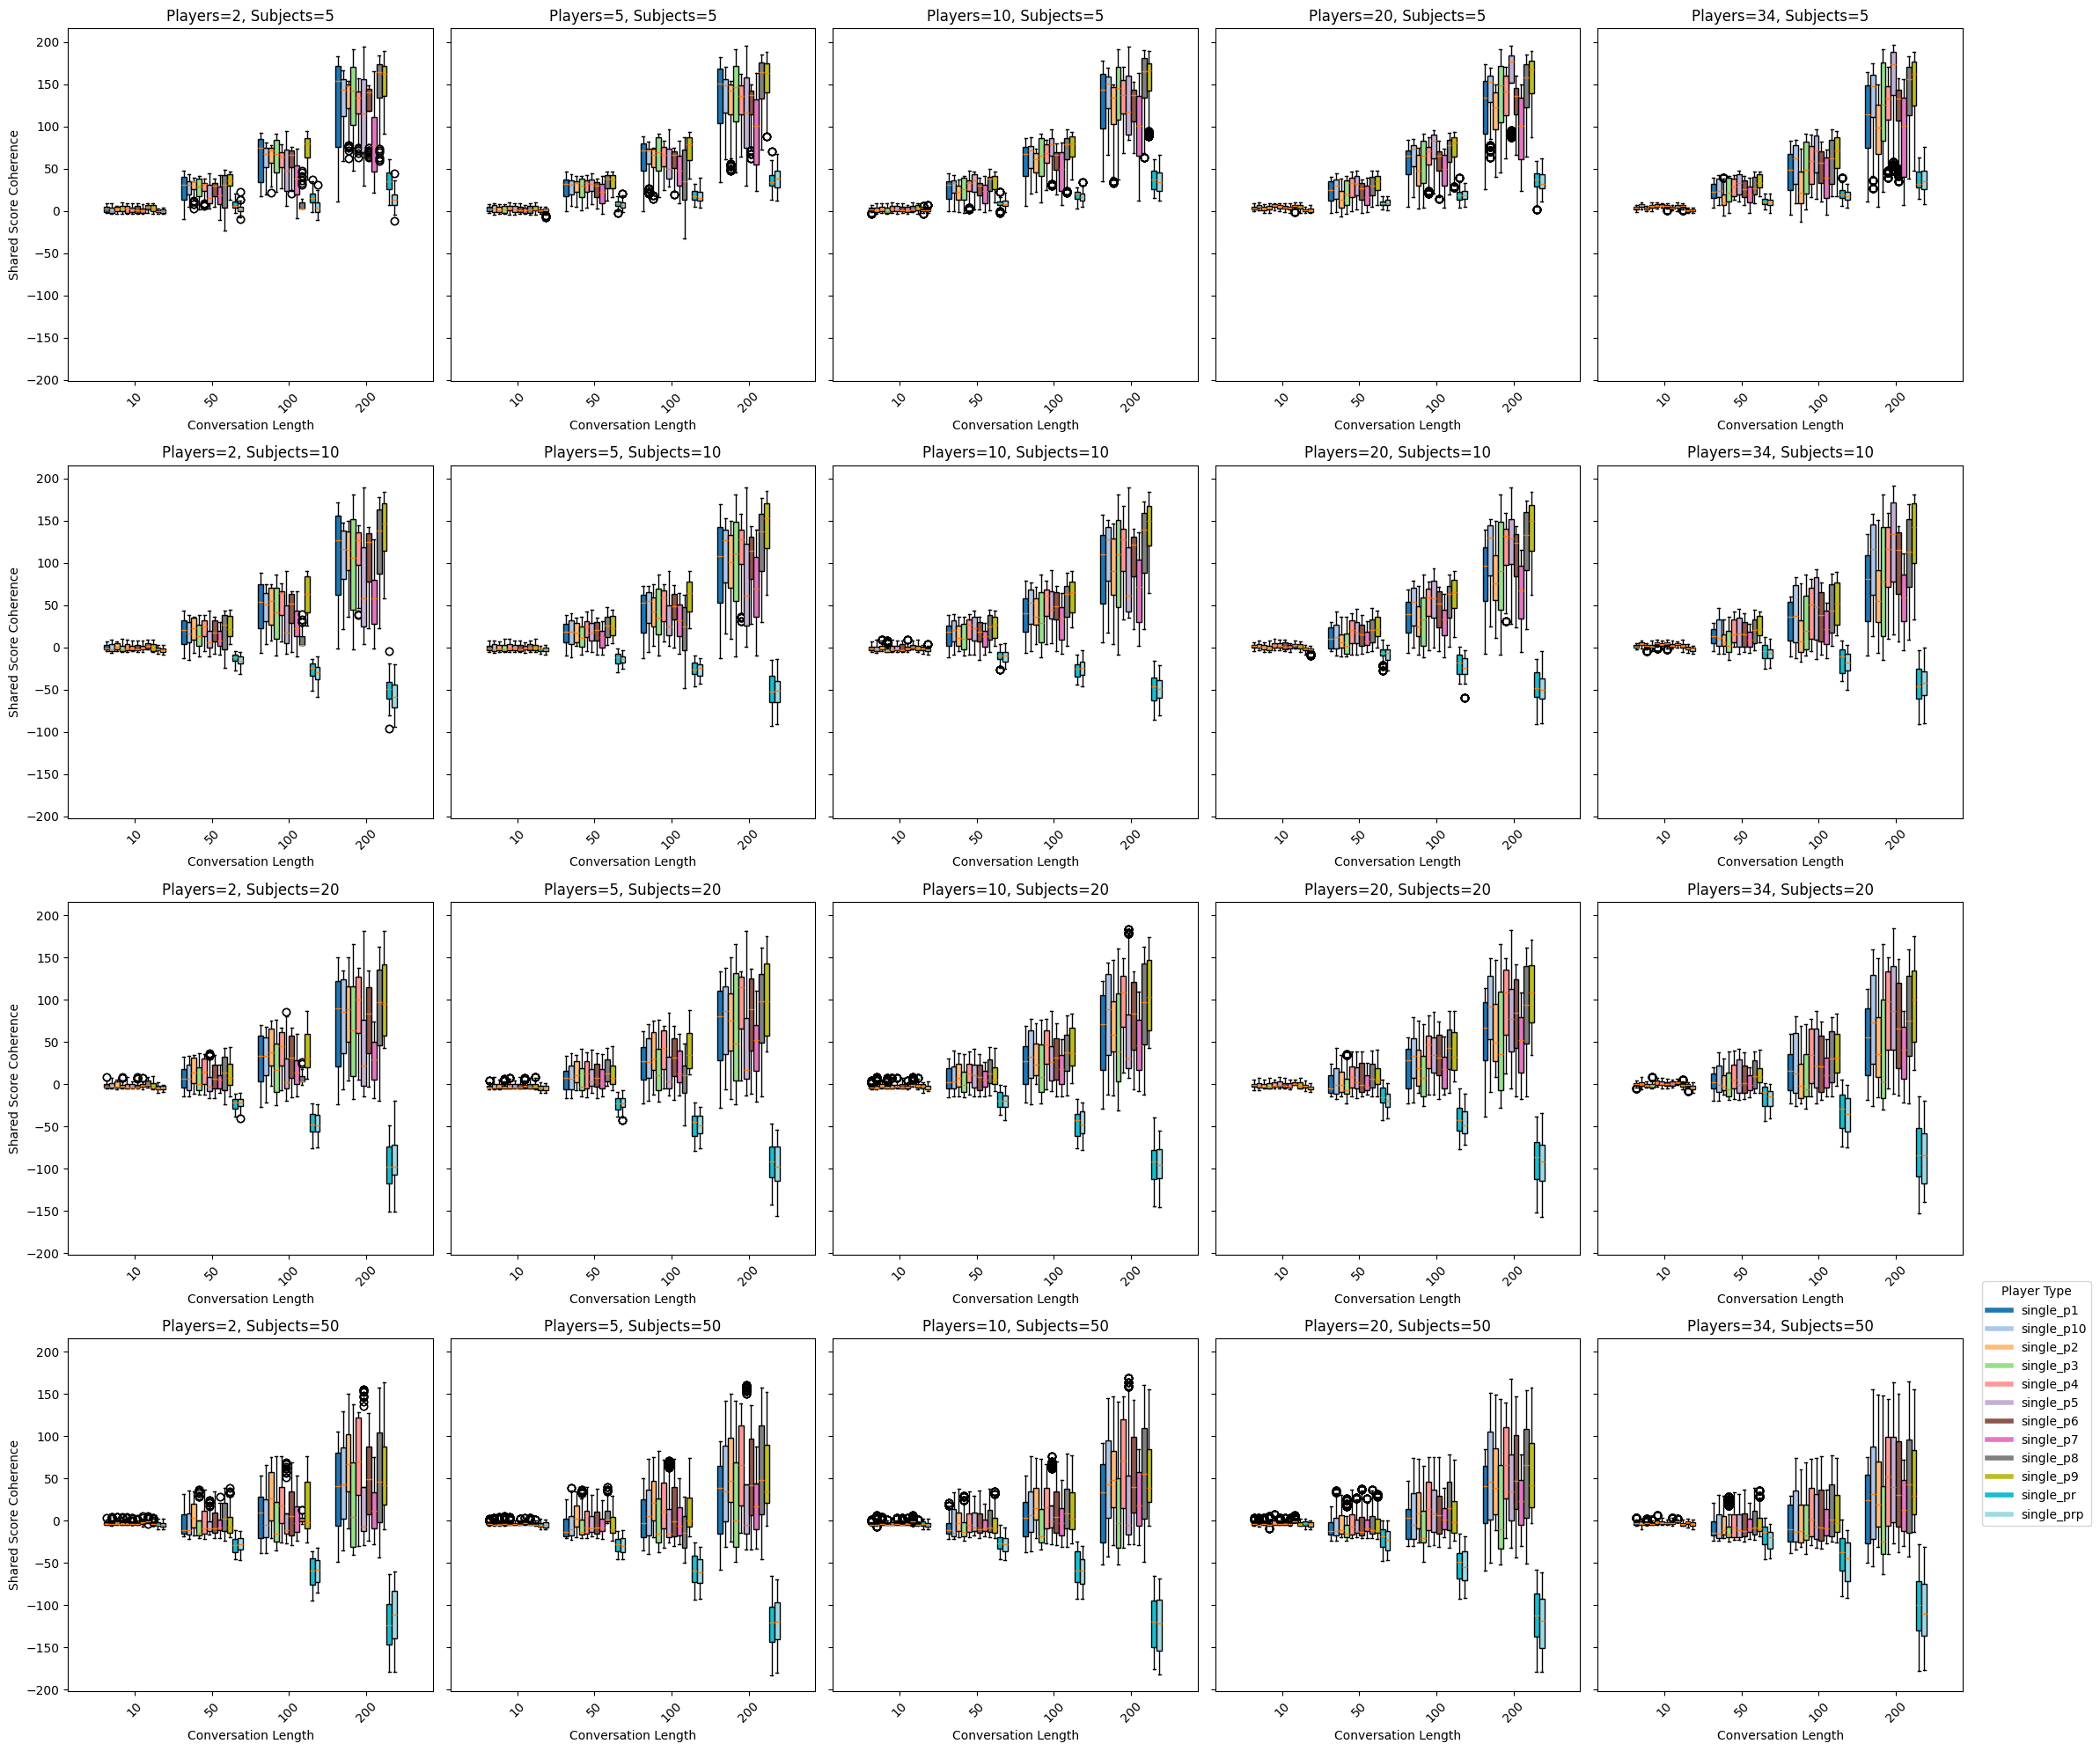

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
memory_vals = sorted(subset["num_subjects"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign unique colors to each player
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: rows = memory_size_key, cols = num_players
fig, axes = plt.subplots(
    len(memory_vals), len(num_players_vals),
    figsize=(5 * len(num_players_vals), 5 * len(memory_vals)),
    sharey=True
)

# Make axes 2D array even if single row/col
if len(memory_vals) == 1:
    axes = np.array([axes])
if len(num_players_vals) == 1:
    axes = axes[:, np.newaxis]

for r, mem in enumerate(memory_vals):
    for c, num in enumerate(num_players_vals):
        ax = axes[r, c]
        data = subset[
            (subset["num_subjects"] == mem) &
            (subset["num_players"] == num)
        ]
        conv_lens = sorted(data["conversation_length"].unique())
        n_conv = len(conv_lens)
        n_players = len(player_types)

        # spacing
        group_width = 0.8
        box_width = group_width / n_players
        offsets = np.linspace(
            -group_width/2 + box_width/2,
            group_width/2 - box_width/2,
            n_players
        )

        for j, ptype in enumerate(player_types):
            box_data = []
            for conv_len in conv_lens:
                vals = data.loc[
                    (data["conversation_length"] == conv_len) &
                    (data["player_selection_type"] == ptype),
                    "shared_score_coherence"
                ]
                box_data.append(vals.dropna().values)

            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_title(f"Players={num}, Subjects={mem}")
        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        if c == 0:
            ax.set_ylabel("Shared Score Coherence")

# Legend for players (outside the plot, right-hand side)
legend_handles = [
    plt.Line2D([0], [0], color=color_map[p], lw=4) for p in player_types
]
fig.legend(
    legend_handles,
    player_types,
    title="Player Type",
    loc="center left",
    bbox_to_anchor=(0.9, 0.2)   # position outside to the right
)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for the legend
plt.show()

/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/2644232888.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


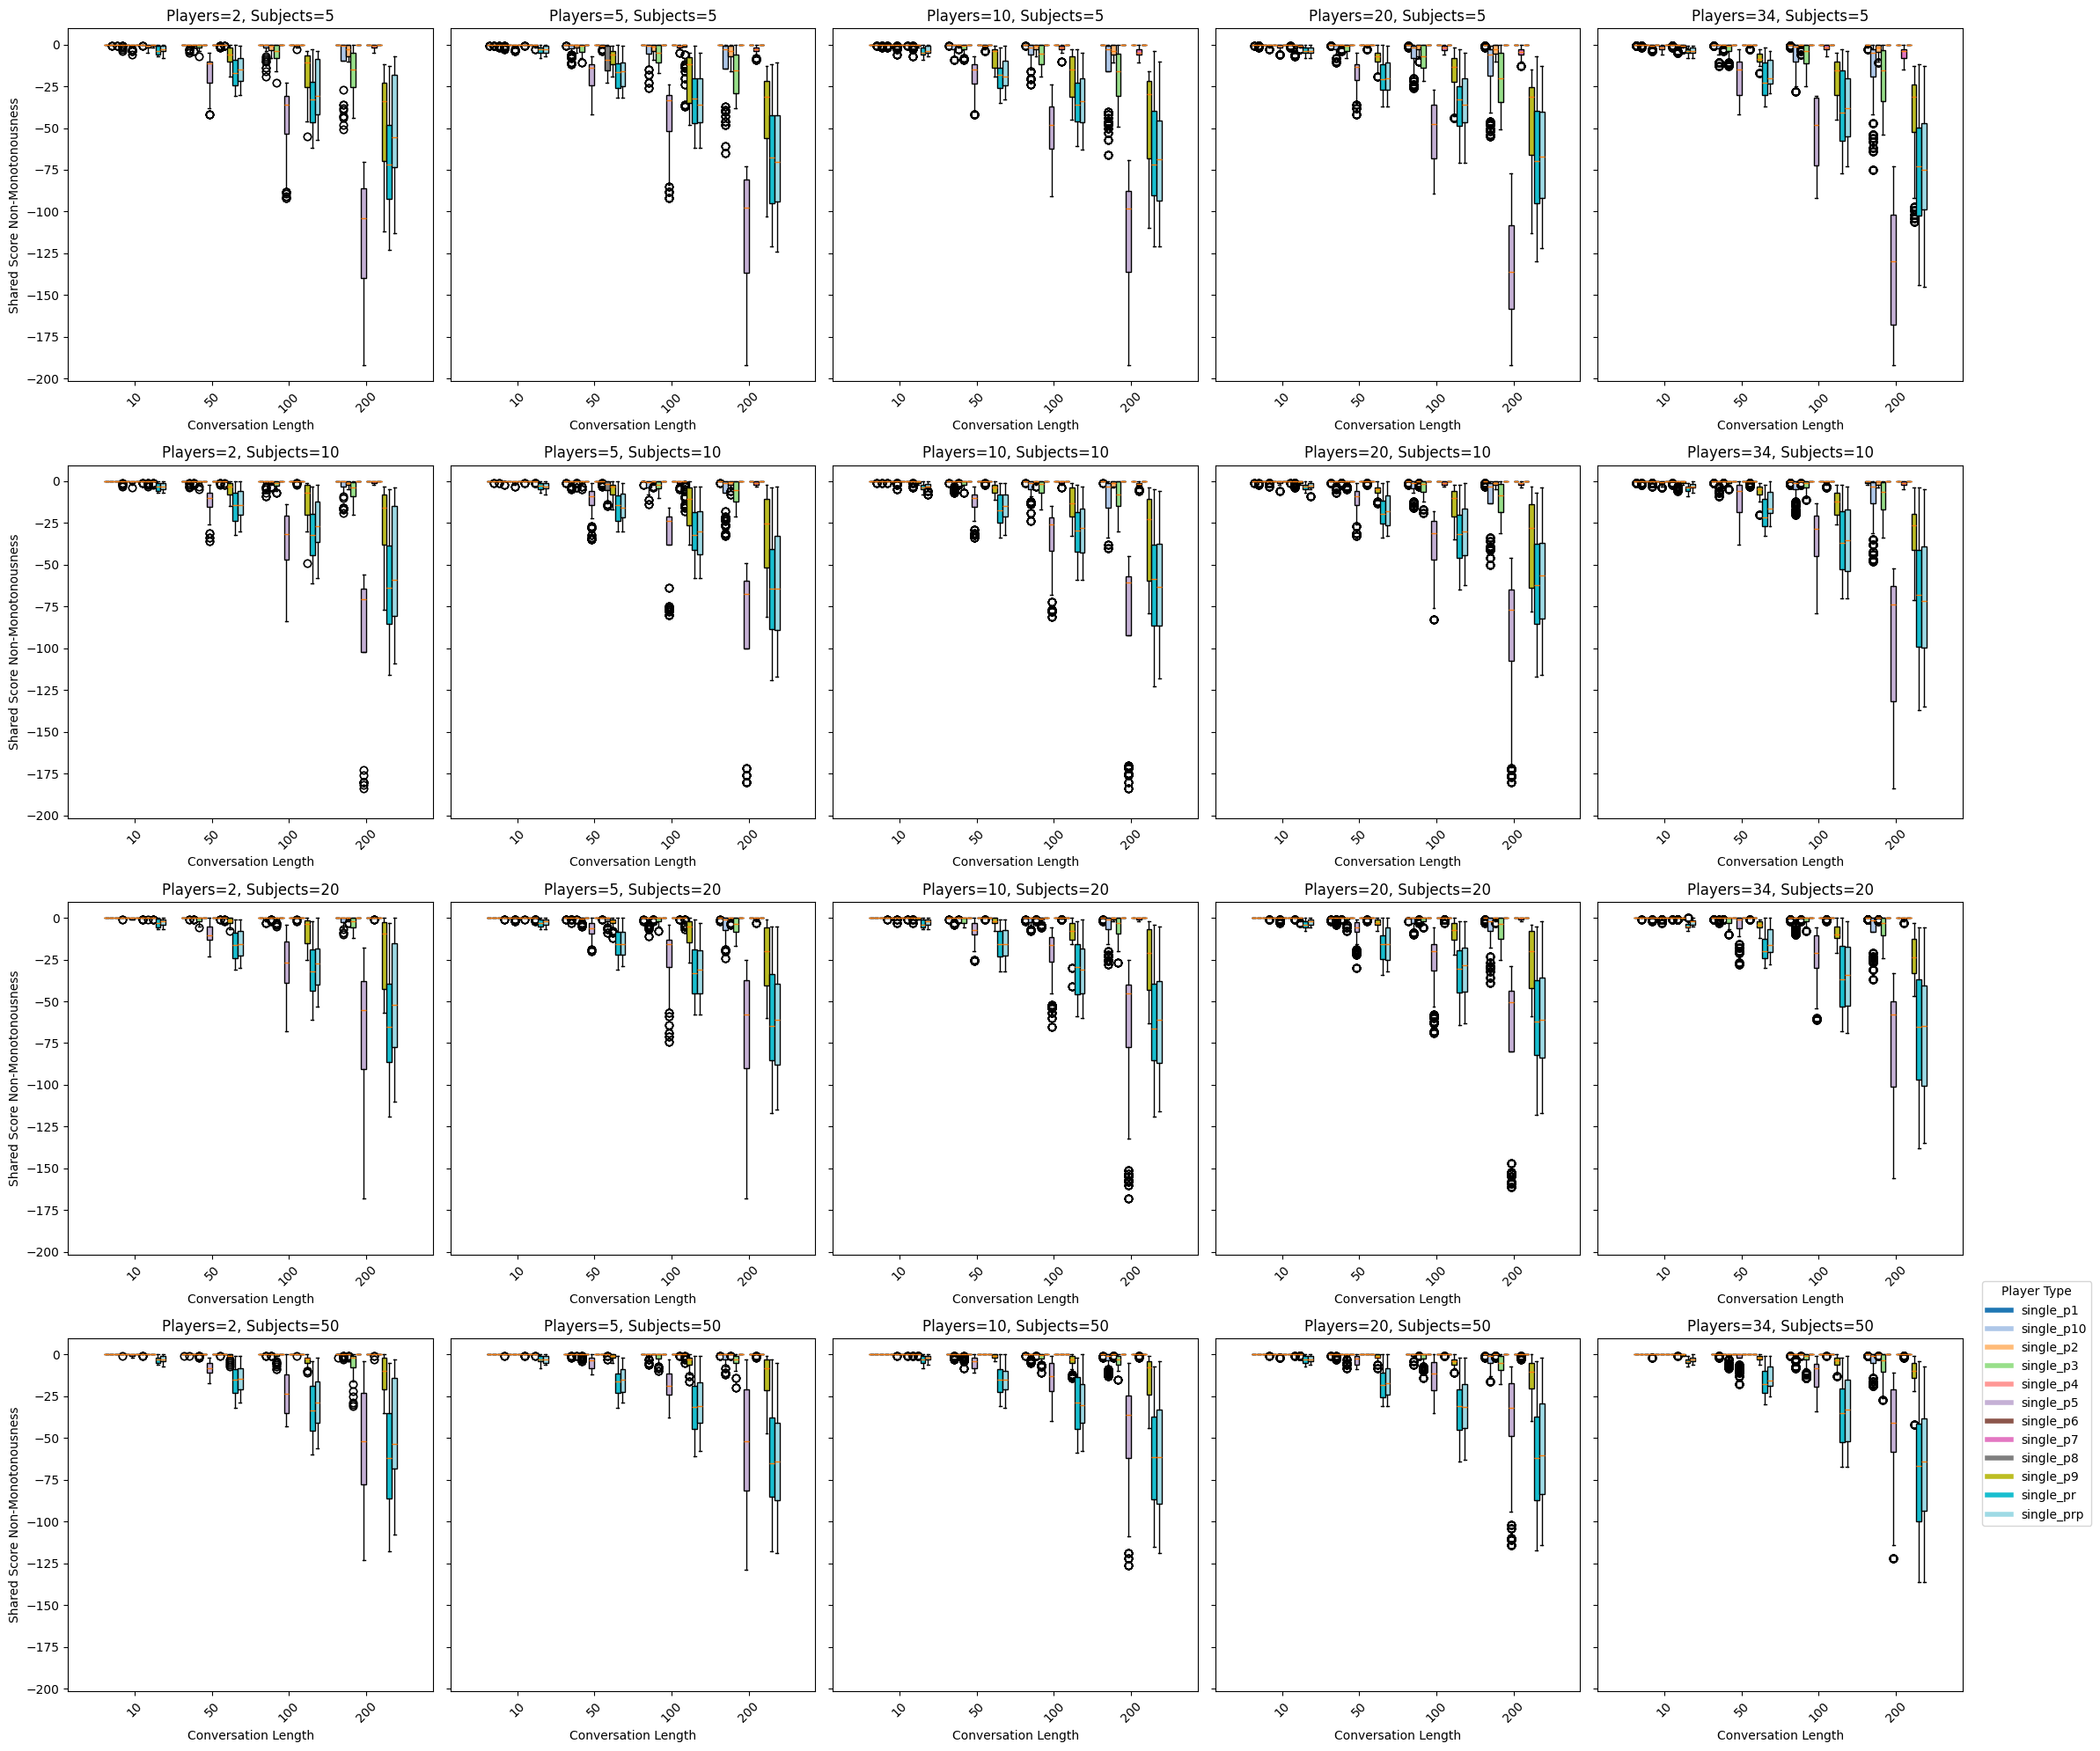

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("single_p")]

num_players_vals = sorted(subset["num_players"].unique())
memory_vals = sorted(subset["num_subjects"].unique())
player_types = sorted(subset["player_selection_type"].unique())

# Assign unique colors to each player
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: rows = memory_size_key, cols = num_players
fig, axes = plt.subplots(
    len(memory_vals), len(num_players_vals),
    figsize=(5 * len(num_players_vals), 5 * len(memory_vals)),
    sharey=True
)

# Make axes 2D array even if single row/col
if len(memory_vals) == 1:
    axes = np.array([axes])
if len(num_players_vals) == 1:
    axes = axes[:, np.newaxis]

for r, mem in enumerate(memory_vals):
    for c, num in enumerate(num_players_vals):
        ax = axes[r, c]
        data = subset[
            (subset["num_subjects"] == mem) &
            (subset["num_players"] == num)
        ]
        conv_lens = sorted(data["conversation_length"].unique())
        n_conv = len(conv_lens)
        n_players = len(player_types)

        # spacing
        group_width = 0.8
        box_width = group_width / n_players
        offsets = np.linspace(
            -group_width/2 + box_width/2,
            group_width/2 - box_width/2,
            n_players
        )

        for j, ptype in enumerate(player_types):
            box_data = []
            for conv_len in conv_lens:
                vals = data.loc[
                    (data["conversation_length"] == conv_len) &
                    (data["player_selection_type"] == ptype),
                    "shared_score_nonmonotonousness"
                ]
                box_data.append(vals.dropna().values)

            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_title(f"Players={num}, Subjects={mem}")
        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        if c == 0:
            ax.set_ylabel("Shared Score Non-Monotonousness")

# Legend for players (outside the plot, right-hand side)
legend_handles = [
    plt.Line2D([0], [0], color=color_map[p], lw=4) for p in player_types
]
fig.legend(
    legend_handles,
    player_types,
    title="Player Type",
    loc="center left",
    bbox_to_anchor=(0.9, 0.2)   # position outside to the right
)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for the legend
plt.show()

In [ ]:
df[(df.player_selection_type == 'single_p2') & (df.num_players == 2)]

,simulation_id,run_number,player_selection_type,num_players,player_list,conversation_length,num_subjects,memory_size_key,memory_size,shared_score_total,shared_score_importance,shared_score_coherence,shared_score_freshness,shared_score_nonmonotonousness,player_id,player_name,player_score_total,player_score_shared,player_score_individual
2434,b6f3a983-c5b2-4014-a383-756e26464f53,7,single_p2,2,"p2,p2",10,20,more_than_enough,7,4.77,3.77,-3.0,4.0,0.0,bb5cbc75-2f17-4542-8fc6-e0aa3483255e,Player2,0.77950,4.77,3.025
2435,b6f3a983-c5b2-4014-a383-756e26464f53,7,single_p2,2,"p2,p2",10,20,more_than_enough,7,4.77,3.77,-3.0,4.0,0.0,b861325a-1918-444a-a3dd-0431e852b3c7,Player2,0.79200,4.77,3.150
3462,a838e6be-c7e8-4824-925d-4550ab21a08b,1,single_p2,2,"p2,p2",200,10,just_enough,100,227.31,99.31,112.0,17.0,-1.0,25c42f10-ab29-4c6d-a871-ca072c664ca9,Player2,1.60955,227.31,94.600
3463,a838e6be-c7e8-4824-925d-4550ab21a08b,1,single_p2,2,"p2,p2",200,10,just_enough,100,227.31,99.31,112.0,17.0,-1.0,cb306662-10c5-46ac-9ec0-208f81943014,Player2,1.60330,227.31,93.350
5964,1585819d-fc7a-451e-91d1-7173fbe9d15f,4,single_p2,2,"p2,p2",50,50,not_enough,12,13.45,10.45,-12.0,15.0,0.0,7c5ebe04-7ed6-403e-a387-e330e7c7b7cd,Player2,0.50500,13.45,11.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714084,9e5a681f-bbd9-4df4-a0a4-ad2238ca9ae8,1,single_p2,2,"p2,p2",100,5,not_enough,25,50.84,24.84,21.0,5.0,0.0,6227ea81-002b-4ef8-9f4c-dfcfed0d0b76,Player2,0.80640,50.84,29.800
714487,21ce7b6e-4e94-41cc-adb7-251ae70020a6,3,single_p2,2,"p2,p2",50,50,way_more_than_enough,250,73.21,25.21,35.0,13.0,0.0,b35bc8fe-7792-4664-9a66-febd08aa829a,Player2,1.75740,73.21,14.660
714488,21ce7b6e-4e94-41cc-adb7-251ae70020a6,3,single_p2,2,"p2,p2",50,50,way_more_than_enough,250,73.21,25.21,35.0,13.0,0.0,c888d267-e0c2-42b0-b760-7e6536413d4d,Player2,1.92300,73.21,22.940
715995,e7b27674-836c-4731-bd7c-41027599cfa5,6,single_p2,2,"p2,p2",10,50,way_more_than_enough,50,11.74,3.74,5.0,3.0,0.0,84f6fce9-f9da-401e-b8cb-9717fb4dcfa5,Player2,1.53000,11.74,3.560


### Conversation Length and Subjects and Memory size

Try 2, 5, 10 players

/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/487497858.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


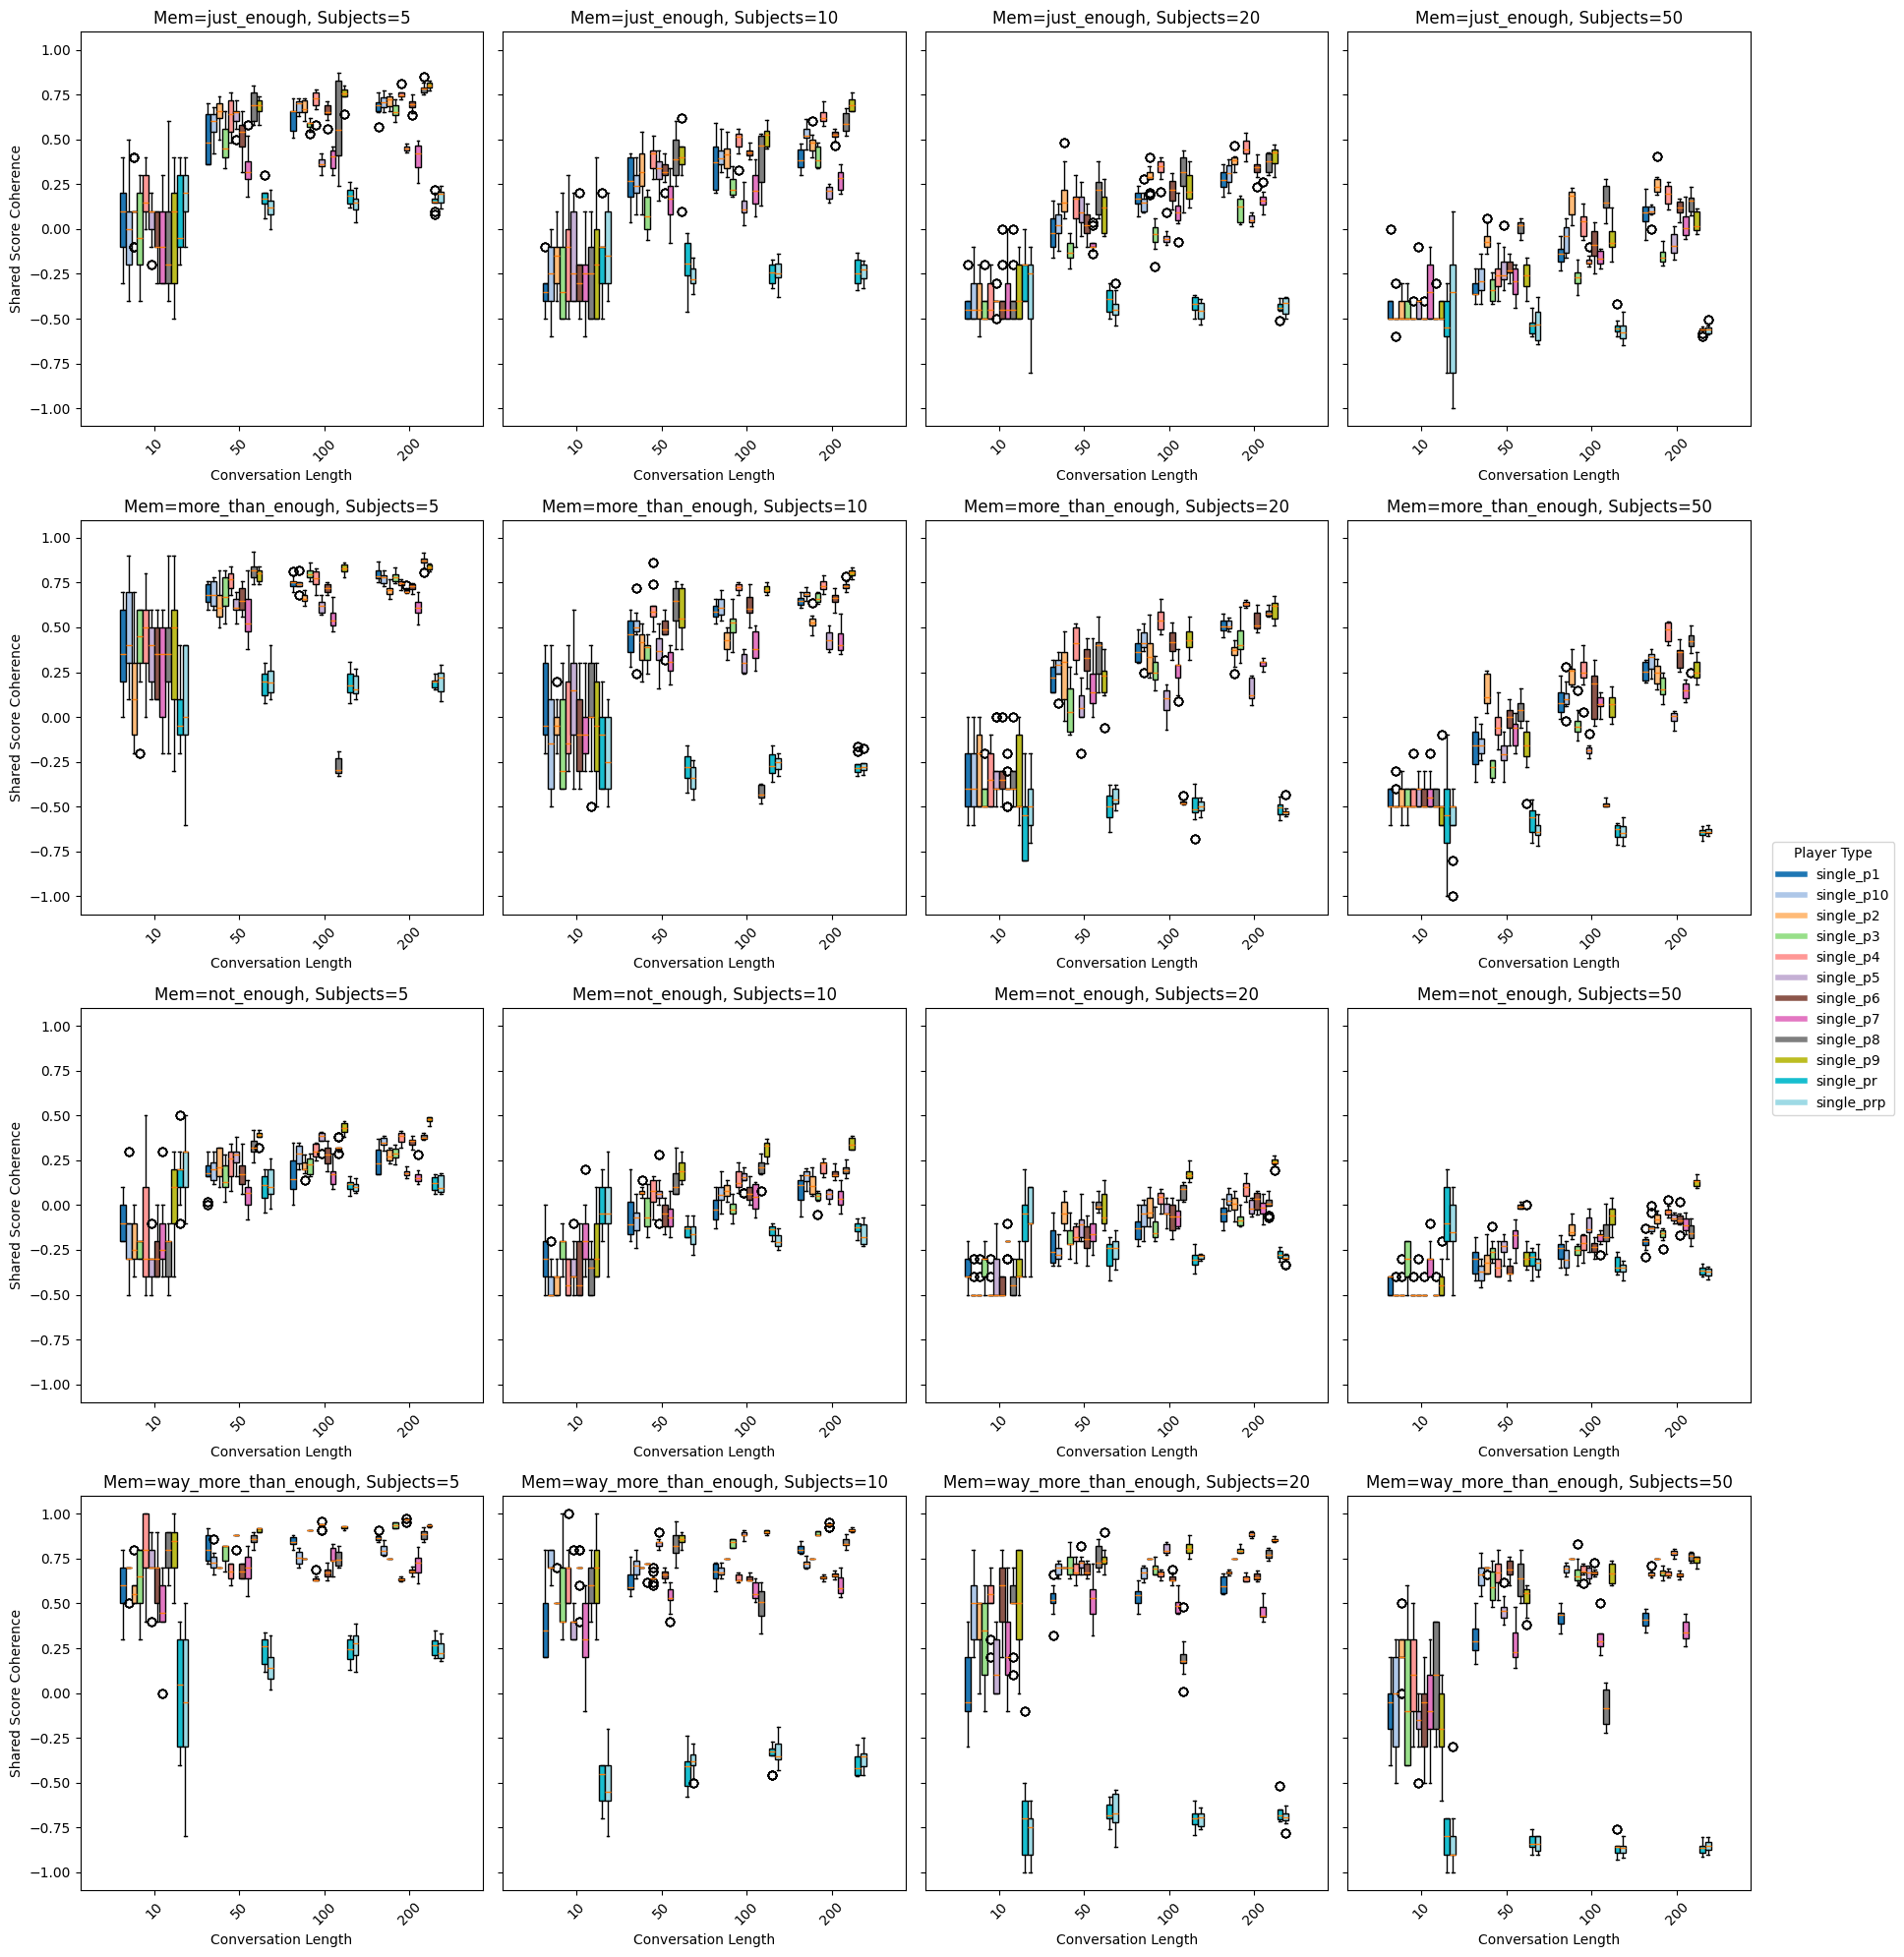

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Filter for num_players = 2
subset = df[
    (df["player_selection_type"].str.startswith("single_p")) &
    (df["num_players"] == 5)
]

memory_vals = sorted(subset["memory_size_key"].unique())
subject_vals = sorted(subset["num_subjects"].unique())  # assuming this column exists
player_types = sorted(subset["player_selection_type"].unique())

# Assign unique colors to players
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: rows = memory_size_key, cols = num_subjects
fig, axes = plt.subplots(
    len(memory_vals), len(subject_vals),
    figsize=(5 * len(subject_vals), 5 * len(memory_vals)),
    sharey=True
)

if len(memory_vals) == 1:
    axes = np.array([axes])
if len(subject_vals) == 1:
    axes = axes[:, np.newaxis]

for r, mem in enumerate(memory_vals):
    for c, subj in enumerate(subject_vals):
        ax = axes[r, c]
        data = subset[
            (subset["memory_size_key"] == mem) &
            (subset["num_subjects"] == subj)
        ]

        conv_lens = sorted(data["conversation_length"].unique())
        n_conv = len(conv_lens)
        n_players = len(player_types)

        # spacing for players
        group_width = 0.8
        box_width = group_width / n_players
        offsets = np.linspace(
            -group_width/2 + box_width/2,
            group_width/2 - box_width/2,
            n_players
        )

        for j, ptype in enumerate(player_types):
            box_data = []
            for conv in conv_lens:
                vals = data.loc[
                    (data["conversation_length"] == conv) &
                    (data["player_selection_type"] == ptype),
                    "shared_score_coherence"
                ] / conv
                box_data.append(vals.dropna().values)

            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_title(f"Mem={mem}, Subjects={subj}")
        # ax.set_ylim(-50, 200)
        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        if c == 0:
            ax.set_ylabel("Shared Score Coherence")

# Legend outside
legend_handles = [plt.Line2D([0], [0], color=color_map[p], lw=4) for p in player_types]
fig.legend(
    legend_handles, player_types,
    title="Player Type",
    loc="center left",
    bbox_to_anchor=(0.9, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for legend
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/986678780.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_types))


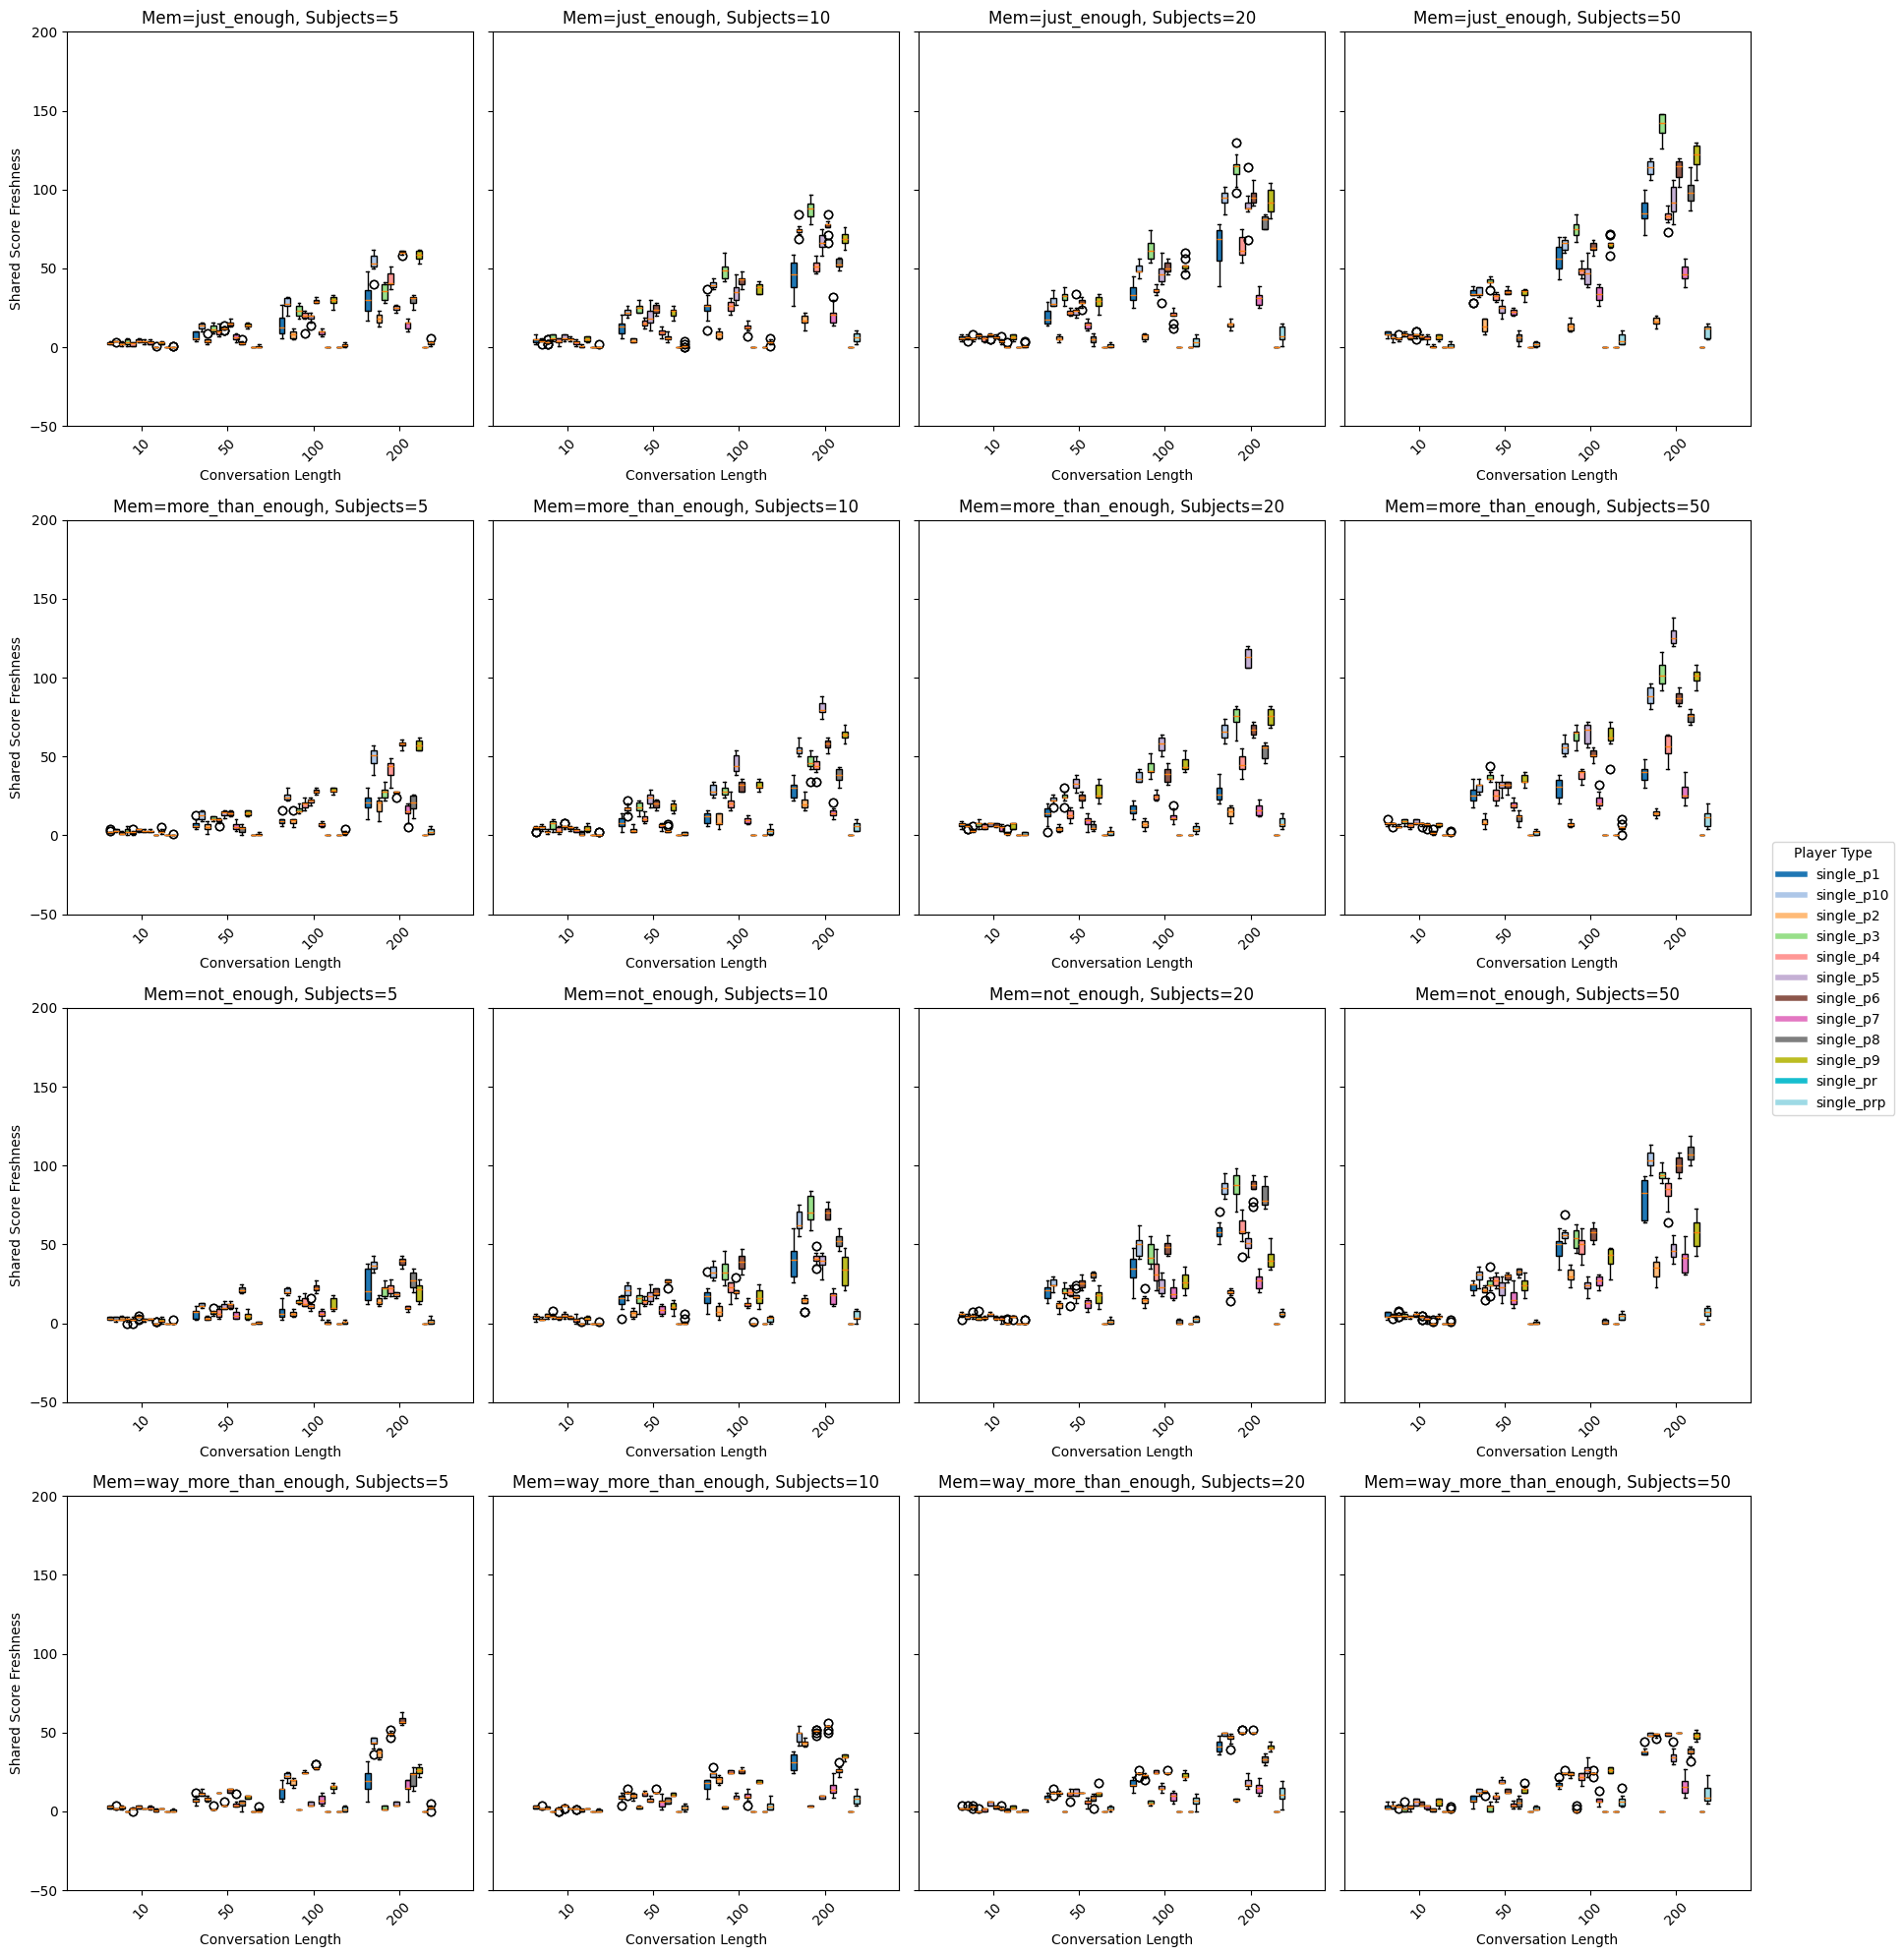

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Filter for num_players = 2
subset = df[
    (df["player_selection_type"].str.startswith("single_p")) &
    (df["num_players"] == 2)
]

memory_vals = sorted(subset["memory_size_key"].unique())
subject_vals = sorted(subset["num_subjects"].unique())  # assuming this column exists
player_types = sorted(subset["player_selection_type"].unique())

# Assign unique colors to players
colors = cm.get_cmap("tab20", len(player_types))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_types)}

# Subplot grid: rows = memory_size_key, cols = num_subjects
fig, axes = plt.subplots(
    len(memory_vals), len(subject_vals),
    figsize=(5 * len(subject_vals), 5 * len(memory_vals)),
    sharey=True
)

if len(memory_vals) == 1:
    axes = np.array([axes])
if len(subject_vals) == 1:
    axes = axes[:, np.newaxis]

for r, mem in enumerate(memory_vals):
    for c, subj in enumerate(subject_vals):
        ax = axes[r, c]
        data = subset[
            (subset["memory_size_key"] == mem) &
            (subset["num_subjects"] == subj)
        ]

        conv_lens = sorted(data["conversation_length"].unique())
        n_conv = len(conv_lens)
        n_players = len(player_types)

        # spacing for players
        group_width = 0.8
        box_width = group_width / n_players
        offsets = np.linspace(
            -group_width/2 + box_width/2,
            group_width/2 - box_width/2,
            n_players
        )

        for j, ptype in enumerate(player_types):
            box_data = []
            for conv in conv_lens:
                vals = data.loc[
                    (data["conversation_length"] == conv) &
                    (data["player_selection_type"] == ptype),
                    "shared_score_freshness"
                ]
                box_data.append(vals.dropna().values)

            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_title(f"Mem={mem}, Subjects={subj}")
        ax.set_ylim(-50, 200)
        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        if c == 0:
            ax.set_ylabel("Shared Score Freshness")

# Legend outside
legend_handles = [plt.Line2D([0], [0], color=color_map[p], lw=4) for p in player_types]
fig.legend(
    legend_handles, player_types,
    title="Player Type",
    loc="center left",
    bbox_to_anchor=(0.9, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for legend
plt.show()


## 9 omit p2

In [ ]:
df[df.player_selection_type == '11_plus_random'].groupby(['conversation_length'])[['player_score_shared', 'shared_score_coherence']].describe()

player_score_shared                                        \
                                  count        mean        std    min     25%   
conversation_length                                                             
10                               1760.0    2.239250   5.671989  -6.89  -2.350   
50                               1760.0   27.167875  27.388060 -26.02   1.240   
100                              1760.0   71.563937  52.542765 -45.96  14.750   
200                              1760.0  159.587187  94.548141 -39.78  64.195   

                                               shared_score_coherence  \
                         50%       75%     max                  count   
conversation_length                                                     
10                     1.030    6.0050   16.03                 1760.0   
50                    28.750   52.6375   72.21                 1760.0   
100                   92.375  119.1775  141.10                 1760.0   
200                  194.925  240.1700  284.36                 1760.0   

                                                                            
                         mean        std   min    25%    50%    75%    max  
conversation_length                                                         
10                    0.66875   3.311382  -6.0  -2.00    0.0    3.0   10.0  
50                   14.58750  16.239756 -13.0  -1.00   17.0   29.0   42.0  
100                  42.52500  29.818905 -19.0  15.00   49.5   68.0   86.0  
200                  98.61250  49.752576 -19.0  58.75  117.5  140.0  172.0

In [ ]:
df[df.player_selection_type == '10_unique'].groupby(['conversation_length'])[['player_score_shared', 'shared_score_coherence']].describe()

player_score_shared                                \
                                  count        mean        std    min   
conversation_length                                                     
10                               1600.0    6.243625   3.707793  -0.43   
50                               1600.0   45.480125  20.137071   5.28   
100                              1600.0   98.788937  37.680049  25.74   
200                              1600.0  198.037813  72.718083  49.91   

                                                          \
                          25%      50%       75%     max   
conversation_length                                        
10                     3.1650    5.355    8.5100   16.38   
50                    28.3475   48.745   62.5150   74.46   
100                   76.2900  112.725  128.4575  144.47   
200                  152.2550  229.815  254.9675  288.00   

                    shared_score_coherence                                    \
                                     count       mean        std   min   25%   
conversation_length                                                            
10                                  1600.0   -0.80000   4.354234  -6.0  -5.0   
50                                  1600.0   15.21875  19.685988 -18.0  -4.0   
100                                 1600.0   43.38125  32.694479 -30.0  19.0   
200                                 1600.0  101.76250  56.997799 -32.0  63.0   

                                          
                       50%    75%    max  
conversation_length                       
10                    -1.5    2.0   10.0  
50                    15.0   34.0   47.0  
100                   52.0   74.0   90.0  
200                  120.0  150.0  180.0

In [ ]:
df[df.player_selection_type == '9_omit_p2'].groupby(['conversation_length'])[['player_score_shared', 'shared_score_coherence']].describe()

player_score_shared                                \
                                  count        mean        std    min   
conversation_length                                                     
10                               1440.0    5.983188   3.545524  -0.54   
50                               1440.0   44.488250  21.077576   7.68   
100                              1440.0   98.143687  39.906244  15.25   
200                              1440.0  198.513625  72.794446  46.50   

                                                      shared_score_coherence  \
                         25%      50%     75%     max                  count   
conversation_length                                                            
10                     3.295    5.030    7.75   16.29                 1440.0   
50                    23.370   50.370   62.23   75.84                 1440.0   
100                   73.830  113.110  129.92  145.24                 1440.0   
200                  154.520  225.395  256.21  284.07                 1440.0   

                                                                             
                         mean        std   min    25%    50%     75%    max  
conversation_length                                                          
10                    -1.2500   4.387581  -6.0  -5.00   -2.0    2.00   10.0  
50                    14.5375  19.577468 -20.0  -4.50   14.5   33.00   47.0  
100                   41.9250  34.283350 -29.0  11.75   48.5   74.00   90.0  
200                  101.2500  57.990282 -36.0  58.75  118.0  151.25  183.0

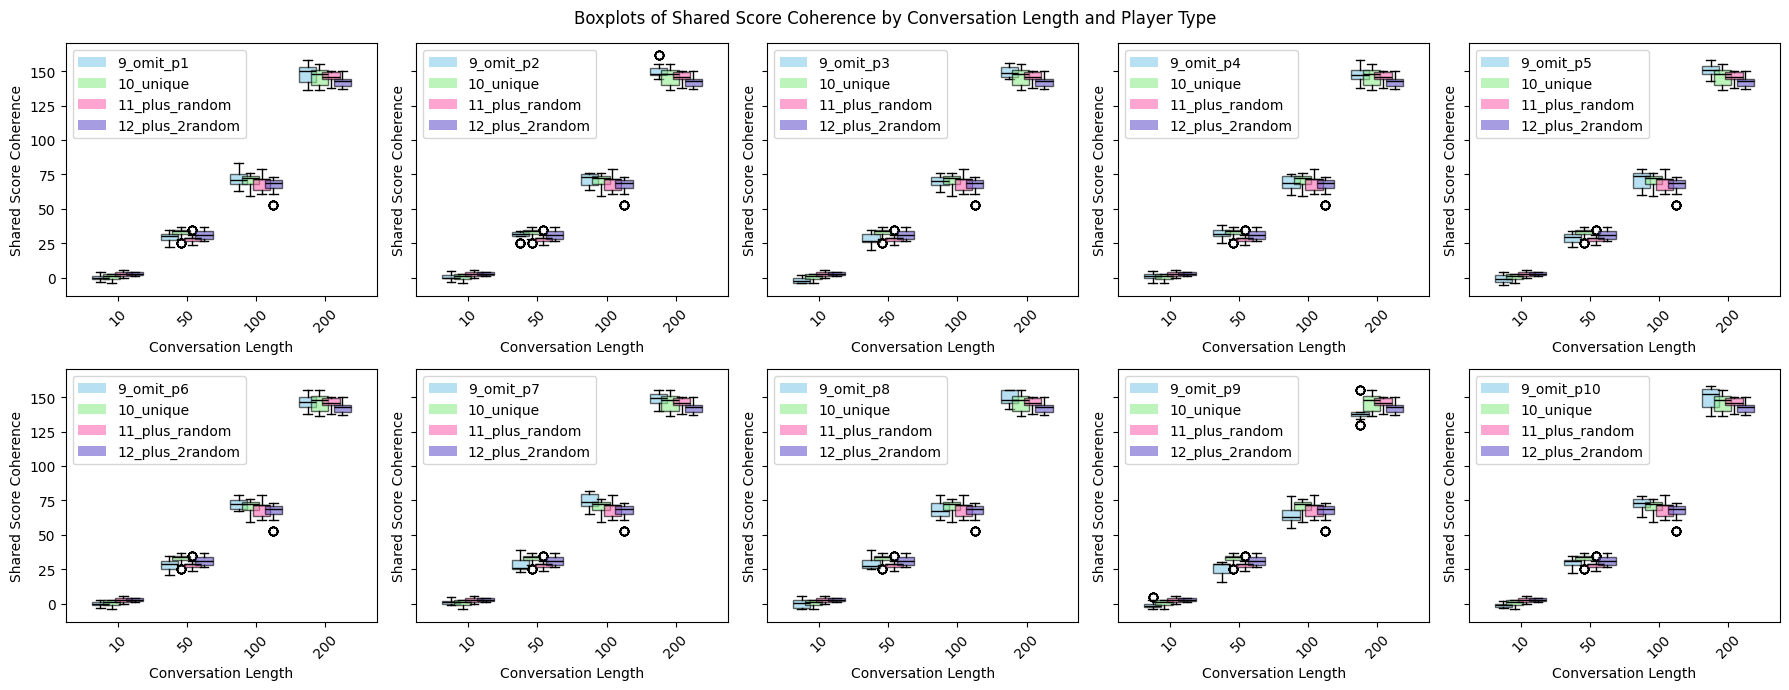

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

subset = df[(df["memory_size_key"] == "just_enough") & (df["num_subjects"] == 5)]

# Get sorted conversation lengths
conv_lens = sorted(subset["conversation_length"].unique())
n_conv = len(conv_lens)

fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(18, 7), sharey=True)

axes = axes.flatten()
for i, ax in enumerate(axes):
    # Define the three groups you want to compare
    groups = {
        f"9_omit_p{i+1}": subset[subset["player_selection_type"].str.startswith(f"9_omit_p{i+1}")],
        "10_unique": subset[subset["player_selection_type"] == "10_unique"],
        "11_plus_random": subset[subset["player_selection_type"] == "11_plus_random"],
        "12_plus_2random": subset[subset["player_selection_type"] == "12_plus_2random"],
    }

    # Width of each box
    box_width = 0.25
    # Offset to separate groups visually
    offsets = np.linspace(-box_width, box_width, len(groups))

    # Colors for each group
    colors = ["skyblue", "lightgreen", "hotpink", "slateblue"]

    for j, (label, subset2) in enumerate(groups.items()):
        box_data = []
        for conv_len in conv_lens:
            vals = subset2.loc[
                subset2["conversation_length"] == conv_len,
                "shared_score_coherence"
            ]
            box_data.append(vals.values)

        # Positions for this group
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            boxprops=dict(facecolor=colors[j], alpha=0.6),
            medianprops=dict(color="black"),
        )

    # Formatting axes
    ax.set_xticks(np.arange(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Shared Score Coherence")
    ax.legend([plt.Rectangle((0,0),1,1,facecolor=c,alpha=0.6) for c in colors],
            list(groups.keys()), loc="best")

plt.suptitle("Boxplots of Shared Score Coherence by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


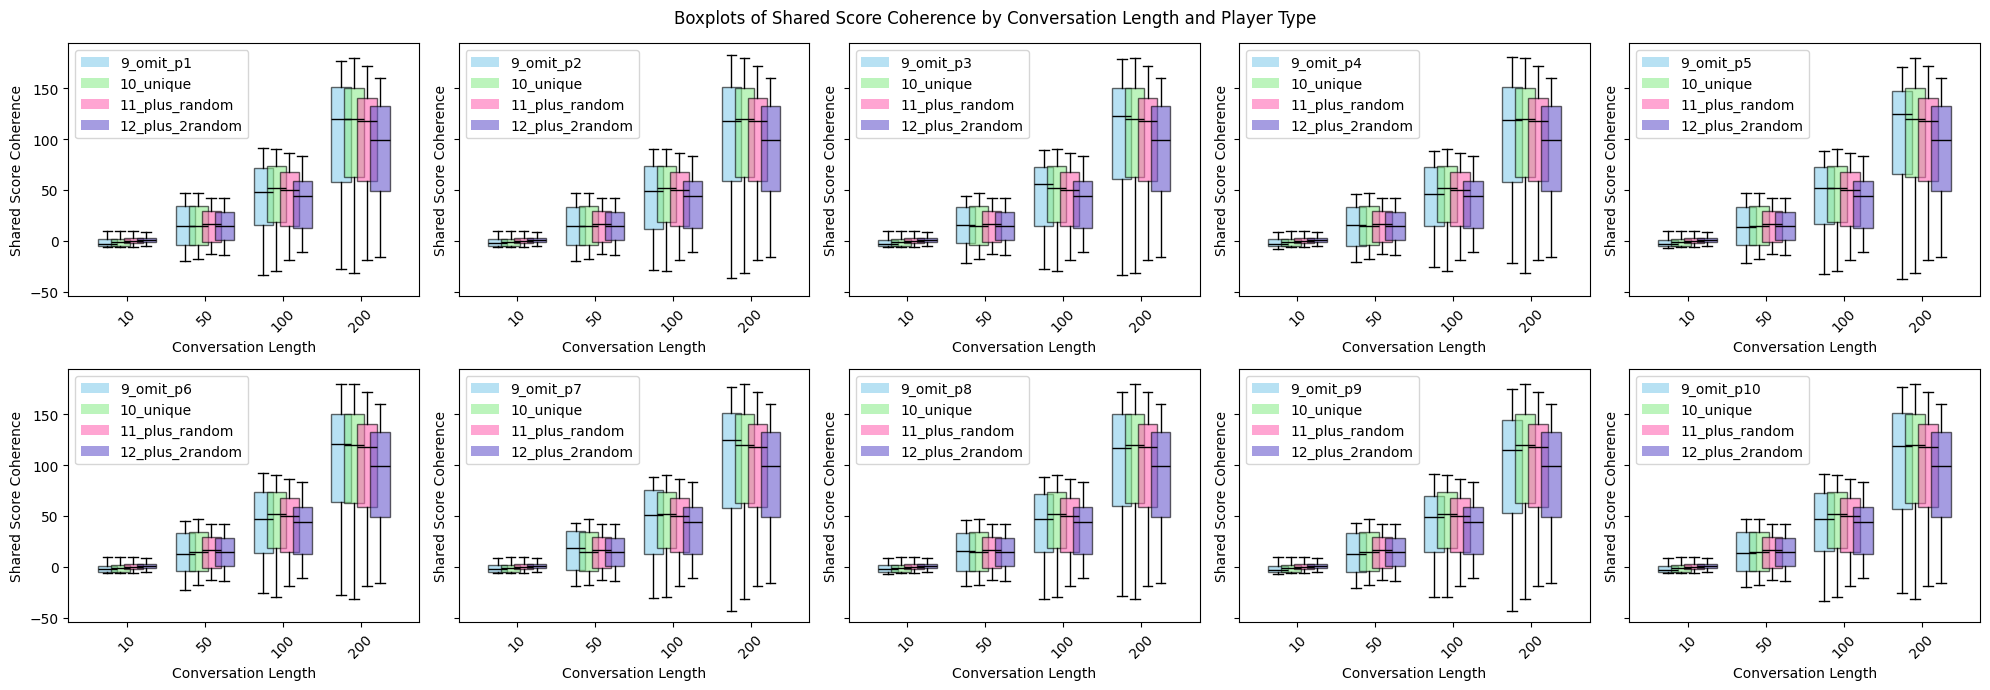

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get sorted conversation lengths
conv_lens = sorted(df["conversation_length"].unique())
n_conv = len(conv_lens)

fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(20, 7), sharey=True)

axes = axes.flatten()
for i, ax in enumerate(axes):
    # Define the three groups you want to compare
    groups = {
        f"9_omit_p{i+1}": df[df["player_selection_type"].str.startswith(f"9_omit_p{i+1}")],
        "10_unique": df[df["player_selection_type"] == "10_unique"],
        "11_plus_random": df[df["player_selection_type"] == "11_plus_random"],
        "12_plus_2random": df[df["player_selection_type"] == "12_plus_2random"],
    }

    # Width of each box
    box_width = 0.25
    # Offset to separate groups visually
    offsets = np.linspace(-box_width, box_width, len(groups))

    # Colors for each group
    colors = ["skyblue", "lightgreen", "hotpink", "slateblue"]

    for j, (label, subset) in enumerate(groups.items()):
        box_data = []
        for conv_len in conv_lens:
            vals = subset.loc[
                subset["conversation_length"] == conv_len,
                "shared_score_coherence"
            ]
            box_data.append(vals.values)

        # Positions for this group
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            boxprops=dict(facecolor=colors[j], alpha=0.6),
            medianprops=dict(color="black"),
        )

    # Formatting axes
    ax.set_xticks(np.arange(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Shared Score Coherence")
    ax.legend([plt.Rectangle((0,0),1,1,facecolor=c,alpha=0.6) for c in colors],
            list(groups.keys()), loc="best")

plt.suptitle("Boxplots of Shared Score Coherence by Conversation Length and Player Type")
plt.tight_layout()
plt.show()


In [ ]:
df[df.player_selection_type == '1v1']

,simulation_id,run_number,player_selection_type,num_players,player_list,conversation_length,num_subjects,memory_size_key,memory_size,shared_score_total,shared_score_importance,shared_score_coherence,shared_score_freshness,shared_score_nonmonotonousness,player_id,player_name,player_score_total,player_score_shared,player_score_individual
0,06af8a97-3a08-437e-9cd5-f9b822c26922,3,1v1,2,"p6,p9",10,20,just_enough,5,5.71,3.71,-3.0,5.0,0.0,e8032e50-a0e2-4fc2-ac3d-6b82be89dd55,Player6,1.0235,5.71,4.525
1,06af8a97-3a08-437e-9cd5-f9b822c26922,3,1v1,2,"p6,p9",10,20,just_enough,5,5.71,3.71,-3.0,5.0,0.0,ecc78607-148b-4fa6-8e17-9313da7a3828,Player9,1.0610,5.71,4.900
96,233aa32f-8dfe-4bb0-8f4a-1d3dd0a3d2d4,3,1v1,2,"p3,p9",10,5,not_enough,2,0.80,0.80,-2.0,2.0,0.0,88a8289b-1406-4257-806b-5157597c0b74,Player3,0.4000,0.80,3.200
97,233aa32f-8dfe-4bb0-8f4a-1d3dd0a3d2d4,3,1v1,2,"p3,p9",10,5,not_enough,2,0.80,0.80,-2.0,2.0,0.0,dd5e653b-e512-478f-b581-2caa212c4598,Player9,0.3000,0.80,2.200
152,d0b00920-50c3-4ad3-b15a-bc9dc69b6269,8,1v1,2,"p2,p10",50,50,more_than_enough,37,41.79,21.79,6.0,14.0,0.0,f89711ea-b23f-46c0-bc52-82b934e4bf38,Player2,1.2336,41.79,19.890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716121,5ace9bc7-5439-4ab9-ac61-e2f2abe8167f,7,1v1,2,"p3,p7",200,20,way_more_than_enough,1000,254.05,154.05,117.0,2.0,-19.0,a5d7987a-e2ba-4094-afc8-6ce90f8f7969,Player7,1.7230,254.05,90.550
716122,5a38efff-fbf9-4b8e-ac52-f2a09002f7ef,4,1v1,2,"p1,p3",200,5,way_more_than_enough,1000,187.78,149.78,191.0,0.0,-153.0,b99da5dd-4dbb-4c6c-b2ed-190560f00727,Player1,1.7209,187.78,156.400
716123,5a38efff-fbf9-4b8e-ac52-f2a09002f7ef,4,1v1,2,"p1,p3",200,5,way_more_than_enough,1000,187.78,149.78,191.0,0.0,-153.0,a406c942-9d0e-46c4-b7d2-aec43bcd580f,Player3,1.7254,187.78,157.300
716124,134d279f-a891-4ef3-b8f1-151eee96c15c,7,1v1,2,"p3,p4",200,5,way_more_than_enough,1000,176.92,149.92,185.0,2.0,-160.0,6bd14286-85ac-4510-a45e-b447ce159b52,Player3,1.6746,176.92,158.000


## 1v1

In [ ]:
df[(df.player_selection_type == '1v1') & (df.player_list.str.contains('p2')) & (df.player_name == 'Player2')].groupby(['conversation_length', 'player_list'])[['player_score_total', 'shared_score_coherence']].describe()

player_score_total                      \
                                             count      mean       std   
conversation_length player_list                                          
10                  p1,p2                    160.0  1.134678  0.532109   
                    p2,p10                   160.0  1.085106  0.546445   
                    p2,p3                    160.0  1.077769  0.498526   
                    p2,p4                    160.0  1.056656  0.583587   
                    p2,p5                    160.0  1.101581  0.487514   
                    p2,p6                    160.0  1.028394  0.528163   
                    p2,p7                    160.0  1.029075  0.508402   
                    p2,p8                    160.0  1.038997  0.581848   
                    p2,p9                    160.0  1.081878  0.537505   
50                  p1,p2                    160.0  1.430939  0.525276   
                    p2,p10                   160.0  1.456298  0.514245   
                    p2,p3                    160.0  1.373354  0.459750   
                    p2,p4                    160.0  1.460916  0.510500   
                    p2,p5                    160.0  1.216389  0.480285   
                    p2,p6                    160.0  1.429922  0.474879   
                    p2,p7                    160.0  1.286184  0.473009   
                    p2,p8                    160.0  1.401230  0.564558   
                    p2,p9                    160.0  1.468065  0.493827   
100                 p1,p2                    160.0  1.524888  0.523891   
                    p2,p10                   160.0  1.552561  0.477796   
                    p2,p3                    160.0  1.419964  0.404975   
                    p2,p4                    160.0  1.531306  0.480335   
                    p2,p5                    160.0  1.218882  0.481873   
                    p2,p6                    160.0  1.513240  0.437194   
                    p2,p7                    160.0  1.358107  0.466666   
                    p2,p8                    160.0  1.481679  0.510091   
                    p2,p9                    160.0  1.534660  0.460767   
200                 p1,p2                    160.0  1.588308  0.513672   
                    p2,p10                   160.0  1.622001  0.465358   
                    p2,p3                    160.0  1.441337  0.380594   
                    p2,p4                    160.0  1.603142  0.466669   
                    p2,p5                    160.0  1.247669  0.450499   
                    p2,p6                    160.0  1.570207  0.419441   
                    p2,p7                    160.0  1.392178  0.471535   
                    p2,p8                    160.0  1.625321  0.479771   
                    p2,p9                    160.0  1.571560  0.441235   

                                                                         \
                                      min       25%       50%       75%   
conversation_length player_list                                           
10                  p1,p2        0.317000  0.719750  1.051750  1.534000   
                    p2,p10       0.066000  0.616750  0.981500  1.527000   
                    p2,p3        0.227000  0.653125  1.005500  1.472000   
                    p2,p4        0.117000  0.534500  0.966500  1.548000   
                    p2,p5        0.281000  0.723750  1.040500  1.494000   
                    p2,p6        0.141000  0.559250  0.944500  1.500875   
                    p2,p7        0.197000  0.615375  0.921000  1.484500   
                    p2,p8        0.148000  0.535875  0.954500  1.489000   
                    p2,p9        0.205000  0.606000  0.982000  1.581125   
50                  p1,p2        0.540200  0.968850  1.482600  1.855550   
                    p2,p10       0.520700  0.953400  1.583700  1.883925   
                    p2,p3        0.483200  0.919650  1.544500  1.740050   
                    

In [ ]:
df[(df.player_selection_type == '1v1') & (df.player_list.str.contains('p2'))]

,simulation_id,run_number,player_selection_type,num_players,player_list,conversation_length,num_subjects,memory_size_key,memory_size,shared_score_total,shared_score_importance,shared_score_coherence,shared_score_freshness,shared_score_nonmonotonousness,player_id,player_name,player_score_total,player_score_shared,player_score_individual
152,d0b00920-50c3-4ad3-b15a-bc9dc69b6269,8,1v1,2,"p2,p10",50,50,more_than_enough,37,41.79,21.79,6.0,14.0,0.0,f89711ea-b23f-46c0-bc52-82b934e4bf38,Player2,1.23360,41.79,19.89
153,d0b00920-50c3-4ad3-b15a-bc9dc69b6269,8,1v1,2,"p2,p10",50,50,more_than_enough,37,41.79,21.79,6.0,14.0,0.0,ac443d60-ae5e-4d59-9c1b-83609c57ff4b,Player10Agent,1.25900,41.79,21.16
167,f6806618-e7c2-4f8f-b921-6153e41f4607,2,1v1,2,"p2,p10",100,10,not_enough,25,45.35,24.35,13.0,9.0,-1.0,ba687550-4414-4bbc-9401-35441ad6c70c,Player2,0.71650,45.35,26.30
168,f6806618-e7c2-4f8f-b921-6153e41f4607,2,1v1,2,"p2,p10",100,10,not_enough,25,45.35,24.35,13.0,9.0,-1.0,38b6d53f-cd23-4d6e-8f86-8797b627dba2,Player10Agent,0.71450,45.35,26.10
275,59ea5ba3-bc9d-4721-ab82-ca1e95e27bee,7,1v1,2,"p2,p10",50,10,just_enough,25,58.66,22.66,29.0,7.0,0.0,3b7a3734-16db-4f11-9151-2168cb46f11a,Player2,1.66120,58.66,24.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715725,b43ee1b9-e3c9-45d4-9d33-7355227ffbaf,2,1v1,2,"p2,p10",100,10,way_more_than_enough,500,159.09,72.09,70.0,23.0,-6.0,5d12ce4e-3705-442e-8cea-d723732fb904,Player10Agent,1.98140,159.09,39.05
715905,85497e42-45ea-48cf-ab1b-32189220911a,3,1v1,2,"p2,p8",200,5,more_than_enough,150,301.31,115.31,161.0,28.0,-3.0,8835639a-61be-41de-b1f6-9b20c12fbd89,Player2,2.02905,301.31,104.50
715906,85497e42-45ea-48cf-ab1b-32189220911a,3,1v1,2,"p2,p8",200,5,more_than_enough,150,301.31,115.31,161.0,28.0,-3.0,6dba0981-2679-4daa-a087-b22c7514b5c4,Player8,2.00605,301.31,99.90
716080,4a7c7c9a-eb23-4395-9b1b-c78717ac0f50,7,1v1,2,"p2,p3",100,10,more_than_enough,75,131.76,55.76,67.0,12.0,-3.0,e27da05f-992e-43ed-ab02-a8157a73f1a1,Player2,1.83060,131.76,51.30


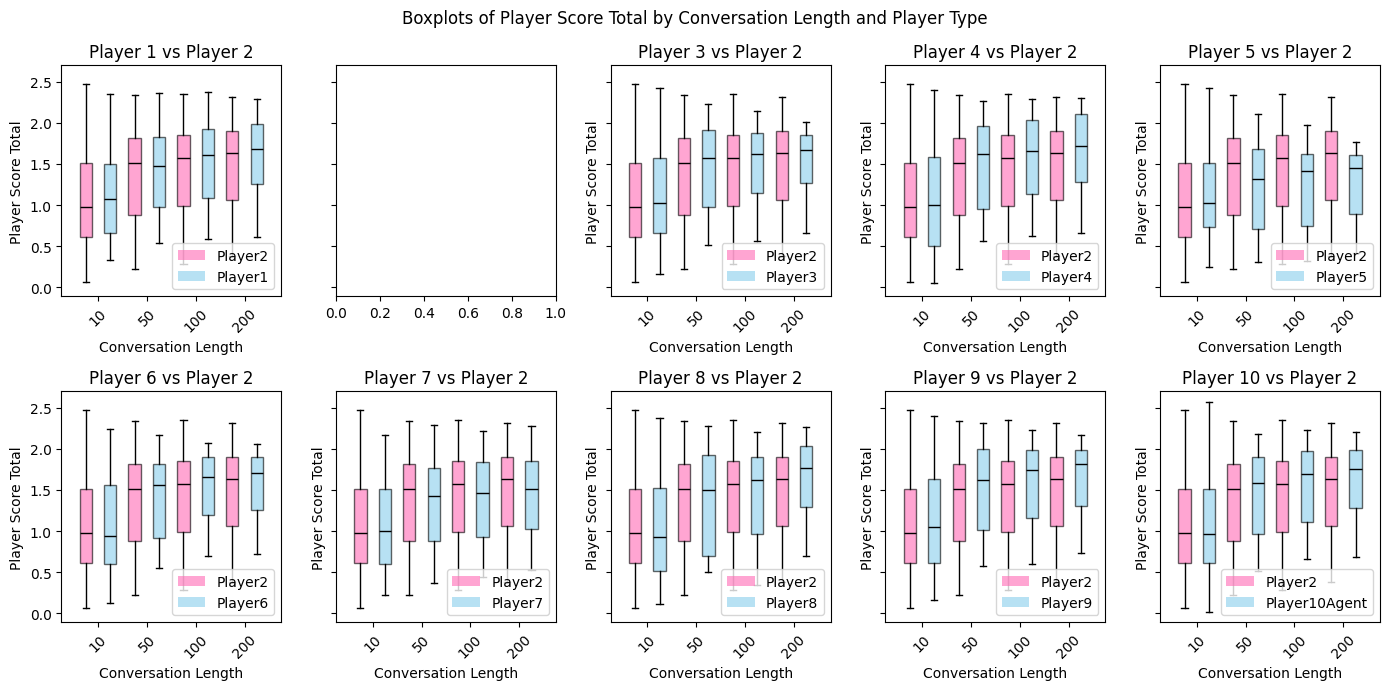

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get sorted conversation lengths
conv_lens = sorted(df["conversation_length"].unique())
n_conv = len(conv_lens)

fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(14, 7), sharey=True)

subset = df[(df.player_selection_type == '1v1') & (df.player_list.str.contains('p2'))]

axes = axes.flatten()
for i, ax in enumerate(axes):
    if i+1 == 2:
        continue
    # Define the three groups you want to compare
    if i+1 != 10:
        groups = {
            "Player2": subset[(subset.player_name == 'Player2')],
            f"Player{i+1}": subset[(subset.player_name == f'Player{i+1}')]
        }
    else:
        groups = {
            "Player2": subset[(subset.player_name == 'Player2')],
            f"Player10Agent": subset[(subset.player_name == f'Player10Agent')]
        }

    # Width of each box
    box_width = 0.25
    # Offset to separate groups visually
    offsets = np.linspace(-box_width, box_width, len(groups))

    # Colors for each group
    colors = ["hotpink", "skyblue"]

    for j, (label, subset2) in enumerate(groups.items()):
        box_data = []
        for conv_len in conv_lens:
            vals = subset2.loc[
                subset2["conversation_length"] == conv_len,
                "player_score_total"
            ]
            box_data.append(vals.values)

        # Positions for this group
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            boxprops=dict(facecolor=colors[j], alpha=0.6),
            medianprops=dict(color="black"),
        )

    # Formatting axes
    ax.set_title(f"Player {i+1} vs Player 2")
    ax.set_xticks(np.arange(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Player Score Total")
    ax.legend([plt.Rectangle((0,0),1,1,facecolor=c,alpha=0.6) for c in colors],
            list(groups.keys()), loc="lower right")

plt.suptitle("Boxplots of Player Score Total by Conversation Length and Player Type")
plt.tight_layout()
plt.show()

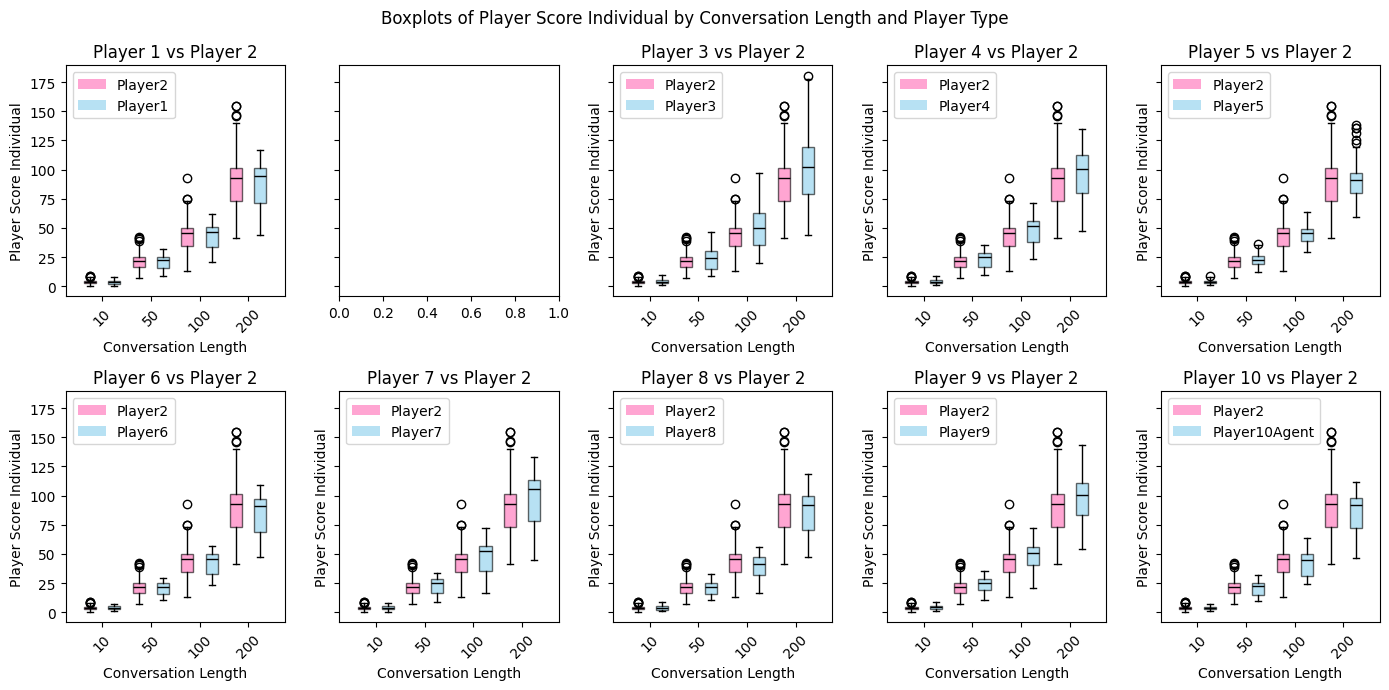

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get sorted conversation lengths
conv_lens = sorted(df["conversation_length"].unique())
n_conv = len(conv_lens)

fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(14, 7), sharey=True)

subset = df[(df.player_selection_type == '1v1') & (df.player_list.str.contains('p2'))]

axes = axes.flatten()
for i, ax in enumerate(axes):
    if i+1 == 2:
        continue
    # Define the three groups you want to compare
    if i+1 != 10:
        groups = {
            "Player2": subset[(subset.player_name == 'Player2')],
            f"Player{i+1}": subset[(subset.player_name == f'Player{i+1}')]
        }
    else:
        groups = {
            "Player2": subset[(subset.player_name == 'Player2')],
            f"Player10Agent": subset[(subset.player_name == f'Player10Agent')]
        }

    # Width of each box
    box_width = 0.25
    # Offset to separate groups visually
    offsets = np.linspace(-box_width, box_width, len(groups))

    # Colors for each group
    colors = ["hotpink", "skyblue"]

    for j, (label, subset2) in enumerate(groups.items()):
        box_data = []
        for conv_len in conv_lens:
            vals = subset2.loc[
                subset2["conversation_length"] == conv_len,
                "player_score_individual"
            ]
            box_data.append(vals.values)

        # Positions for this group
        positions = np.arange(len(conv_lens)) + offsets[j]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            boxprops=dict(facecolor=colors[j], alpha=0.6),
            medianprops=dict(color="black"),
        )

    # Formatting axes
    ax.set_title(f"Player {i+1} vs Player 2")
    ax.set_xticks(np.arange(len(conv_lens)))
    ax.set_xticklabels(conv_lens, rotation=45)
    ax.set_xlabel("Conversation Length")
    ax.set_ylabel("Player Score Individual")
    ax.legend([plt.Rectangle((0,0),1,1,facecolor=c,alpha=0.6) for c in colors],
            list(groups.keys()), loc="upper left")

plt.suptitle("Boxplots of Player Score Individual by Conversation Length and Player Type")
plt.tight_layout()
plt.show()

### Memory size

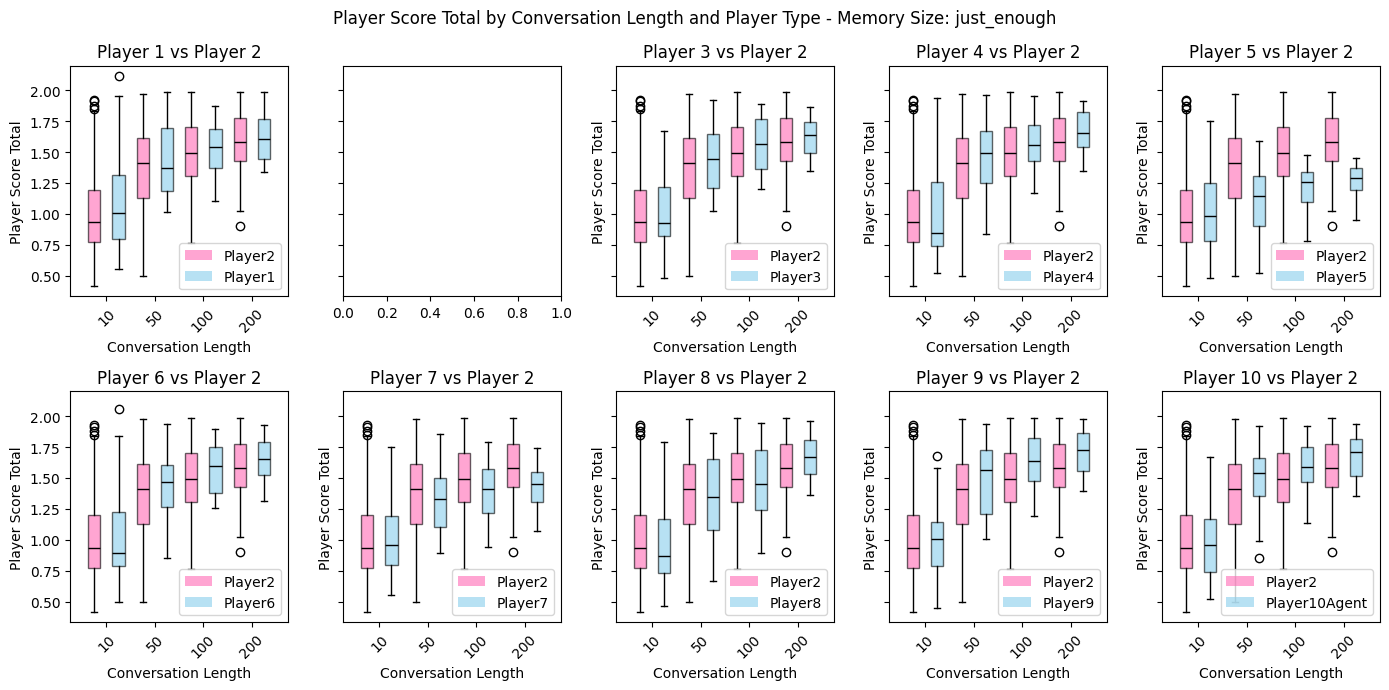

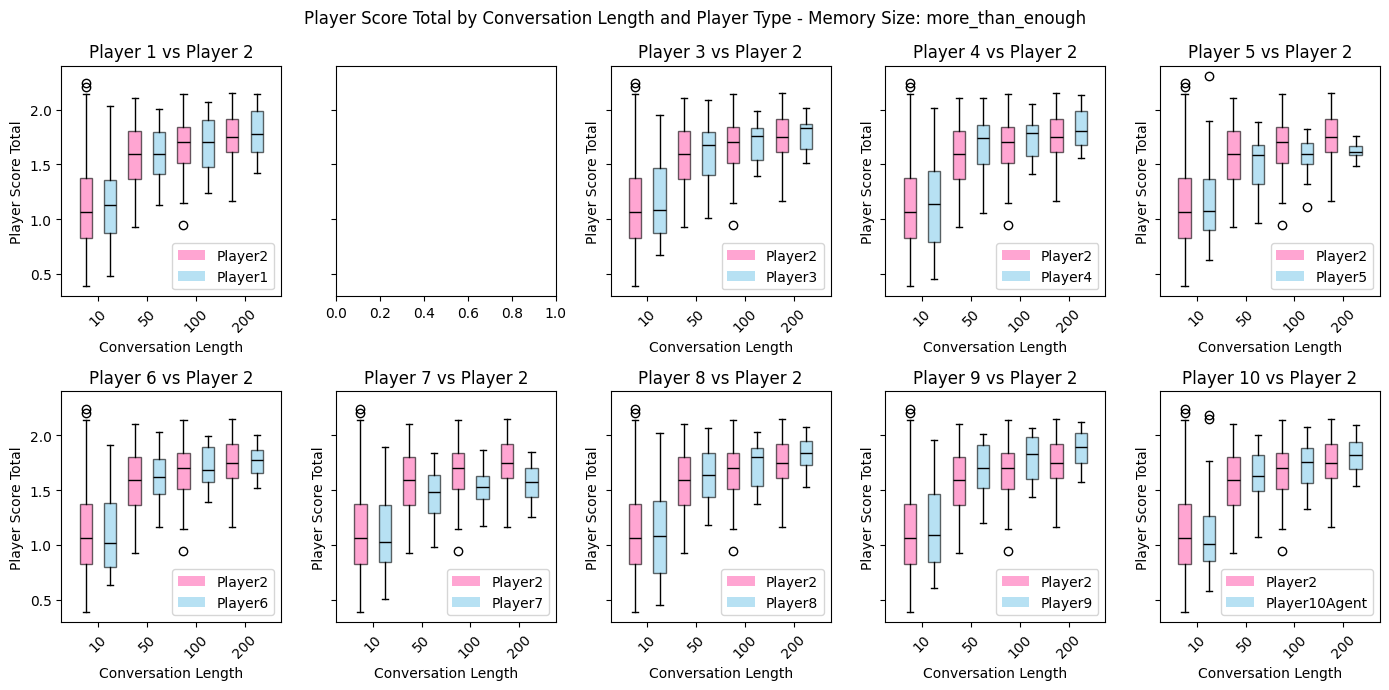

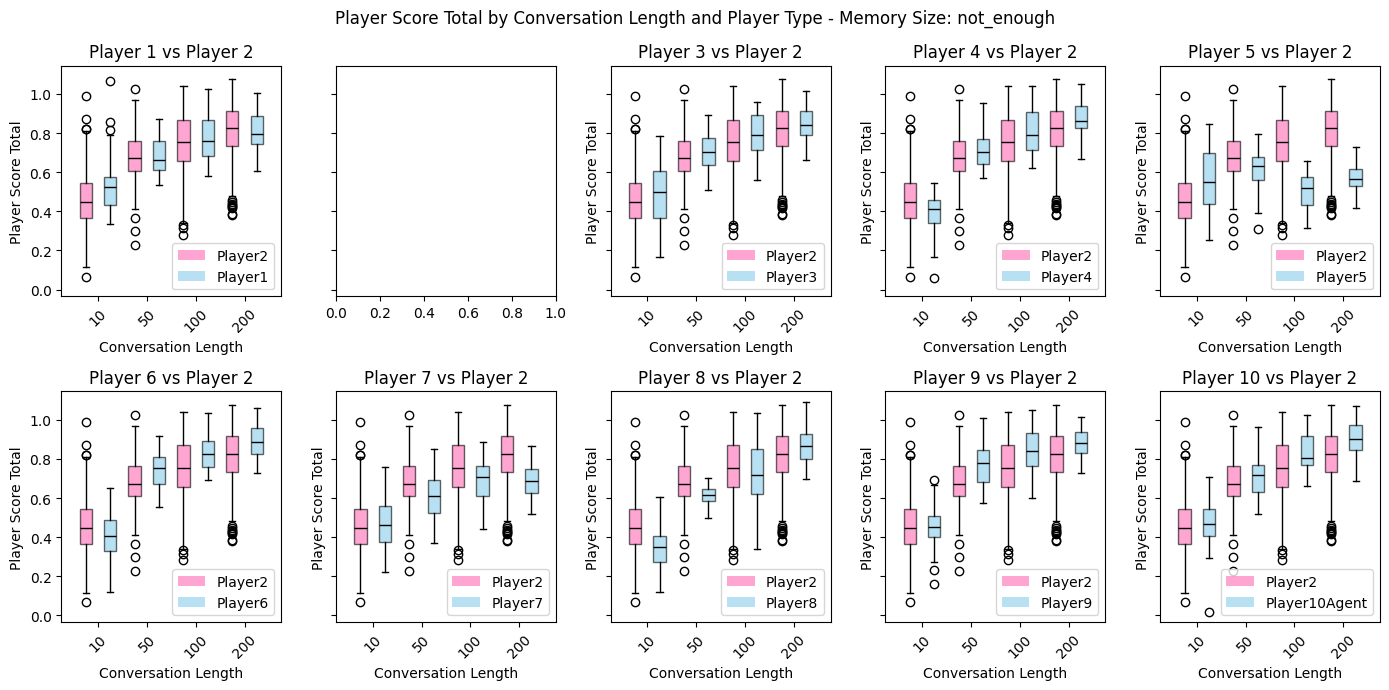

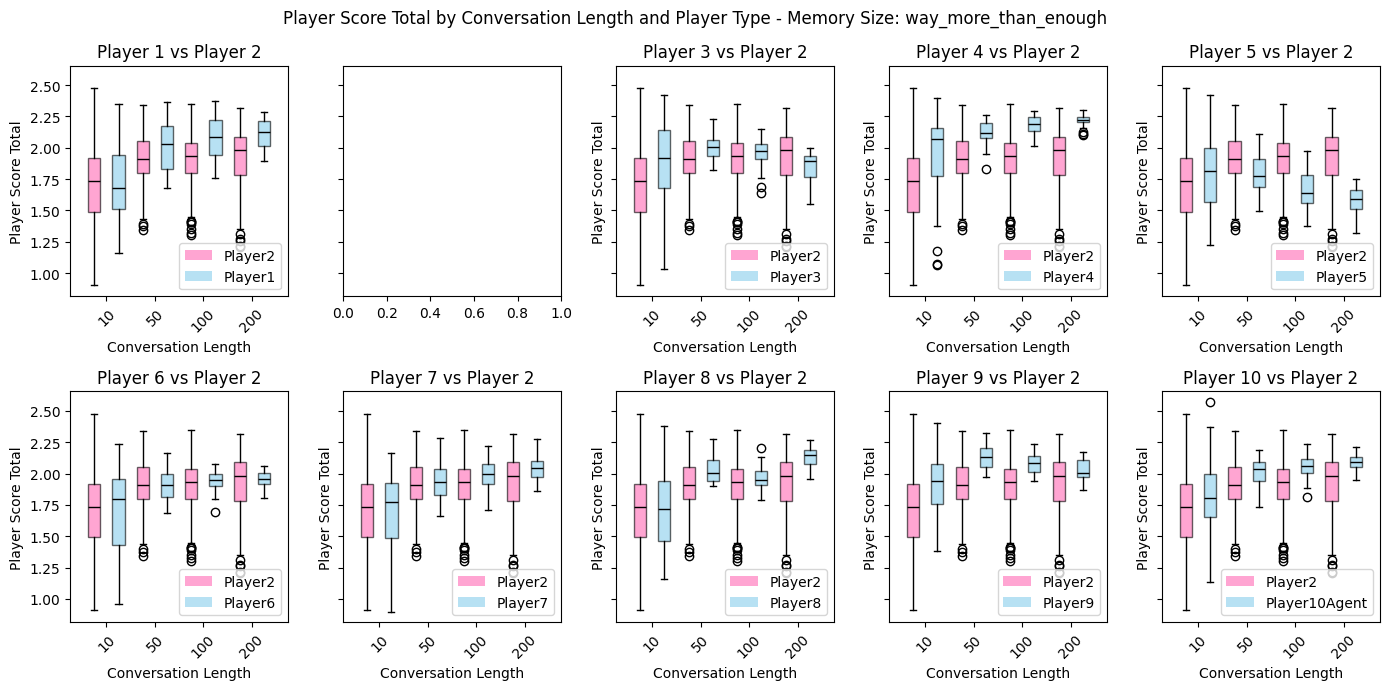

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

memory_vals = sorted(subset["memory_size_key"].unique())

# Get sorted conversation lengths
conv_lens = sorted(df["conversation_length"].unique())
n_conv = len(conv_lens)

for m in memory_vals:

    fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(14, 7), sharey=True)

    subset = df[(df.player_selection_type == '1v1') & (df.player_list.str.contains('p2')) & (df.memory_size_key == m)]

    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i+1 == 2:
            continue
        # Define the three groups you want to compare
        if i+1 != 10:
            groups = {
                "Player2": subset[(subset.player_name == 'Player2')],
                f"Player{i+1}": subset[(subset.player_name == f'Player{i+1}')]
            }
        else:
            groups = {
                "Player2": subset[(subset.player_name == 'Player2')],
                f"Player10Agent": subset[(subset.player_name == f'Player10Agent')]
            }

        # Width of each box
        box_width = 0.25
        # Offset to separate groups visually
        offsets = np.linspace(-box_width, box_width, len(groups))

        # Colors for each group
        colors = ["hotpink", "skyblue"]

        for j, (label, subset2) in enumerate(groups.items()):
            box_data = []
            for conv_len in conv_lens:
                vals = subset2.loc[
                    subset2["conversation_length"] == conv_len,
                    "player_score_total"
                ]
                box_data.append(vals.values)

            # Positions for this group
            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                boxprops=dict(facecolor=colors[j], alpha=0.6),
                medianprops=dict(color="black"),
            )

        # Formatting axes
        ax.set_title(f"Player {i+1} vs Player 2")
        ax.set_xticks(np.arange(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        ax.set_ylabel("Player Score Total")
        ax.legend([plt.Rectangle((0,0),1,1,facecolor=c,alpha=0.6) for c in colors],
                list(groups.keys()), loc="lower right")

    plt.suptitle(f"Player Score Total by Conversation Length and Player Type - Memory Size: {m}")
    plt.tight_layout()
    plt.show()

### Subject num (maybe irrelevant)

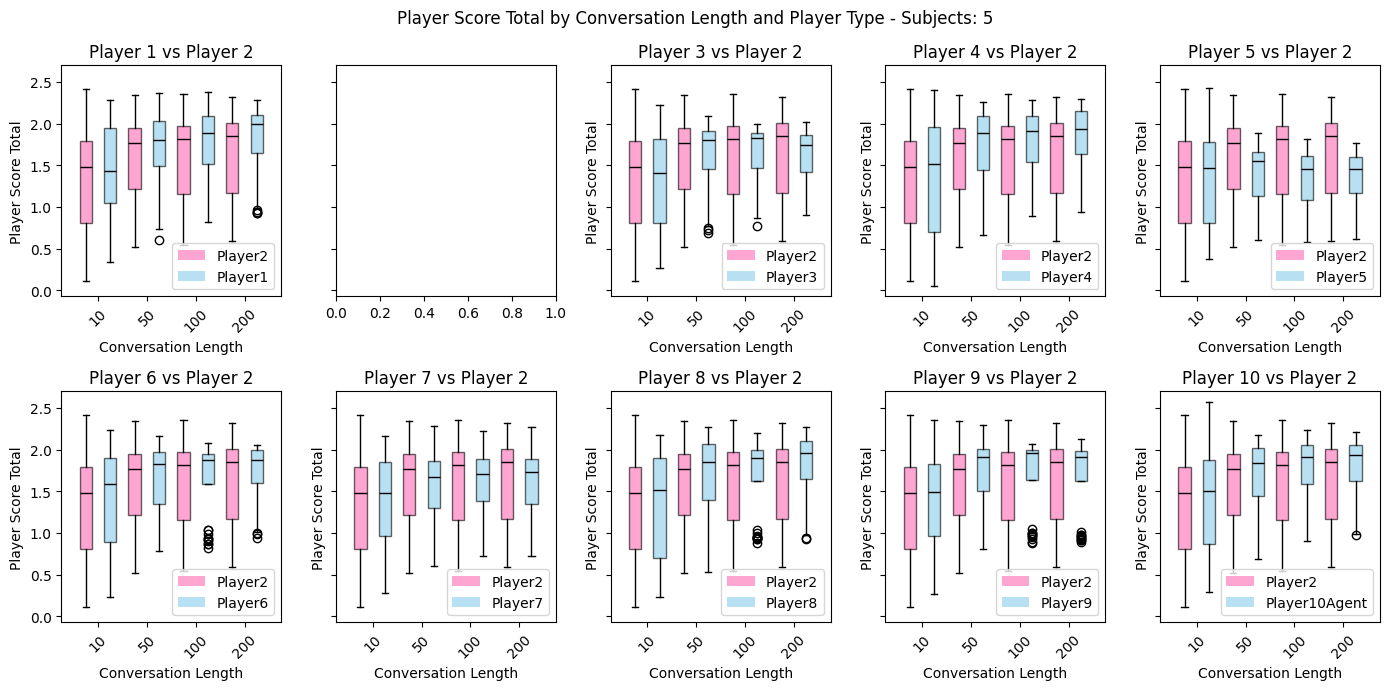

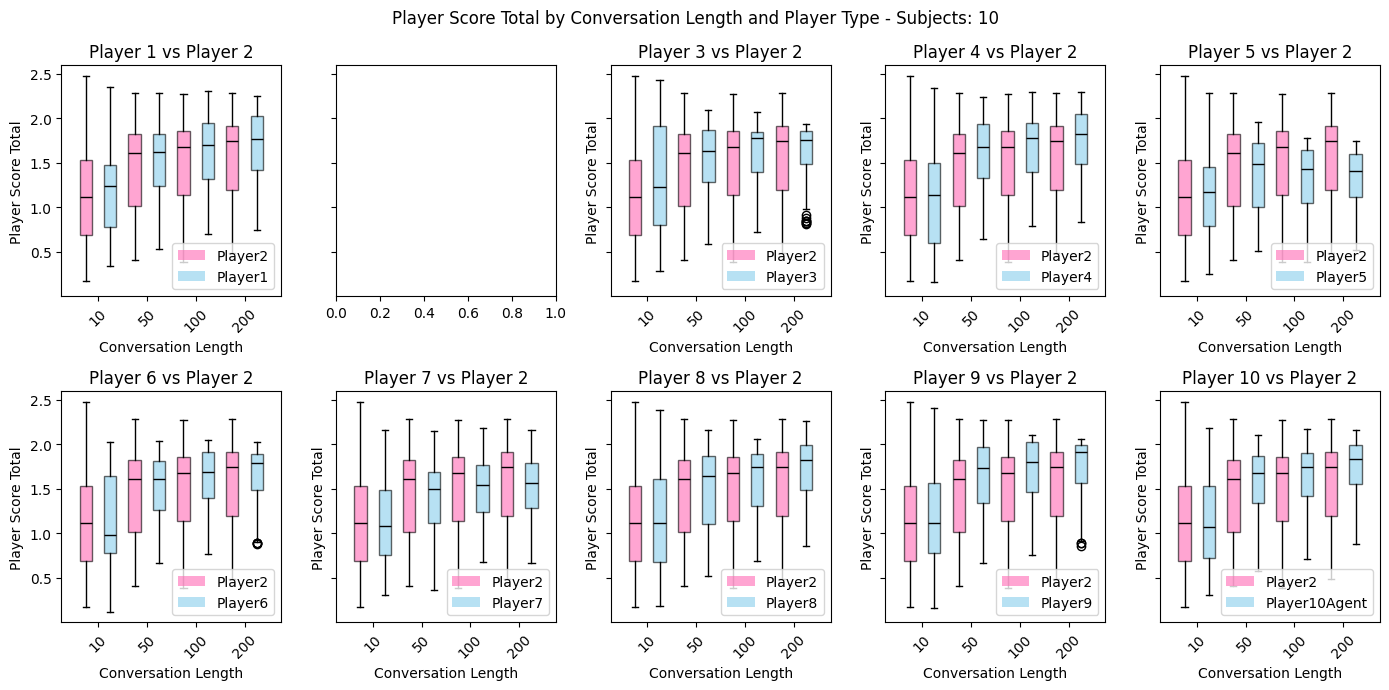

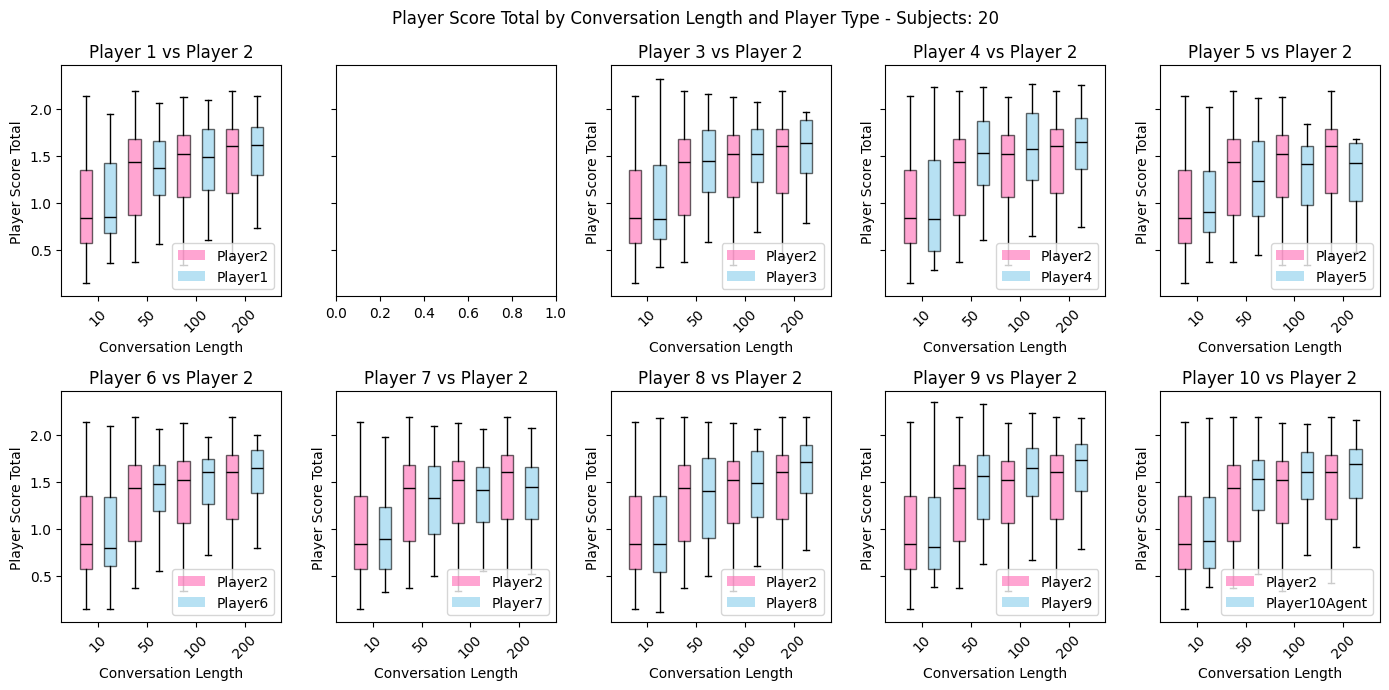

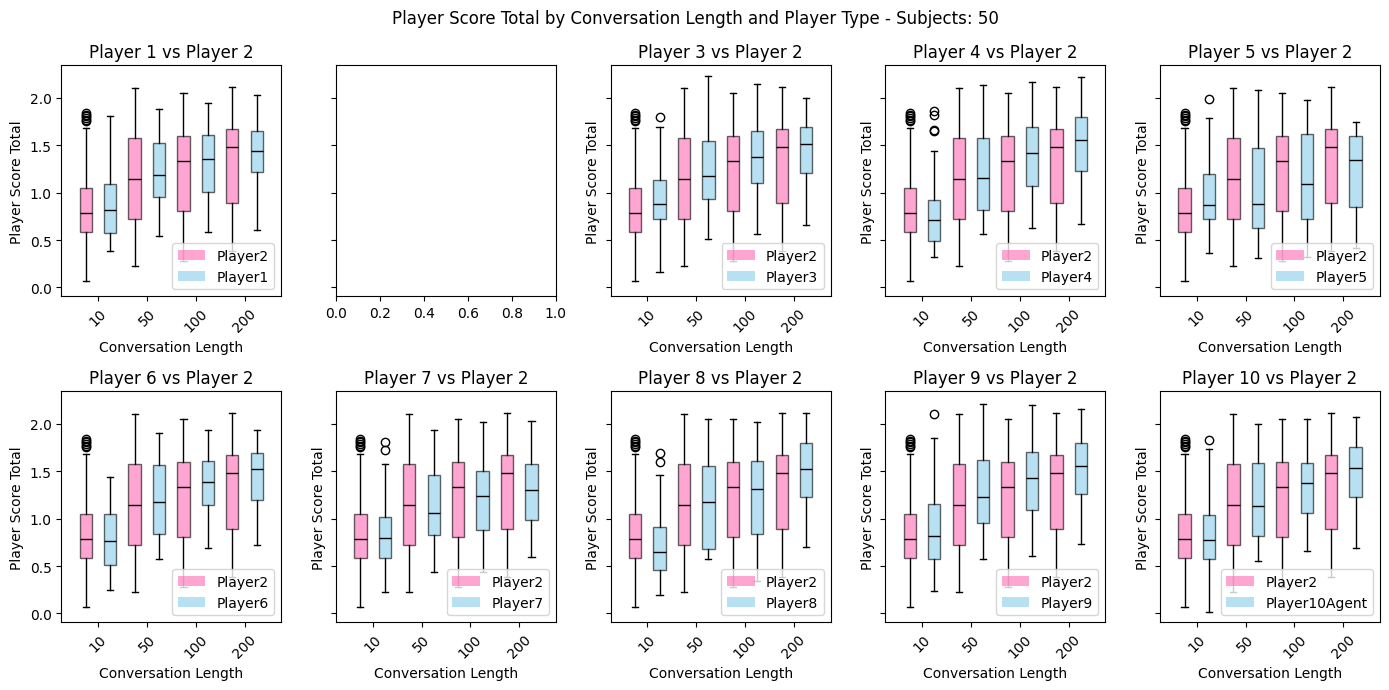

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sub_vals = sorted(subset["num_subjects"].unique())

# Get sorted conversation lengths
conv_lens = sorted(df["conversation_length"].unique())
n_conv = len(conv_lens)

for m in sub_vals:

    fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(14, 7), sharey=True)

    subset = df[(df.player_selection_type == '1v1') & (df.player_list.str.contains('p2')) & (df.num_subjects == m)]

    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i+1 == 2:
            continue
        # Define the three groups you want to compare
        if i+1 != 10:
            groups = {
                "Player2": subset[(subset.player_name == 'Player2')],
                f"Player{i+1}": subset[(subset.player_name == f'Player{i+1}')]
            }
        else:
            groups = {
                "Player2": subset[(subset.player_name == 'Player2')],
                f"Player10Agent": subset[(subset.player_name == f'Player10Agent')]
            }

        # Width of each box
        box_width = 0.25
        # Offset to separate groups visually
        offsets = np.linspace(-box_width, box_width, len(groups))

        # Colors for each group
        colors = ["hotpink", "skyblue"]

        for j, (label, subset2) in enumerate(groups.items()):
            box_data = []
            for conv_len in conv_lens:
                vals = subset2.loc[
                    subset2["conversation_length"] == conv_len,
                    "player_score_total"
                ]
                box_data.append(vals.values)

            # Positions for this group
            positions = np.arange(len(conv_lens)) + offsets[j]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                boxprops=dict(facecolor=colors[j], alpha=0.6),
                medianprops=dict(color="black"),
            )

        # Formatting axes
        ax.set_title(f"Player {i+1} vs Player 2")
        ax.set_xticks(np.arange(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_xlabel("Conversation Length")
        ax.set_ylabel("Player Score Total")
        ax.legend([plt.Rectangle((0,0),1,1,facecolor=c,alpha=0.6) for c in colors],
                list(groups.keys()), loc="lower right")

    plt.suptitle(f"Player Score Total by Conversation Length and Player Type - Subjects: {m}")
    plt.tight_layout()
    plt.show()

## 20 pairs

In [ ]:
df[(df.player_selection_type == '20_pairs')].groupby(['conversation_length', 'player_name'])[['player_score_total', 'shared_score_coherence']].describe()

player_score_total                      \
                                               count      mean       std   
conversation_length player_name                                            
10                  Player1                    320.0  1.192348  0.416526   
                    Player10Agent              320.0  1.203237  0.424168   
                    Player2                    320.0  1.211928  0.429859   
                    Player3                    320.0  1.209747  0.437462   
                    Player4                    320.0  1.200353  0.419896   
                    Player5                    320.0  1.209992  0.432715   
                    Player6                    320.0  1.200736  0.434623   
                    Player7                    320.0  1.208605  0.439766   
                    Player8                    320.0  1.198052  0.426361   
                    Player9                    320.0  1.219539  0.434088   
50                  Player1                    320.0  1.241378  0.529598   
                    Player10Agent              320.0  1.238644  0.522484   
                    Player2                    320.0  1.243341  0.523945   
                    Player3                    320.0  1.248601  0.529818   
                    Player4                    320.0  1.239748  0.522936   
                    Player5                    320.0  1.242649  0.524690   
                    Player6                    320.0  1.239517  0.527237   
                    Player7                    320.0  1.240222  0.524450   
                    Player8                    320.0  1.244199  0.527951   
                    Player9                    320.0  1.244739  0.526073   
100                 Player1                    320.0  1.382732  0.521133   
                    Player10Agent              320.0  1.386230  0.522100   
                    Player2                    320.0  1.382714  0.522021   
                    Player3                    320.0  1.396522  0.529003   
                    Player4                    320.0  1.383534  0.517125   
                    Player5                    320.0  1.381420  0.516334   
                    Player6                    320.0  1.385850  0.523617   
                    Player7                    320.0  1.384382  0.522408   
                    Player8                    320.0  1.385415  0.524142   
                    Player9                    320.0  1.391444  0.522356   
200                 Player1                    320.0  1.479528  0.430147   
                    Player10Agent              320.0  1.479629  0.431567   
                    Player2                    320.0  1.476935  0.431628   
                    Player3                    320.0  1.492876  0.442131   
                    Player4                    320.0  1.481326  0.431709   
                    Player5                    320.0  1.478668  0.430020   
                    Player6                    320.0  1.477832  0.431007   
                    Player7                    320.0  1.477006  0.430241   
                    Player8                    320.0  1.478903  0.429641   
                    Player9                    320.0  1.481942  0.430781   

                                                                           \
                                        min       25%       50%       75%   
conversation_length player_name                                             
10                  Player1        0.292000  0.854500  1.198000  1.512500   
                    Player10Agent  0.279000  0.867250  1.181500  1.525250   
                    Player2        0.288000  0.892000  1.187250  1.595250   
                    Player3        0.328000  0.868875  1.180500  1.529750   
                    Player4        0.290000  0.855500  1.189500  1.553000   
                    Player5        0.297000  0.862250  1.177500  1.555250   
                    Player6        0.356500  0.852000  1.172000  1.56025

/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/1728022826.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_names))


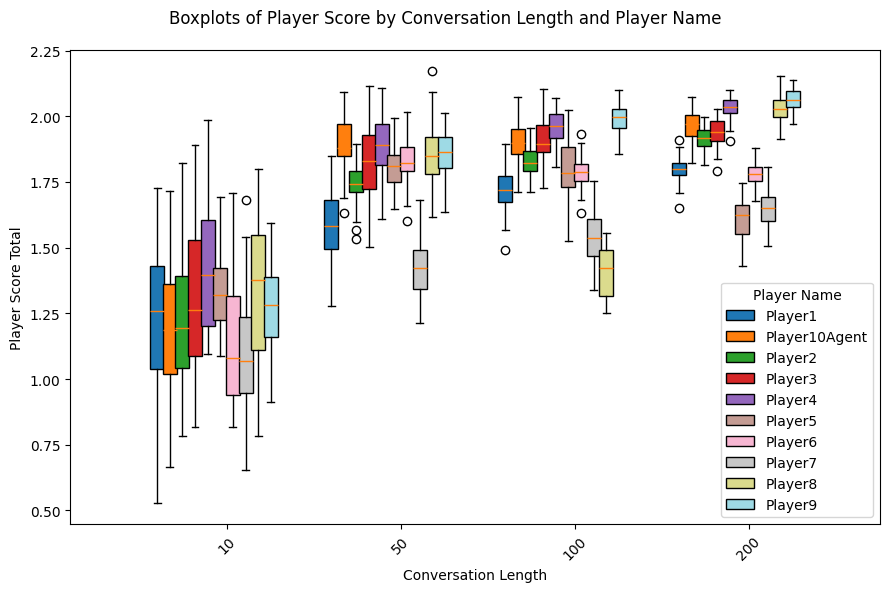

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Keep only the 10 players
subset = df[df["player_selection_type"].str.startswith("20_pairs")]
player_names = sorted(subset["player_name"].unique())

# Assign a unique color to each player_selection_type
colors = cm.get_cmap("tab20", len(player_names))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_names)}

# Subplot grid: 3 rows × 2 cols
fig, ax = plt.subplots(figsize=(9, 6), sharey=True)

conv_lens = sorted(data["conversation_length"].unique())
n_conv = len(conv_lens)
n_players = len(player_types)

# width of each box group and offsets
box_width = 0.08
offsets = np.linspace(-0.4, 0.4, n_players)

for j, ptype in enumerate(player_names):
    box_data = []
    for conv_len in conv_lens:
        vals = data.loc[
            (data["conversation_length"] == conv_len) &
            (data["player_name"] == ptype),
            "player_score_total"
        ]
        box_data.append(vals.values)

    # Positions shifted by player index
    positions = np.arange(len(conv_lens)) + offsets[j]

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        label=ptype
    )

    # Color boxes
    for patch in bp["boxes"]:
        patch.set_facecolor(color_map[ptype])

ax.set_xticks(range(len(conv_lens)))
ax.set_xticklabels(conv_lens, rotation=45)
ax.set_xlabel("Conversation Length")
ax.set_ylabel("Player Score Total")
ax.legend(
    title="Player Name",
    loc="lower right"
)

plt.suptitle("Boxplots of Player Score by Conversation Length and Player Name")
plt.tight_layout()
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/591628032.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_names))


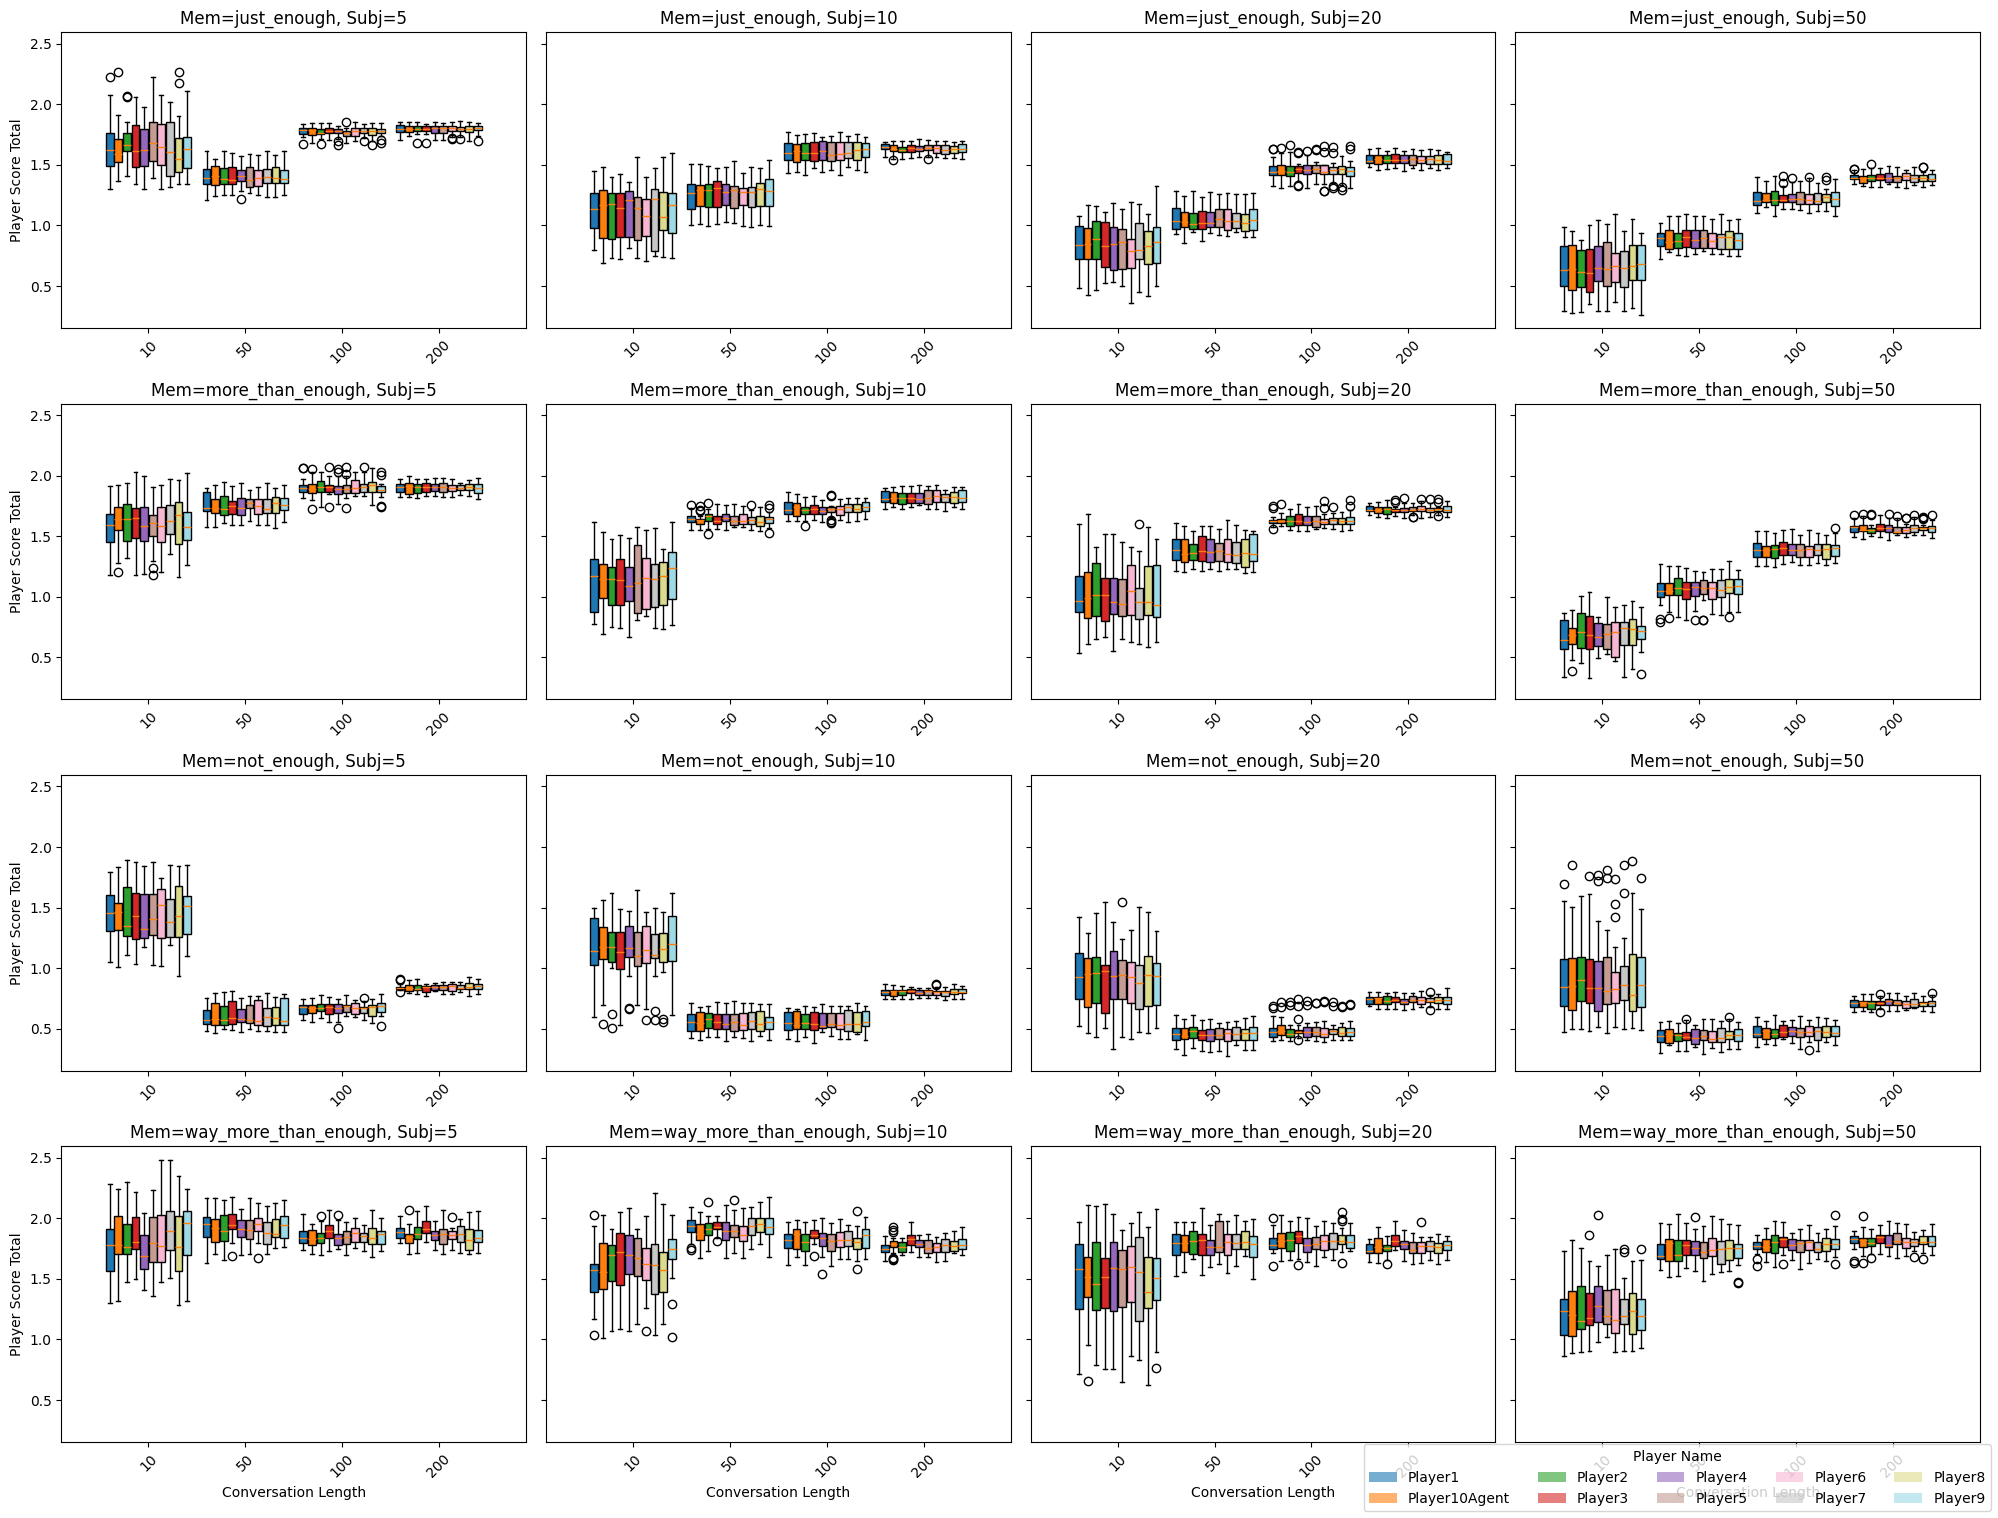

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Filter down to relevant subset first
subset = df[df["player_selection_type"].str.startswith("20_pairs")]

# Unique identifiers
memory_sizes = sorted(subset["memory_size_key"].unique())
subjects = sorted(subset["num_subjects"].unique())
player_names = sorted(subset["player_name"].unique())

# Assign colors per player
colors = cm.get_cmap("tab20", len(player_names))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_names)}

# Subplots grid: rows=memory_size, cols=subject_num
fig, axes = plt.subplots(
    nrows=len(memory_sizes),
    ncols=len(subjects),
    figsize=(5 * len(subjects), 4 * len(memory_sizes)),
    sharey=True,
    squeeze=False  # ensures axes is 2D
)

box_width = 0.08
offsets = np.linspace(-0.4, 0.4, len(player_names))

for i, mem_size in enumerate(memory_sizes):
    for j, subj in enumerate(subjects):
        ax = axes[i, j]

        # Filter subset for this subplot
        data_sub = subset[
            (subset["memory_size_key"] == mem_size) &
            (subset["num_subjects"] == subj)
        ]

        conv_lens = sorted(data_sub["conversation_length"].unique())

        for k, ptype in enumerate(player_names):
            box_data = []
            for conv_len in conv_lens:
                vals = data_sub.loc[
                    (data_sub["conversation_length"] == conv_len) &
                    (data_sub["player_name"] == ptype),
                    "player_score_total"
                ]
                box_data.append(vals.values)

            positions = np.arange(len(conv_lens)) + offsets[k]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                label=ptype if (i == 0 and j == 0) else ""  # only label once
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_title(f"Mem={mem_size}, Subj={subj}")

        if j == 0:
            ax.set_ylabel("Player Score Total")
        if i == len(memory_sizes) - 1:
            ax.set_xlabel("Conversation Length")

# Shared legend outside grid
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color_map[p], alpha=0.6) for p in player_names]
fig.legend(handles, player_names, title="Player Name", loc="lower right", ncol=len(player_names)//2)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


/var/folders/6f/jf84pgs92_g7qw0w6040htqc0000gn/T/ipykernel_82240/3131151690.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(player_names))


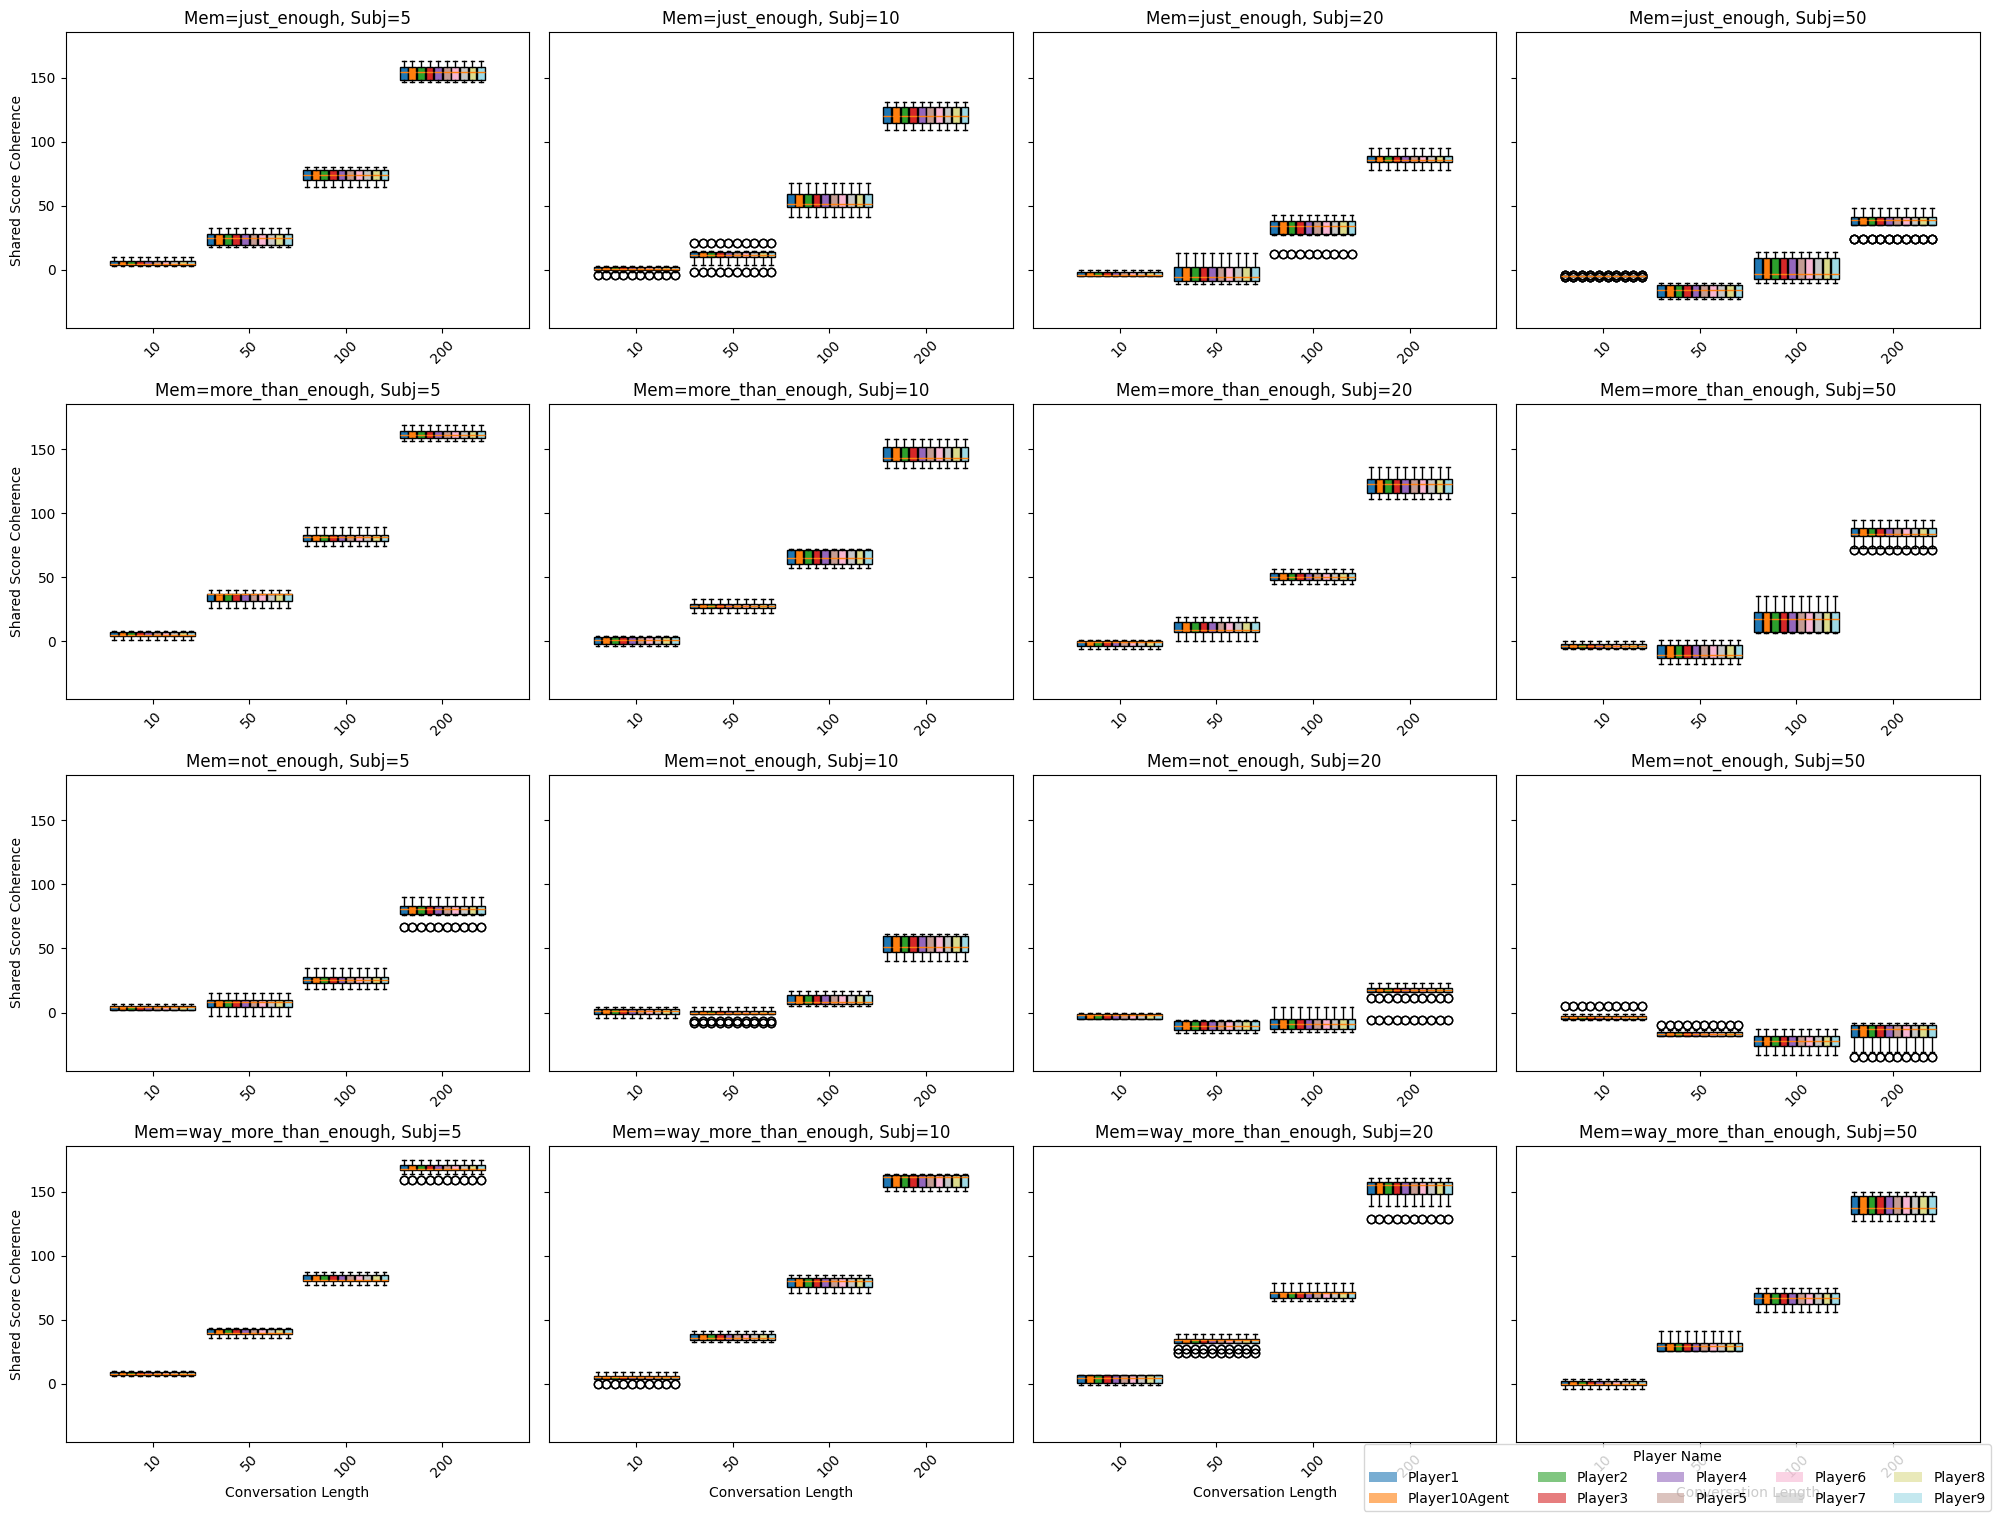

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Filter down to relevant subset first
subset = df[df["player_selection_type"].str.startswith("20_pairs")]

# Unique identifiers
memory_sizes = sorted(subset["memory_size_key"].unique())
subjects = sorted(subset["num_subjects"].unique())
player_names = sorted(subset["player_name"].unique())

# Assign colors per player
colors = cm.get_cmap("tab20", len(player_names))
color_map = {ptype: colors(i) for i, ptype in enumerate(player_names)}

# Subplots grid: rows=memory_size, cols=subject_num
fig, axes = plt.subplots(
    nrows=len(memory_sizes),
    ncols=len(subjects),
    figsize=(5 * len(subjects), 4 * len(memory_sizes)),
    sharey=True,
    squeeze=False  # ensures axes is 2D
)

box_width = 0.08
offsets = np.linspace(-0.4, 0.4, len(player_names))

for i, mem_size in enumerate(memory_sizes):
    for j, subj in enumerate(subjects):
        ax = axes[i, j]

        # Filter subset for this subplot
        data_sub = subset[
            (subset["memory_size_key"] == mem_size) &
            (subset["num_subjects"] == subj)
        ]

        conv_lens = sorted(data_sub["conversation_length"].unique())

        for k, ptype in enumerate(player_names):
            box_data = []
            for conv_len in conv_lens:
                vals = data_sub.loc[
                    (data_sub["conversation_length"] == conv_len) &
                    (data_sub["player_name"] == ptype),
                    "shared_score_coherence"
                ]
                box_data.append(vals.values)

            positions = np.arange(len(conv_lens)) + offsets[k]

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                label=ptype if (i == 0 and j == 0) else ""  # only label once
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color_map[ptype])

        ax.set_xticks(range(len(conv_lens)))
        ax.set_xticklabels(conv_lens, rotation=45)
        ax.set_title(f"Mem={mem_size}, Subj={subj}")

        if j == 0:
            ax.set_ylabel("Shared Score Coherence")
        if i == len(memory_sizes) - 1:
            ax.set_xlabel("Conversation Length")

# Shared legend outside grid
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color_map[p], alpha=0.6) for p in player_names]
fig.legend(handles, player_names, title="Player Name", loc="lower right", ncol=len(player_names)//2)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


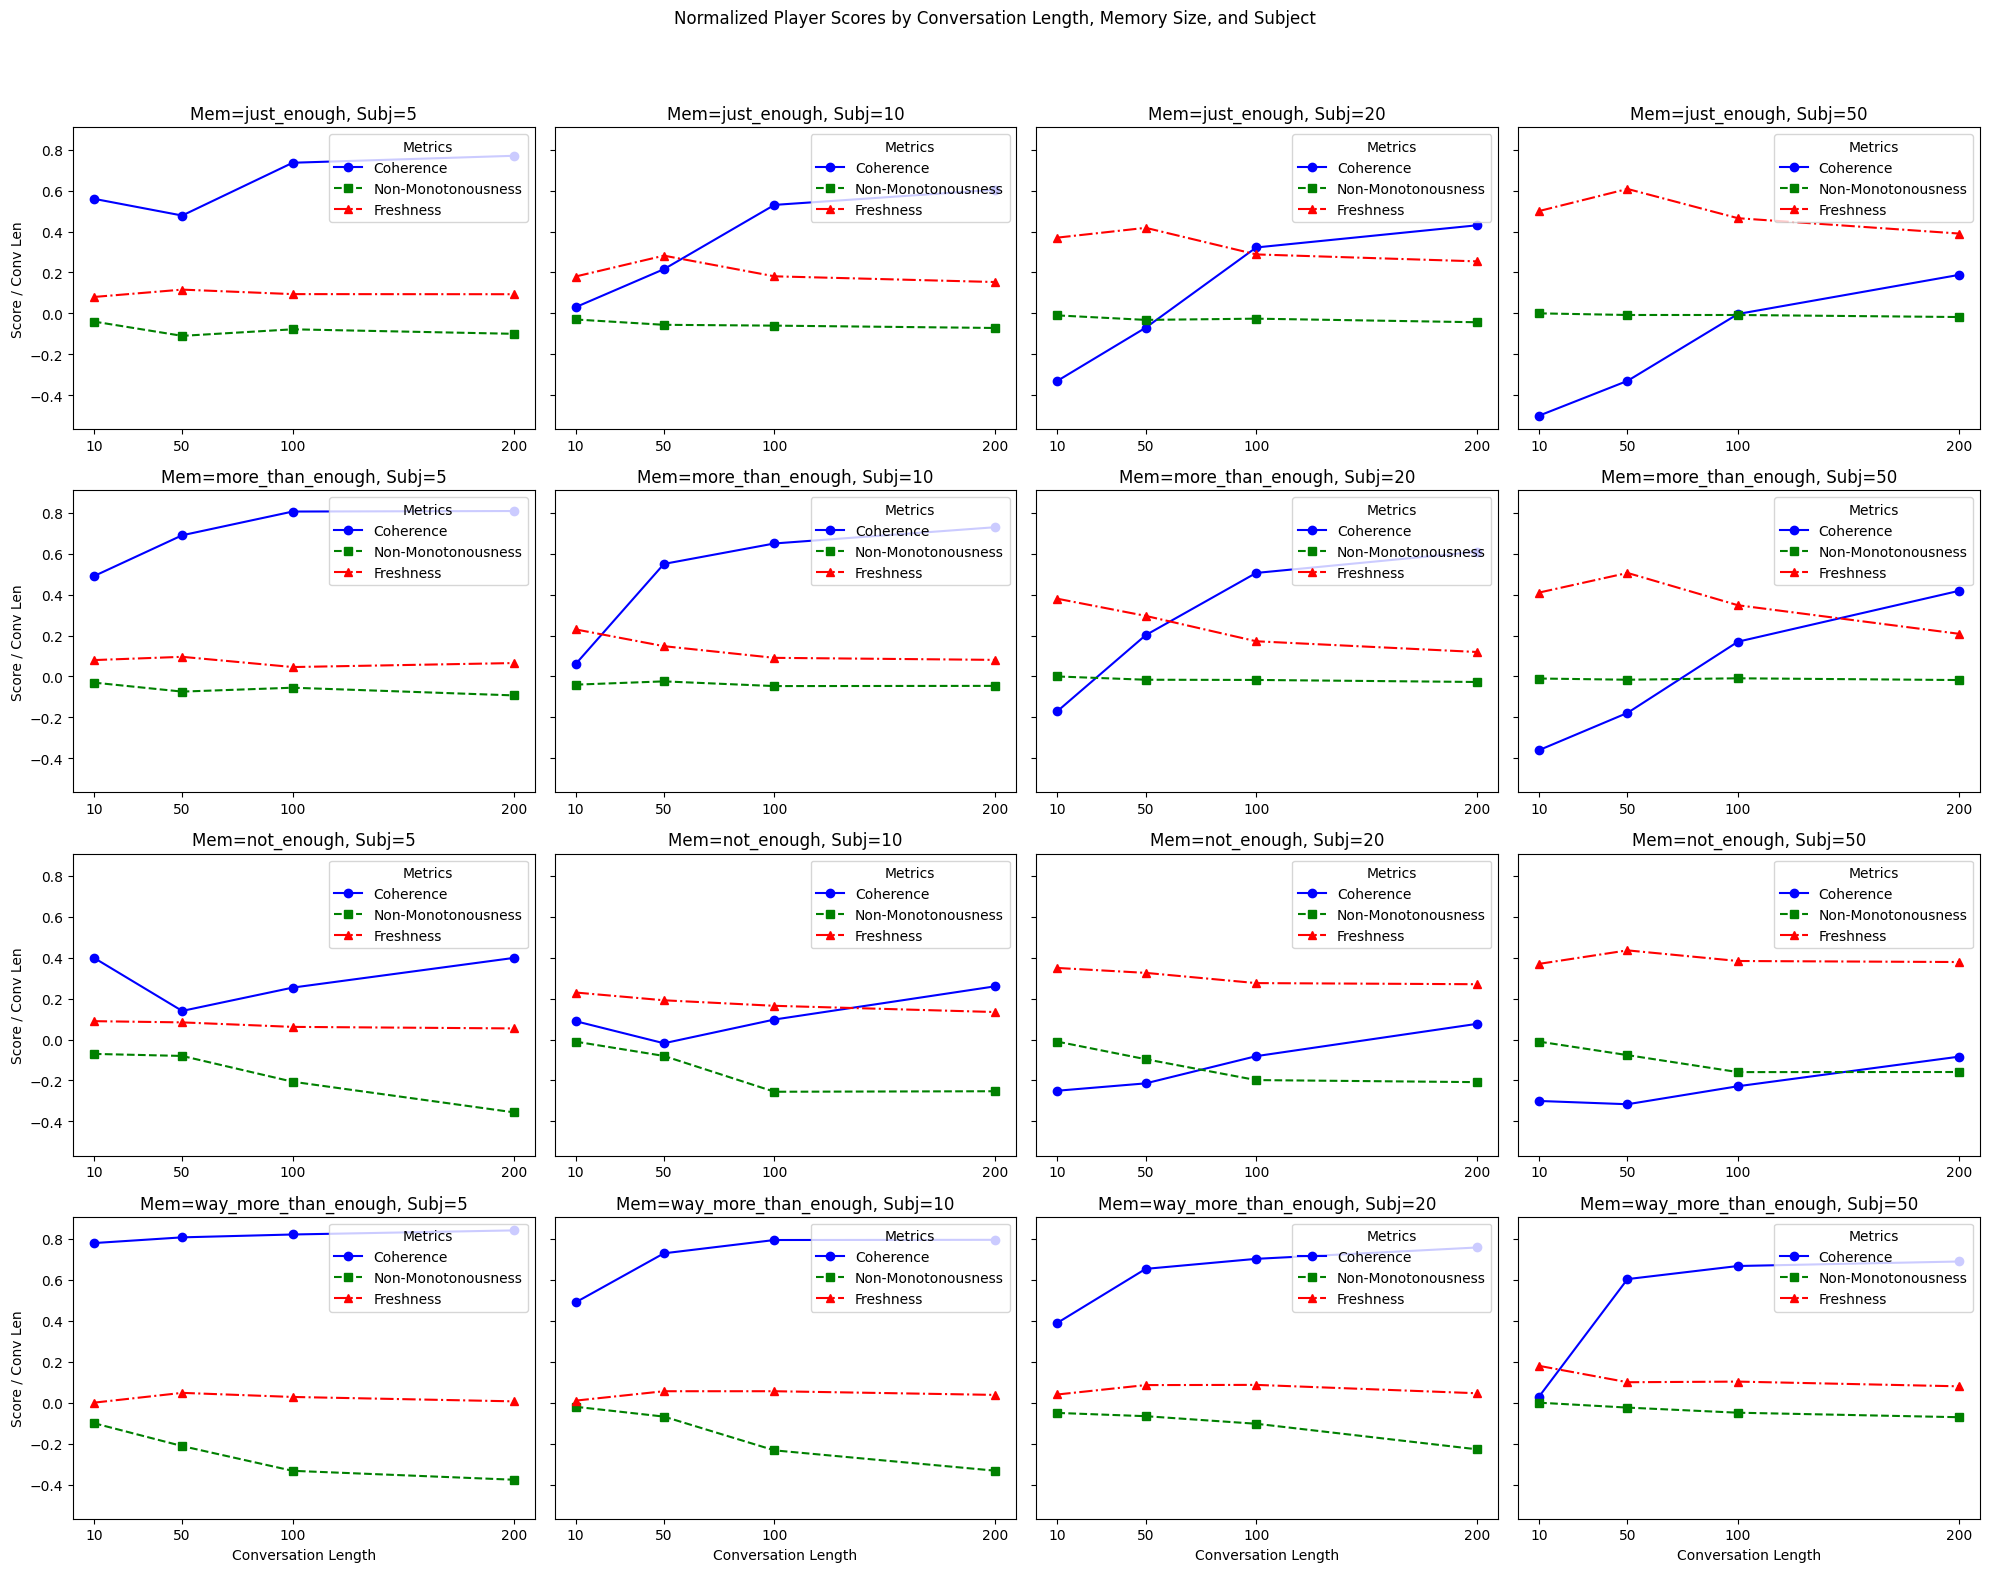

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to relevant subset
subset = df[df["player_selection_type"].str.startswith("20_pairs")]

# Unique identifiers
memory_sizes = sorted(subset["memory_size_key"].unique())
subjects = sorted(subset["num_subjects"].unique())

fig, axes = plt.subplots(
    nrows=len(memory_sizes),
    ncols=len(subjects),
    figsize=(5 * len(subjects), 4 * len(memory_sizes)),
    sharey=True,
    squeeze=False
)

for i, mem_size in enumerate(memory_sizes):
    for j, subj in enumerate(subjects):
        ax = axes[i, j]

        # Filter subset for this subplot
        data_sub = subset[
            (subset["memory_size_key"] == mem_size) &
            (subset["num_subjects"] == subj)
        ]

        conv_lens = sorted(data_sub["conversation_length"].unique())

        # Lists to store mean values per conversation length
        mean_coherence = []
        mean_nonmo = []
        mean_freshness = []

        for conv_len in conv_lens:
            vals_coh = data_sub.loc[
                data_sub["conversation_length"] == conv_len,
                "shared_score_coherence"
            ] / conv_len
            vals_nonmo= data_sub.loc[
                data_sub["conversation_length"] == conv_len,
                "shared_score_nonmonotonousness"
            ] / conv_len
            vals_fresh = data_sub.loc[
                data_sub["conversation_length"] == conv_len,
                "shared_score_freshness"
            ] / conv_len

            mean_coherence.append(vals_coh.mean())
            mean_nonmo.append(vals_nonmo.mean())
            mean_freshness.append(vals_fresh.mean())

        # Plot the three lines
        ax.plot(conv_lens, mean_coherence, marker='o', linestyle='-', color='blue', label='Coherence')
        ax.plot(conv_lens, mean_nonmo, marker='s', linestyle='--', color='green', label='Non-Monotonousness')
        ax.plot(conv_lens, mean_freshness, marker='^', linestyle='-.', color='red', label='Freshness')

        ax.set_title(f"Mem={mem_size}, Subj={subj}")
        ax.set_xticks(conv_lens)
        if j == 0:
            ax.set_ylabel("Score / Conv Len")
        if i == len(memory_sizes) - 1:
            ax.set_xlabel("Conversation Length")


        ax.legend(loc='upper right', title="Metrics")

plt.suptitle("Normalized Player Scores by Conversation Length, Memory Size, and Subject")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



### want to show: number of players makes conversations harder

In [ ]:
df.groupby(['num_players', 'conversation_length'])[['player_score_total', 'shared_score_coherence']].describe()

player_score_total                      \
                                             count      mean       std   
num_players conversation_length                                          
2           10                             18240.0  1.038353  0.591067   
            50                             18240.0  1.355437  0.574410   
            100                            18240.0  1.406431  0.579824   
            200                            18240.0  1.484399  0.542307   
5           10                              9600.0  0.946640  0.541015   
            50                              9600.0  1.181502  0.642838   
            100                             9600.0  1.224712  0.638390   
            200                             9600.0  1.301382  0.673129   
9           10                             14400.0  0.977359  0.453898   
            50                             14400.0  1.294766  0.559604   
            100                            14400.0  1.426847  0.488610   
            200                            14400.0  1.465944  0.432475   
10          10                             20800.0  0.908728  0.515201   
            50                             20800.0  1.165788  0.626001   
            100                            20800.0  1.273687  0.618453   
            200                            20800.0  1.307808  0.636615   
11          10                              1760.0  0.725283  0.616694   
            50                              1760.0  1.054836  0.599618   
            100                             1760.0  1.236511  0.569917   
            200                             1760.0  1.327419  0.503813   
12          10                              1920.0  0.694280  0.565782   
            50                              1920.0  0.968924  0.658424   
            100                             1920.0  1.106630  0.603715   
            200                             1920.0  1.214049  0.564291   
20          10                             41600.0  1.048341  0.524886   
            50                             41600.0  1.092045  0.588007   
            100                            41600.0  1.214384  0.632470   
            200                            41600.0  1.304924  0.617050   
34          10                             70720.0  1.081114  0.527624   
            50                             70720.0  1.119496  0.537181   
            100                            70720.0  1.070924  0.642167   
            200                            70720.0  1.170607  0.667053   

                                                                        \
                                     min       25%       50%       75%   
num_players conversation_length                                          
2           10                  -0.44000  0.558000  0.955000  1.471125   
            50                  -0.34520  0.814000  1.419700  1.849600   
            100                 -0.27470  0.915600  1.523300  1.877800   
            200                 -0.25675  0.995738  1.619438  1.906525   
5           10                  -0.32800  0.572875  0.849500  1.299000   
            50                  -0.30500  0.716400  1.246750  1.734100   
            100                 -0.31860  0.777500  1.299975  1.774225   
            200                 -0.29695  0.827400  1.446100  1.865712   
9           10                   0.06900  0.635000  0.836000  1.232000   
            50                   0.15980  0.734250  1.429600  1.782000   
            100                  0.39440  0.941050  1.606600  1.821500   
            200                  0.49420  1.095512  1.645400  1.806212   
10          10                  -0.53900  0.579375  0.845000  1.225000   
            50                  -0.37700  0.600200  1.257550  1.708800   
            100                 -0.28650  0.804400  1.400325  1.787000   
            200                 -0.28305  0.835000  1.450050  1.832894   
11          10                  -0.

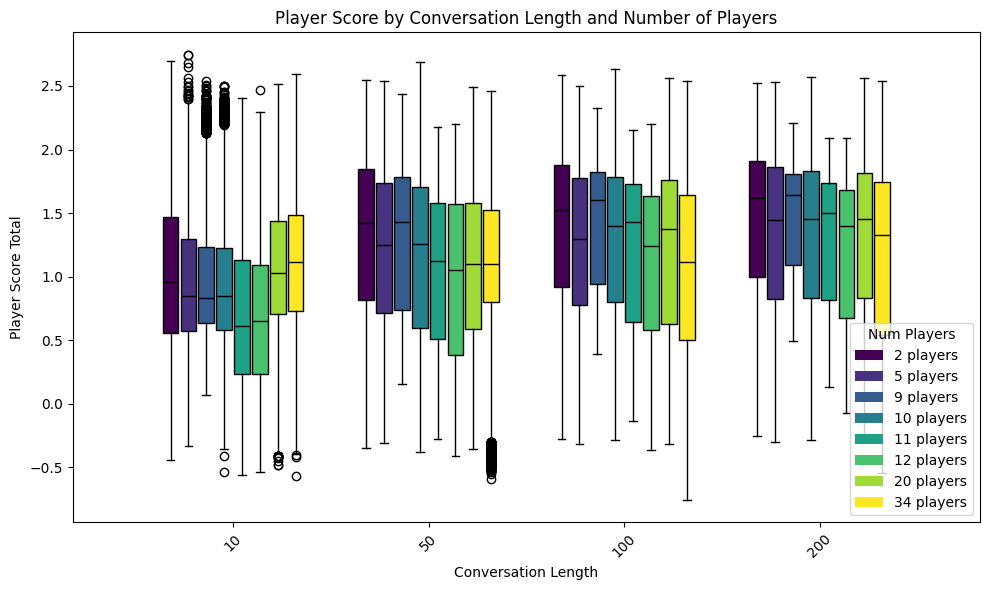

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Unique conversation lengths and number of players
conv_lens = sorted(df["conversation_length"].unique())
num_players_vals = sorted(df["num_players"].unique())

n_conv = len(conv_lens)
n_players = len(num_players_vals)

# Width of each box and offsets for grouping
box_width = 0.08  # smaller width for skinnier boxes
offsets = np.linspace(-box_width*n_players/2, box_width*n_players/2, n_players)

# Colors for each num_players group
colors = plt.cm.viridis(np.linspace(0, 1, n_players))

fig, ax = plt.subplots(figsize=(10, 6))

for j, num in enumerate(num_players_vals):
    box_data = []
    for conv_len in conv_lens:
        vals = df.loc[
            (df["conversation_length"] == conv_len) &
            (df["num_players"] == num),
            "player_score_total"
        ] 
        box_data.append(vals.values)

    positions = np.arange(len(conv_lens)) + offsets[j]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=dict(color="black")
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(colors[j])

# Format x-axis
ax.set_xticks(np.arange(len(conv_lens)))
ax.set_xticklabels(conv_lens, rotation=45)
ax.set_xlabel("Conversation Length")
ax.set_ylabel("Player Score Total")
ax.set_title("Player Score by Conversation Length and Number of Players")

# Legend
handles = [plt.Rectangle((0,0),1,1, facecolor=colors[i]) for i in range(n_players)]
labels = [f"{num} players" for num in num_players_vals]
ax.legend(handles, labels, title="Num Players")

plt.tight_layout()
plt.show()




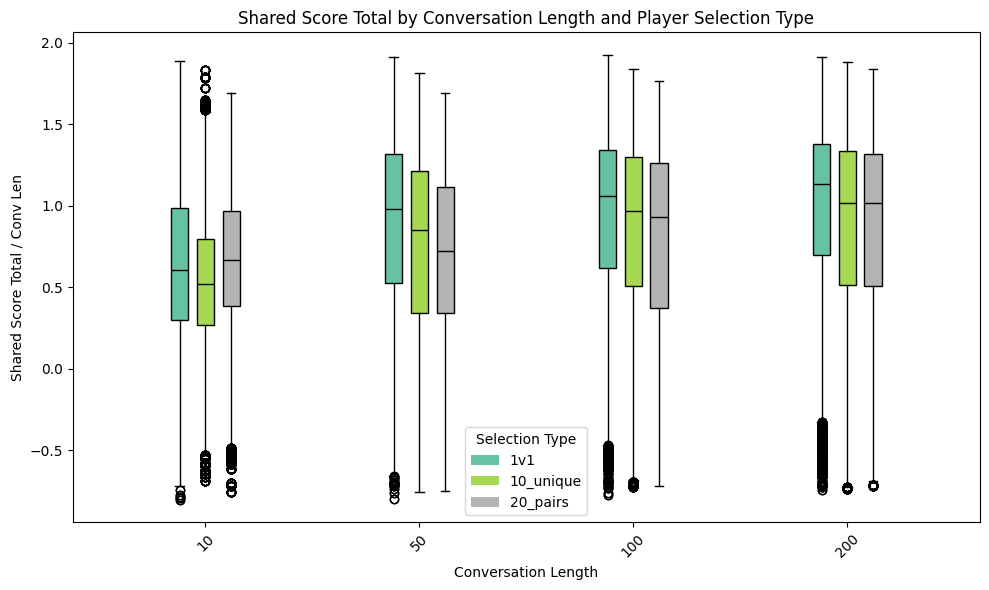

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Unique conversation lengths
conv_lens = sorted(df["conversation_length"].unique())

# Subset data by selection type
df_1v1 = df[(df["player_selection_type"] == "1v1") | (df["player_selection_type"].str.startswith("single") & (df["num_players"] == 2))]
df_10_uni = df[(df["player_selection_type"] == "10_unique") | (df["player_selection_type"].str.startswith("single") & (df["num_players"] == 10))]
df_20_pairs = df[(df["player_selection_type"] == "20_pairs") | (df["player_selection_type"].str.startswith("single") & (df["num_players"] == 20))]

selection_types = {
    "1v1": df_1v1,
    "10_unique": df_10_uni,
    "20_pairs": df_20_pairs
}

n_types = len(selection_types)
box_width = 0.08
offsets = np.linspace(-box_width * n_types / 2, box_width * n_types / 2, n_types)

# Colors for each type
colors = plt.cm.Set2(np.linspace(0, 1, n_types))

fig, ax = plt.subplots(figsize=(10, 6))

for j, (label, subdf) in enumerate(selection_types.items()):
    box_data = []
    for conv_len in conv_lens:
        vals = subdf.loc[
            subdf["conversation_length"] == conv_len,
            "shared_score_total"
        ]  / conv_len  # normalize by conversation length
        box_data.append(vals.values)

    positions = np.arange(len(conv_lens)) + offsets[j]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=dict(color="black")
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(colors[j])

# Format x-axis
ax.set_xticks(np.arange(len(conv_lens)))
ax.set_xticklabels(conv_lens, rotation=45)
ax.set_xlabel("Conversation Length")
ax.set_ylabel("Shared Score Total / Conv Len")
ax.set_title("Shared Score Total by Conversation Length and Player Selection Type")

# Legend
handles = [plt.Rectangle((0,0),1,1, facecolor=colors[i]) for i in range(n_types)]
labels = list(selection_types.keys())
ax.legend(handles, labels, title="Selection Type")

plt.tight_layout()
plt.show()



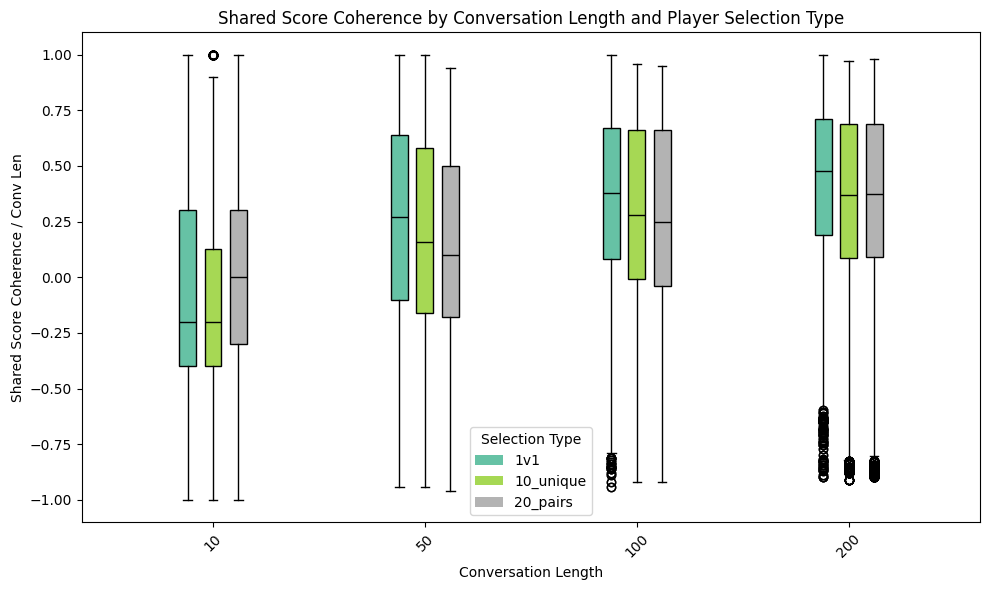

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Unique conversation lengths
conv_lens = sorted(df["conversation_length"].unique())

# Subset data by selection type
df_1v1 = df[(df["player_selection_type"] == "1v1") | (df["player_selection_type"].str.startswith("single") & (df["num_players"] == 2))]
df_10_uni = df[(df["player_selection_type"] == "10_unique") | (df["player_selection_type"].str.startswith("single") & (df["num_players"] == 10))]
df_20_pairs = df[(df["player_selection_type"] == "20_pairs") | (df["player_selection_type"].str.startswith("single") & (df["num_players"] == 20))]

selection_types = {
    "1v1": df_1v1,
    "10_unique": df_10_uni,
    "20_pairs": df_20_pairs
}

n_types = len(selection_types)
box_width = 0.08
offsets = np.linspace(-box_width * n_types / 2, box_width * n_types / 2, n_types)

# Colors for each type
colors = plt.cm.Set2(np.linspace(0, 1, n_types))

fig, ax = plt.subplots(figsize=(10, 6))

for j, (label, subdf) in enumerate(selection_types.items()):
    box_data = []
    for conv_len in conv_lens:
        vals = subdf.loc[
            subdf["conversation_length"] == conv_len,
            "shared_score_coherence"
        ]  / conv_len  # normalize by conversation length
        box_data.append(vals.values)

    positions = np.arange(len(conv_lens)) + offsets[j]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=dict(color="black")
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(colors[j])

# Format x-axis
ax.set_xticks(np.arange(len(conv_lens)))
ax.set_xticklabels(conv_lens, rotation=45)
ax.set_xlabel("Conversation Length")
ax.set_ylabel("Shared Score Coherence / Conv Len")
ax.set_title("Shared Score Coherence by Conversation Length and Player Selection Type")

# Legend
handles = [plt.Rectangle((0,0),1,1, facecolor=colors[i]) for i in range(n_types)]
labels = list(selection_types.keys())
ax.legend(handles, labels, title="Selection Type")

plt.tight_layout()
plt.show()